In [2]:
import os
import re
import json
from datetime import datetime, timezone
from pathlib import Path

import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from dotenv import load_dotenv


In [3]:
df = pd.read_csv("train_chatbot-arena.csv")
df.head()


,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1,0,0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0,1,0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0,0,1
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1,0,0
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0,1,0


In [4]:
df.shape

(57477, 9)

In [5]:
df.columns

Index(['id', 'model_a', 'model_b', 'prompt', 'response_a', 'response_b',
       'winner_model_a', 'winner_model_b', 'winner_tie'],
      dtype='str')

In [6]:
df.isnull().sum()

id                0
model_a           0
model_b           0
prompt            0
response_a        0
response_b        0
winner_model_a    0
winner_model_b    0
winner_tie        0
dtype: int64

In [7]:
def get_winner(row):
    if row["winner_model_a"] == 1:
        return 0
    elif row["winner_model_b"] == 1:
        return 1
    else:
        return 2

df["target"] = df.apply(get_winner, axis=1)
df["target"].value_counts()


target
0    20064
1    19652
2    17761
Name: count, dtype: int64

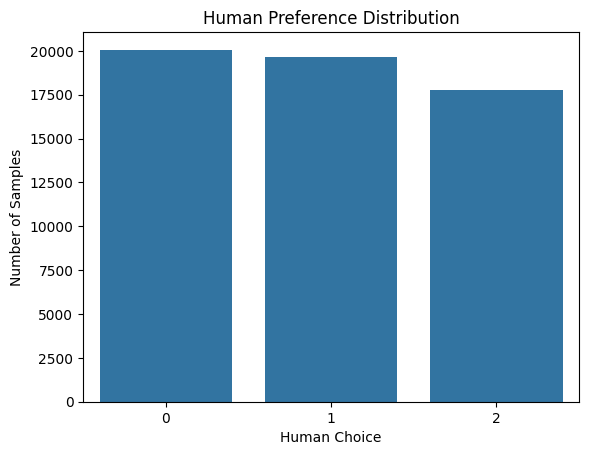

In [8]:
label_names = {0: "A", 1: "B", 2: "Tie"}

sns.countplot(data=df, x="target")
plt.title("Human Preference Distribution")
plt.xlabel("Human Choice")
plt.ylabel("Number of Samples")
plt.show()


In [9]:
df["combined_text"] = (
    "PROMPT: " + df["prompt"].astype(str)
    + " RESPONSE_A: " + df["response_a"].astype(str)
    + " RESPONSE_B: " + df["response_b"].astype(str)
)

df["response_a_length"] = df["response_a"].str.len()
df["response_b_length"] = df["response_b"].str.len()
df["length_difference"] = df["response_a_length"] - df["response_b_length"]


In [10]:
x = df["combined_text"]
y = df["target"]

In [11]:

x_trainval, x_test, y_trainval, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

x_train, x_val, y_train, y_val = train_test_split(x_trainval, y_trainval, test_size=0.25, random_state=42, stratify=y_trainval)

print(f"Train: {len(x_train)} | Validation: {len(x_val)} | Test: {len(x_test)}")

vectorizer_arena = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)
x_train_tfidf = vectorizer_arena.fit_transform(x_train)
x_val_tfidf = vectorizer_arena.transform(x_val)
x_test_tfidf = vectorizer_arena.transform(x_test)

model_arena = SGDClassifier(loss="log_loss", random_state=42)
model_arena.fit(x_train_tfidf, y_train)

val_accuracy = accuracy_score(y_val, model_arena.predict(x_val_tfidf))
print(f"Validation Accuracy: {val_accuracy:.2%}")


Train: 34485 | Validation: 11496 | Test: 11496
Validation Accuracy: 37.71%


In [12]:
y_pred = model_arena.predict(x_test_tfidf)
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")
print(classification_report(y_test, y_pred, target_names=["Human chose A", "Human chose B", "Tie"]))


Accuracy: 38.39%
               precision    recall  f1-score   support

Human chose A       0.37      0.40      0.39      4013
Human chose B       0.36      0.38      0.37      3931
          Tie       0.42      0.36      0.39      3552

     accuracy                           0.38     11496
    macro avg       0.39      0.38      0.38     11496
 weighted avg       0.39      0.38      0.38     11496



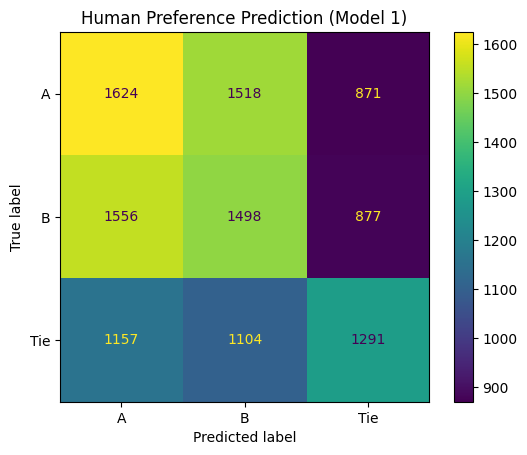

In [13]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["A", "B", "Tie"])
disp.plot()
plt.title("Human Preference Prediction (Model 1)")
plt.show()


In [14]:
social_df = pd.read_csv("social_skills_dataset (2).csv")
social_df.head()


,category,situation,prompt,response_a,response_b,human_choice
0,Public Speaking,Q&A nerves,I'm worried about freezing up during questions...,"Take a breath, repeat the question in your own...",Answer as quickly as possible to avoid an awkw...,0
1,Public Speaking,Q&A nerves,I'm worried about freezing up during questions...,Answer as quickly as possible to avoid an awkw...,"Take a breath, repeat the question in your own...",1
2,Handling Criticism,Group critique,My team lead criticizes my idea in front of th...,Defend the idea strongly right there to save f...,Respond calmly in the moment and reflect on it...,1
3,Public Speaking,Nervous before presenting,I have to present tomorrow with my study partn...,Write out the entire speech word for word and ...,Practice out loud a few times and focus on you...,1
4,Public Speaking,Technical explanation,I need to explain something technical to my ro...,"Start with the simplest version, then add deta...",Explain it exactly the way you'd explain it to...,0


In [15]:
print("Shape:", social_df.shape)
print("\nCategories:")
print(social_df["category"].value_counts())
print("\nHuman Choice:")
print(social_df["human_choice"].value_counts(normalize=True))


Shape: (2016, 6)

Categories:
category
Public Speaking            168
Handling Criticism         168
Making Friends             168
Assertiveness              168
Workplace Communication    168
Setting Boundaries         168
Teamwork                   168
Nonverbal Communication    168
Conflict Resolution        168
Active Listening           168
Starting Conversations     168
Empathy                    168
Name: count, dtype: int64

Human Choice:
human_choice
1    0.515873
0    0.484127
Name: proportion, dtype: float64


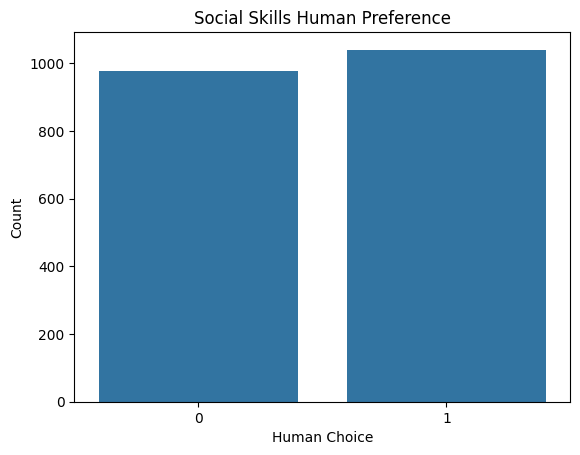

In [16]:
sns.countplot(data=social_df, x="human_choice")
plt.title("Social Skills Human Preference")
plt.xlabel("Human Choice")
plt.ylabel("Count")
plt.show()


In [17]:
import scipy.sparse as sp
from sklearn.preprocessing import MaxAbsScaler
from sklearn.naive_bayes import MultinomialNB


def text_stats(series: pd.Series) -> pd.DataFrame:

    s = series.astype(str)
    return pd.DataFrame({
        "char_len": s.str.len(),
        "word_count": s.str.split().apply(len),
        "has_question": s.str.contains(r"\?").astype(int),
        "has_exclaim": s.str.contains(r"!").astype(int),
    })


def build_numeric_features(resp_a: pd.Series, resp_b: pd.Series) -> pd.DataFrame:

    stats_a = text_stats(resp_a).add_suffix("_a")
    stats_b = text_stats(resp_b).add_suffix("_b")
    numeric = pd.concat([stats_a, stats_b], axis=1)

    raw_diff = stats_a["char_len_a"] - stats_b["char_len_b"]
    numeric["length_diff_abs"] = raw_diff.abs()
    numeric["a_is_longer"] = (raw_diff > 0).astype(int)
    return numeric


class SoftVotingOnlineEnsemble:


    def __init__(self, estimators):
    
        self.estimators = estimators
        self.classes_ = None

    def fit(self, X, y):
        self.classes_ = np.unique(y)
        for _, est in self.estimators:
            est.fit(X, y)
        return self

    def partial_fit(self, X, y, classes=None):
        if self.classes_ is None:
            self.classes_ = np.array(classes) if classes is not None else np.unique(y)
        for _, est in self.estimators:
            est.partial_fit(X, y, classes=self.classes_)
        return self

    def predict_proba(self, X):
        probs = [est.predict_proba(X) for _, est in self.estimators]
        return np.mean(probs, axis=0)  # soft voting

    def predict(self, X):
        avg_proba = self.predict_proba(X)
        return self.classes_[np.argmax(avg_proba, axis=1)]


In [18]:
social_df["combined_text"] = (
    "CATEGORY: " + social_df["category"].astype(str)
    + " SITUATION: " + social_df["situation"].astype(str)
    + " PROMPT: " + social_df["prompt"].astype(str)
    + " RESPONSE_A: " + social_df["response_a"].astype(str)
    + " RESPONSE_B: " + social_df["response_b"].astype(str)
)


numeric_features = build_numeric_features(social_df["response_a"], social_df["response_b"])

x_text = social_df["combined_text"]
y = social_df["human_choice"]


idx_trainval, idx_test = train_test_split(social_df.index, test_size=0.2, random_state=42, stratify=y)
idx_train, idx_val = train_test_split(idx_trainval, test_size=0.25, random_state=42, stratify=y.loc[idx_trainval])

print(f"Train: {len(idx_train)} | Validation: {len(idx_val)} | Test: {len(idx_test)}")

vectorizer = TfidfVectorizer(max_features=30000, ngram_range=(1, 2), min_df=2)
x_train_tfidf = vectorizer.fit_transform(x_text.loc[idx_train])
x_val_tfidf = vectorizer.transform(x_text.loc[idx_val])
x_test_tfidf = vectorizer.transform(x_text.loc[idx_test])


numeric_scaler = MaxAbsScaler()
num_train = numeric_scaler.fit_transform(numeric_features.loc[idx_train])
num_val = numeric_scaler.transform(numeric_features.loc[idx_val])
num_test = numeric_scaler.transform(numeric_features.loc[idx_test])

x_train_full = sp.hstack([x_train_tfidf, num_train]).tocsr()
x_val_full = sp.hstack([x_val_tfidf, num_val]).tocsr()
x_test_full = sp.hstack([x_test_tfidf, num_test]).tocsr()

y_train, y_val, y_test = y.loc[idx_train], y.loc[idx_val], y.loc[idx_test]

model = SoftVotingOnlineEnsemble([
    ("sgd_log", SGDClassifier(loss="log_loss", random_state=42)),
    ("sgd_huber", SGDClassifier(loss="modified_huber", random_state=7)),
    ("naive_bayes", MultinomialNB()),
])
model.fit(x_train_full, y_train)


Train: 1209 | Validation: 403 | Test: 404


Validation accuracy: 87.34%
Test accuracy: 91.34%
              precision    recall  f1-score   support

  Response A       0.91      0.91      0.91       196
  Response B       0.91      0.92      0.92       208

    accuracy                           0.91       404
   macro avg       0.91      0.91      0.91       404
weighted avg       0.91      0.91      0.91       404



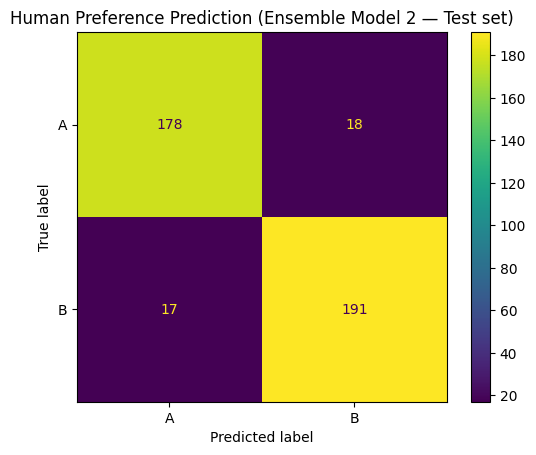

In [19]:
val_pred = model.predict(x_val_full)
print("Validation accuracy:", f"{accuracy_score(y_val, val_pred):.2%}")

y_pred = model.predict(x_test_full)
print("Test accuracy:", f"{accuracy_score(y_test, y_pred):.2%}")
print(classification_report(y_test, y_pred, target_names=["Response A", "Response B"]))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["A", "B"])
disp.plot()
plt.title("Human Preference Prediction (Ensemble Model 2 — Test set)")
plt.show()


In [20]:
print(type(social_df))
print(social_df.shape)
print(social_df.columns.tolist())

<class 'pandas.DataFrame'>
(2016, 7)
['category', 'situation', 'prompt', 'response_a', 'response_b', 'human_choice', 'combined_text']


In [21]:
joblib.dump(model, "social_skills_model.pkl")
joblib.dump(vectorizer, "social_skills_vectorizer.pkl")
joblib.dump(numeric_scaler, "social_skills_scaler.pkl")
print("Ensemble model + vectorizer + scaler saved successfully!")


Ensemble model + vectorizer + scaler saved successfully!


In [22]:
def transform_features(texts):
  
    if isinstance(texts, str):
        texts = [texts]
    texts = pd.Series(texts).astype(str)

    tfidf_part = vectorizer.transform(texts)

   
    stats = text_stats(texts)
    numeric = pd.concat([stats.add_suffix("_a"), stats.add_suffix("_b")], axis=1)
  
    numeric["length_diff_abs"] = 0
    numeric["a_is_longer"] = 0
    numeric = numeric[numeric_features.columns]

    numeric_scaled = numeric_scaler.transform(numeric)
    return sp.hstack([tfidf_part, numeric_scaled]).tocsr()


In [23]:
load_dotenv(override=True)
GEMINI_API_KEY = os.getenv("GEMINI_API_KEY")

GEMINI_AVAILABLE = False
client = None

if GEMINI_API_KEY:
    try:
        from google import genai
        client = genai.Client(api_key=GEMINI_API_KEY)
        GEMINI_AVAILABLE = True
        print("Gemini connected!")
    except Exception as e:
        print(f"[warn] Gemini client could not be created: {e}")
else:
    print("[warn] GEMINI_API_KEY not found - offline fallback will be used.")


Gemini connected!


In [ ]:
SYSTEM_PROMPT = """You are a social skills assistant.

The user will describe a social situation.

Generate two different but reasonable responses.

Response A should be practical and direct.
Response B should be empathetic and detailed.

Both responses must be helpful.
Do not say which response is better.

Return the result in this exact format:

RESPONSE_A:
...

RESPONSE_B:
..."""

def parse_gemini_response(raw_text: str):
    match = re.search(
        r"RESPONSE_A:\s*(.*?)\s*RESPONSE_B:\s*(.*)",
        raw_text, re.DOTALL | re.IGNORECASE
    )
    if not match:
        raise ValueError("Could not parse RESPONSE_A / RESPONSE_B from Gemini output:\n" + raw_text)
    return match.group(1).strip(), match.group(2).strip()


def _offline_generate(prompt: str):
    """Deterministic fallback used when Gemini is unreachable (network block, quota, etc.)."""
    return (
        f"A practical next step: think through the situation directly - '{prompt}' - and take one concrete action right now.",
        f"An empathetic take: it's completely normal to feel this way about '{prompt}'. Be kind to yourself and take it one small step at a time.",
    )


def generate_responses(prompt: str):
    if GEMINI_AVAILABLE:
        try:
            response = client.models.generate_content(
                model="gemini-3.6-flash",
                contents=prompt,
                config={"system_instruction": SYSTEM_PROMPT}
            )
            return parse_gemini_response(response.text)
        except Exception as e:
            print(f"[warn] Gemini call failed ({e}); using offline fallback.")
    return _offline_generate(prompt)


In [25]:
raw_a, raw_b = generate_responses("Explain machine learning.")
print("RESPONSE A:\n", raw_a)
print("\nRESPONSE B:\n", raw_b)


[warn] Gemini call failed (403 Forbidden. {'message': '<!DOCTYPE html>\n<html lang=en>\n  <meta charset=utf-8>\n  <meta name=viewport content="initial-scale=1, minimum-scale=1, width=device-width">\n  <title>Error 403 (Forbidden)!!1</title>\n  <style>\n    *{margin:0;padding:0}html,code{font:15px/22px arial,sans-serif}html{background:#fff;color:#222;padding:15px}body{margin:7% auto 0;max-width:390px;min-height:180px;padding:30px 0 15px}* > body{background:url(//www.google.com/images/errors/robot.png) 100% 5px no-repeat;padding-right:205px}p{margin:11px 0 22px;overflow:hidden}ins{color:#777;text-decoration:none}a img{border:0}@media screen and (max-width:772px){body{background:none;margin-top:0;max-width:none;padding-right:0}}#logo{background:url(//www.google.com/images/branding/googlelogo/1x/googlelogo_color_150x54dp.png) no-repeat;margin-left:-5px}@media only screen and (min-resolution:192dpi){#logo{background:url(//www.google.com/images/branding/googlelogo/2x/googlelogo_color_150x54d

In [26]:
def get_human_feedback_binary():
    """Ask the human which response they prefer: A or B."""
    print("\nHuman feedback:")
    print("0 -> Choose A")
    print("1 -> Choose B")
    while True:
        feedback = input("Your choice: ")
        if feedback in ["0", "1"]:
            return int(feedback)
        print("Please enter 0 or 1.")


In [27]:
FEEDBACK_LOG_PATH = Path("feedback_log.jsonl")

def log_feedback(entry: dict) -> None:
    entry = dict(entry)
    entry["timestamp"] = datetime.now(timezone.utc).isoformat()
    with FEEDBACK_LOG_PATH.open("a", encoding="utf-8") as f:
        f.write(json.dumps(entry, ensure_ascii=False) + "\n")

def load_feedback_history():
    if not FEEDBACK_LOG_PATH.exists():
        return []
    with FEEDBACK_LOG_PATH.open(encoding="utf-8") as f:
        return [json.loads(line) for line in f if line.strip()]

def agreement_rate(history) -> float:
    if not history:
        return 0.0
    correct = sum(1 for h in history if h["ai_prediction"] == h["human_feedback"])
    return correct / len(history)


In [28]:
def full_pipeline(situation_prompt: str, category: str = "General", situation: str = ""):
    """
    End-to-end collaborative decision pipeline:
      1. Gemini (or the offline fallback) generates RESPONSE_A / RESPONSE_B
      2. The trained social-skills model predicts which one a human would prefer
      3. A real human gives feedback
      4. The model is updated online (partial_fit) with that feedback, and the event is logged
    """
    response_a, response_b = generate_responses(situation_prompt)

    print("\n============================")
    print("GENERATED RESPONSES")
    print("============================")
    print("A:", response_a)
    print("\nB:", response_b)

    combined_text = (
        "CATEGORY: " + str(category)
        + " SITUATION: " + str(situation)
        + " PROMPT: " + str(situation_prompt)
        + " RESPONSE_A: " + str(response_a)
        + " RESPONSE_B: " + str(response_b)
    )
    text_vector = transform_features([combined_text])

    prediction = model.predict(text_vector)[0]
    probabilities = model.predict_proba(text_vector)[0]

    print("\n============================")
    print("AI PREDICTION")
    print("============================")
    print(f"A probability: {probabilities[0]:.2%}")
    print(f"B probability: {probabilities[1]:.2%}")
    print("AI Recommendation:", "A" if prediction == 0 else "B")

    print("\n============================")
    print("HUMAN FEEDBACK")
    print("============================")
    human_feedback = get_human_feedback_binary()

    model.partial_fit(text_vector, [human_feedback])
    print("\nModel updated successfully.")

    entry = {
        "prompt": situation_prompt,
        "response_a": response_a,
        "response_b": response_b,
        "ai_prediction": int(prediction),
        "probabilities": {"A": float(probabilities[0]), "B": float(probabilities[1])},
        "human_feedback": human_feedback,
    }
    log_feedback(entry)
    return entry


In [29]:
# result = full_pipeline(
#     situation_prompt="I have to give a presentation tomorrow and I am really nervous.",
#     category="Public Speaking",
#     situation="Nervous before presenting",
# )
# result


In [30]:
decisions = [
    "Hi, I'm new to this group. Is this your first time here?",
    "Hi, this looks really cool. Do you come here often?",
    "Hi, can I introduce myself? I'm Zahra.",
    "Hi, how are you? I hope you're having a good day.",
]

results = score_decisions("I want to start a conversation with a new person.", decisions)

for item in results:
    print(f"Rank {item['rank']} | Decision {item['decision_id']} | Score: {item['score']}%")
    print(item["decision"])
    print("-" * 60)


NameError: name 'score_decisions' is not defined

In [ ]:
plt.figure(figsize=(7, 3))
labels = [f"Decision {item['decision_id']}" for item in results]
scores = [item["score"] for item in results]
colors = ["#4FB8AE" if i == 0 else "#E8A33D" for i in range(len(results))]
bars = plt.barh(labels[::-1], scores[::-1], color=colors[::-1])
plt.xlabel("Score (%)")
plt.title("Decision Ranking")
plt.xlim(0, 100)
for bar, score in zip(bars, scores[::-1]):
    plt.text(bar.get_width() + 1, bar.get_y() + bar.get_height() / 2, f"{score}%", va="center")
plt.tight_layout()
plt.show()


NameError: name 'results' is not defined

<Figure size 700x300 with 0 Axes>

In [ ]:
#"Feed Back analysis reports"
history = load_feedback_history()
print("Total feedback events:", len(history))
print(f"Agreement rate: {agreement_rate(history):.2%}")


Total feedback events: 0
Agreement rate: 0.00%


In [ ]:
def _top_contributing_terms(text: str, target_class: int, top_n: int = 5):
    """Words/bigrams present in `text` that push the prediction most toward target_class."""

    n_tfidf = len(vectorizer.get_feature_names_out())
    X_full = transform_features([text])
    X_tfidf_part = X_full[:, :n_tfidf]
    feature_names = np.array(vectorizer.get_feature_names_out())
    present_idx = X_tfidf_part.nonzero()[1]
    if len(present_idx) == 0:
        return []

    sgd_model = dict(model.estimators)["sgd_log"]
    classes = list(sgd_model.classes_)
    class_row = classes.index(target_class) if target_class in classes else 0
    coefs = sgd_model.coef_[class_row] if sgd_model.coef_.shape[0] > 1 else sgd_model.coef_[0]

    weighted = [(feature_names[i], coefs[i] * X_tfidf_part[0, i]) for i in present_idx]
    weighted.sort(key=lambda t: t[1], reverse=True)
    return [term for term, weight in weighted[:top_n] if weight > 0]


def _offline_explain(prompt, winner, others):
    """Deterministic, no-LLM explanation."""
    winner_text = f"PROMPT: {prompt} DECISION: {winner['decision']}"
    terms = _top_contributing_terms(winner_text, winner["prediction"])
    gap = round(winner["score"] - (others[0]["score"] if others else 0), 1)

    reason = f"{gap}"
    if terms:
        reason += " عبارت‌های '" + "'، '".join(terms) + "' در این گزینه بیشترین نقش را در امتیاز بالاتر داشتند."
    return reason


def explain_choice(prompt, results):
    """Short natural-language reason for why results[0] (the winner) is better."""
    winner = results[0]
    others = results[1:]

    if GEMINI_AVAILABLE:
        try:
            others_text = "\n".join(f"- {o['decision']}" for o in others)
            explain_prompt = (
                f"Situation: {prompt}\n\n"
                f"Recommended option: \"{winner['decision']}\"\n\n"
                f"Other option(s):\n{others_text}\n\n"
                "In 2-3 short sentences, explain why the recommended option is "
                "the better choice in this situation. Be specific and concrete. "
                "Reply in the same language as the situation text."
            )
            response = client.models.generate_content(
                model="gemini-2.5-flash",
                contents=explain_prompt,
            )
            return response.text.strip()
        except Exception as e:
            print(f"[warn] Gemini explanation failed ({e}); using offline explanation.")

    return _offline_explain(prompt, winner, others)


def compare_decisions(prompt, decisions):
    """Rank your own candidate decisions and explain why the top one wins."""
    results = score_decisions(prompt, decisions)
    reason = explain_choice(prompt, results)
    return {
        "best_decision": results[0]["decision"],
        "reason": reason,
        "ranking": results,
    }


In [ ]:

my_options = [
    "should I ask him whats up? and after that introduce myself",
    "or ask how are you? and after that introduce myself",
]

comparison = compare_decisions(
    "I want to start a conversation with a new person.",
    my_options,
)

print("Best option:", comparison["best_decision"])
print("Why:", comparison["reason"])
print()
for item in comparison["ranking"]:
    print(f"Rank {item['rank']} | Score: {item['score']}% | {item['decision']}")


[warn] Gemini explanation failed (403 Forbidden. {'message': '<!DOCTYPE html>\n<html lang=en>\n  <meta charset=utf-8>\n  <meta name=viewport content="initial-scale=1, minimum-scale=1, width=device-width">\n  <title>Error 403 (Forbidden)!!1</title>\n  <style>\n    *{margin:0;padding:0}html,code{font:15px/22px arial,sans-serif}html{background:#fff;color:#222;padding:15px}body{margin:7% auto 0;max-width:390px;min-height:180px;padding:30px 0 15px}* > body{background:url(//www.google.com/images/errors/robot.png) 100% 5px no-repeat;padding-right:205px}p{margin:11px 0 22px;overflow:hidden}ins{color:#777;text-decoration:none}a img{border:0}@media screen and (max-width:772px){body{background:none;margin-top:0;max-width:none;padding-right:0}}#logo{background:url(//www.google.com/images/branding/googlelogo/1x/googlelogo_color_150x54dp.png) no-repeat;margin-left:-5px}@media only screen and (min-resolution:192dpi){#logo{background:url(//www.google.com/images/branding/googlelogo/2x/googlelogo_color_

In [ ]:
import nest_asyncio
import uvicorn
from fastapi import FastAPI, HTTPException
from fastapi.responses import HTMLResponse
from pydantic import BaseModel, Field
from typing import List

nest_asyncio.apply()


In [ ]:
FRONTEND_HTML = r"""
<!DOCTYPE html>
<html lang="en" dir="ltr" id="htmlRoot">
<head>
<meta charset="UTF-8">
<meta name="viewport" content="width=device-width, initial-scale=1.0">
<title>Tandem Echo — Business Dashboard</title>
<link rel="preconnect" href="https://fonts.googleapis.com">
<link href="https://fonts.googleapis.com/css2?family=Space+Grotesk:wght@400;500;600;700&family=Vazirmatn:wght@400;500;600;700&family=Inter:wght@400;500;600;700&family=IBM+Plex+Mono:wght@400;500;600&family=IBM+Plex+Sans+Arabic:wght@400;500;600;700&family=Noto+Naskh+Arabic:wght@400;500;600;700&family=Noto+Kufi+Arabic:wght@400;500;600;700&display=swap" rel="stylesheet">
<style>
  :root{
    --bg-deep:#172333; --surface:#292e35; --surface-raised:#1A222B;
    --line:#242F39; --line-soft:#6b6e6e;
    --text-primary:#EDF1F5; --text-muted:#8695A3; --text-faint:#54626F;
    --teal:#34D1C4; --teal-dim:#1E4A47;
    --amber:#F0A93E; --amber-dim:#4A3A1E;
    --red:#E0605C; --red-dim:#4A2422;
    --radius:14px;
    --font-body:'Vazirmatn','Inter',sans-serif;
    --font-display:'Space Grotesk',sans-serif;
  }
  *{box-sizing:border-box; margin:0; padding:0;}
  html,body{height:100%; max-width:100%; overflow-x:hidden;}
  body{
    background:
      radial-gradient(ellipse 900px 500px at 15% -10%, rgba(52,209,196,0.07), transparent),
      radial-gradient(ellipse 700px 500px at 100% 100%, rgba(240,169,62,0.05), transparent),
      var(--bg-deep);
    color:var(--text-primary);
    font-family:var(--font-body);
    min-height:100vh; display:flex; flex-direction:column;
    -webkit-font-smoothing:antialiased;
  }
  html[lang="en"] body{ --font-body:'Inter','Space Grotesk',sans-serif; }
  body.font-vazir{ --font-body:'Vazirmatn','Inter',sans-serif !important; }
  body.font-plex{ --font-body:'IBM Plex Sans Arabic','Inter',sans-serif !important; }
  body.font-naskh{ --font-body:'Noto Naskh Arabic','Inter',serif !important; }
  body.font-kufi{ --font-body:'Noto Kufi Arabic','Space Grotesk',sans-serif !important; }
  .mono{font-family:'IBM Plex Mono','Space Grotesk',monospace;}

  /* ===== Top bar ===== */
  .topbar{ display:flex; align-items:center; justify-content:space-between; padding:16px 28px; border-bottom:1px solid var(--line-soft); gap:14px; flex-wrap:wrap; max-width:100%; }
  .brand{display:flex; align-items:center; gap:10px; min-width:0;}
  .brand-mark{ width:30px; height:30px; border-radius:8px; background:conic-gradient(from 220deg, var(--teal), var(--amber) 40%, var(--red) 75%, var(--teal)); position:relative; }
  .brand-mark::after{ content:''; position:absolute; inset:4px; border-radius:5px; background:var(--bg-deep); }
  .brand-name{font-family:var(--font-display); font-weight:700; font-size:17px; letter-spacing:0.3px;}
  .brand-sub{font-size:11px; color:var(--text-faint); letter-spacing:1px; text-transform:uppercase; margin-inline-start:10px; padding-inline-start:10px; border-inline-start:1px solid var(--line);}
  .topbar-right{display:flex; align-items:center; gap:12px; flex-wrap:wrap; min-width:0; justify-content:flex-end;}

  .business-search{ position:relative; width:230px; max-width:44vw; min-width:130px; flex-shrink:1; }
  .business-search-box{
    display:flex; align-items:center; gap:8px;
    background:var(--surface); border:1px solid var(--line); border-radius:999px;
    padding:0 6px 0 14px; height:34px; transition:border-color .15s ease, box-shadow .15s ease;
  }
  html[dir="rtl"] .business-search-box{ padding:0 14px 0 6px; }
  .business-search-box:focus-within{ border-color:var(--teal); box-shadow:0 0 0 3px var(--teal-dim); }
  .business-search-box .search-icon{ font-size:13px; color:var(--text-faint); flex-shrink:0; }
  .business-search-box input{
    flex:1; background:transparent; border:none; outline:none; color:var(--text-primary);
    font-family:var(--font-body); font-size:13px; height:100%; min-width:0;
  }
  .business-search-box input::placeholder{ color:var(--text-faint); }
  .business-search-box button{
    width:24px; height:24px; border-radius:50%; border:none; background:transparent;
    color:var(--text-faint); font-size:13px; cursor:pointer; flex-shrink:0;
    display:flex; align-items:center; justify-content:center; transition:background .15s ease,color .15s ease;
  }
  .business-search-box button:hover{ background:var(--line); color:var(--text-muted); }
  .business-search-results{
    position:absolute; top:42px; inset-inline-start:0; inset-inline-end:0;
    background:var(--surface-raised); border:1px solid var(--line); border-radius:9px;
    box-shadow:0 8px 24px -8px rgba(0,0,0,0.45);
    opacity:0; visibility:hidden; transform:translateY(-6px);
    transition:opacity .15s ease, transform .15s ease, visibility .15s;
    z-index:60; max-height:340px; overflow-y:auto; padding:6px;
  }
  .business-search-results.open{ opacity:1; visibility:visible; transform:translateY(0); }
  .biz-group-label{ font-size:10.5px; color:var(--text-faint); letter-spacing:0.5px; text-transform:uppercase; padding:8px 10px 4px; }
  .biz-result{
    display:flex; align-items:center; justify-content:space-between; gap:10px;
    padding:9px 10px; border-radius:7px; cursor:pointer; font-size:12.5px;
  }
  .biz-result:hover, .biz-result.active{ background:var(--surface); }
  .biz-result b{ font-weight:500; color:var(--text-primary); }
  .biz-result span{ color:var(--text-faint); font-size:11px; white-space:nowrap; }
  .biz-result mark{ background:none; color:var(--teal); font-weight:600; }

  .clock-chip{
    display:flex; flex-direction:column; align-items:flex-end;
    background:var(--surface); border:1px solid var(--line); border-radius:10px;
    padding:7px 12px; line-height:1.4;
  }
  html[lang="en"] .clock-chip{align-items:flex-start;}
  .clock-time{font-family:'IBM Plex Mono',monospace; font-size:13px; font-weight:600; color:var(--text-primary);}
  .clock-zone{font-size:9.5px; color:var(--text-faint); letter-spacing:0.5px; text-transform:uppercase;}

  .lang-toggle{ display:flex; background:var(--surface); border:1px solid var(--line); border-radius:20px; padding:3px; }
  .lang-btn{ padding:6px 13px; border-radius:16px; font-size:12px; color:var(--text-faint); cursor:pointer; font-family:var(--font-body); white-space:nowrap; }
  .lang-btn.on{background:var(--teal); color:#04211E; font-weight:600;}

  .theme-wrap{position:relative;}
  .theme-btn{ position:relative; width:34px; height:34px; border-radius:9px; display:flex; align-items:center; justify-content:center; background:var(--surface); border:1px solid var(--line); cursor:pointer; font-size:15px; }
  .theme-btn:hover{border-color:var(--line);}
  .theme-dot-preview{width:16px; height:16px; border-radius:50%; background:var(--teal); border:2px solid var(--surface-raised); box-shadow:0 0 0 1px var(--line);}
  .theme-panel{
    position:absolute; top:44px; inset-inline-start:0; width:220px;
    background:var(--surface-raised); border:1px solid var(--line); border-radius:12px;
    box-shadow:0 8px 24px -8px rgba(0,0,0,0.45);
    opacity:0; visibility:hidden; transform:translateY(-8px);
    transition:opacity .18s ease, transform .18s ease, visibility .18s; z-index:60; padding:14px;
  }
  .theme-panel.open{opacity:1; visibility:visible; transform:translateY(0);}
  .theme-panel-title{font-size:11.5px; font-weight:600; color:var(--text-primary); margin-bottom:12px;}
  .theme-swatch-row{display:flex; gap:10px; flex-wrap:wrap;}
  .theme-swatch{
    width:30px; height:30px; border-radius:50%; cursor:pointer; position:relative;
    border:2px solid transparent; display:flex; align-items:center; justify-content:center;
    font-size:12px; color:#fff; transition:transform .12s ease;
  }
  .theme-swatch:hover{transform:scale(1.08);}
  .theme-swatch.active{border-color:var(--text-primary);}
  .notif-bell{ position:relative; width:34px; height:34px; border-radius:9px; display:flex; align-items:center; justify-content:center; background:var(--surface); border:1px solid var(--line); cursor:pointer; color:var(--text-muted); font-size:15px; }
  .notif-bell:hover{color:var(--text-primary);}
  .notif-badge{ position:absolute; top:-4px; inset-inline-start:-4px; min-width:16px; height:16px; border-radius:8px; border:solid,red,1px; color:#fff; font-size:9.5px; font-weight:700; display:flex; align-items:center; justify-content:center; font-family:'IBM Plex Mono',monospace; padding:0 3px; }
  .notif-panel{
    position:absolute; top:44px; inset-inline-start:0; width:320px;
    background:var(--surface-raised); border:1px solid var(--line); border-radius:12px;
    box-shadow:0 8px 24px -8px rgba(0,0,0,0.45);
    opacity:0; visibility:hidden; transform:translateY(-8px);
    transition:opacity .18s ease, transform .18s ease, visibility .18s; z-index:60; overflow:hidden;
  }
  .notif-panel.open{opacity:1; visibility:visible; transform:translateY(0);}
  .notif-head{padding:12px 14px; font-size:12px; font-weight:600; border-bottom:1px solid var(--line-soft);}
  .notif-item{display:flex; gap:10px; padding:12px 14px; border-bottom:1px solid var(--line-soft); cursor:pointer;}
  .notif-item:last-child{border-bottom:none;}
  .notif-item:hover{background:var(--surface);}
  .notif-icon{width:26px; height:26px; border-radius:7px; flex-shrink:0; display:flex; align-items:center; justify-content:center; font-size:13px;}
  .notif-icon.urgent{background:var(--red-dim); color:var(--red);}
  .notif-icon.warn{background:var(--amber-dim); color:var(--amber);}
  .notif-icon.info{background:var(--teal-dim); color:var(--teal);}
  .notif-body{flex:1; min-width:0;}
  .notif-title{font-size:12px; color:var(--text-primary); line-height:1.6;}
  .notif-time{font-size:10px; color:var(--text-faint); margin-top:3px; font-family:'IBM Plex Mono',monospace;}
  .status-chip{display:flex; align-items:center; gap:7px; font-size:12px; color:var(--text-muted); background:var(--surface); border:1px solid var(--line); padding:6px 12px; border-radius:20px;}
  .status-dot{width:7px; height:7px; border-radius:50%; background:var(--teal); box-shadow:0 0 8px var(--teal); animation:pulse 2.2s ease-in-out infinite;}
  @keyframes pulse{0%,100%{opacity:1;}50%{opacity:0.4;}}

  /* ===== Layout ===== */
  .app{ flex:1; display:grid; grid-template-columns:64px 1fr 340px; gap:1px; background:var(--line-soft); overflow:hidden; }
  .rail, .stage, .panel{background:var(--bg-deep);}
  .rail{ display:flex; flex-direction:column; align-items:center; padding:20px 0; gap:6px; }
  .rail-item{ width:40px; height:40px; border-radius:10px; display:flex; align-items:center; justify-content:center; color:var(--text-faint); cursor:pointer; font-size:16px; transition:background .15s, color .15s; position:relative; overflow:hidden; }
  .rail-item span{ display:none; }
  .rail-item:hover{background:var(--surface); color:var(--text-muted);}
  .rail-item.active{background:var(--teal-dim); color:var(--teal);}
  .rail-item.active::before{ content:''; position:absolute; inset-inline-end:-14px; top:50%; transform:translateY(-50%); width:3px; height:18px; border-radius:2px; background:var(--teal); }
  .rail-spacer{flex:1;}

  .stage{ padding:26px 32px; display:flex; flex-direction:column; overflow-y:auto; }
  .stage-head{margin-bottom:22px;}
  .eyebrow{ font-size:11px; letter-spacing:2px; text-transform:uppercase; color:var(--teal); font-family:'IBM Plex Mono',monospace; margin-bottom:8px; }
  .stage-title{font-family:var(--font-display); font-size:26px; font-weight:600;}
  .stage-desc{color:var(--text-muted); font-size:13.5px; margin-top:6px; max-width:540px; line-height:1.7;}

  .queue-meta{display:flex; align-items:center; gap:12px; margin-top:18px; flex-wrap:wrap;}
  .queue-count{font-size:12px; color:var(--text-faint); font-family:'IBM Plex Mono',monospace; white-space:nowrap;}
  .queue-bar{flex:1; min-width:80px; height:3px; background:var(--surface); border-radius:2px; overflow:hidden;}
  .queue-bar-fill{height:100%; background:linear-gradient(90deg,var(--teal),var(--amber)); border-radius:2px; transition:width .5s ease;}
  .triage-btn, .batch-toggle-btn{ display:flex; align-items:center; gap:6px; font-size:12px; color:var(--text-faint); background:var(--surface); border:1px solid var(--line-soft); border-radius:8px; padding:7px 12px; cursor:pointer; white-space:nowrap; }
  .triage-btn:hover, .batch-toggle-btn:hover{color:var(--text-muted);}
  .batch-toggle-btn.on{color:var(--teal); border-color:var(--teal); background:var(--teal-dim);}

  .card-zone{flex:1; display:flex; align-items:center; justify-content:center; position:relative; min-height:340px;}
  .rec-card{
    width:100%; max-width:520px; position:relative;
    background:linear-gradient(180deg, var(--surface-raised), var(--surface));
    border:1px solid var(--line); border-radius:var(--radius); padding:26px 26px 22px;
    box-shadow:0 8px 24px -8px rgba(0,0,0,0.4);
    transition:transform .35s cubic-bezier(.2,.8,.2,1), opacity .35s ease;
  }
  .rec-card.leaving-approve{ transform:translateX(120%) rotate(8deg); opacity:0; }
  .rec-card.leaving-decline{ transform:translateX(-120%) rotate(-8deg); opacity:0; }
  .rec-card.leaving-adjust{ transform:translateY(-60px) scale(0.92); opacity:0; }
  .rec-card.entering{ animation:cardIn .4s cubic-bezier(.2,.8,.2,1); }
  @keyframes cardIn{ from{opacity:0; transform:translateY(14px) scale(0.98);} to{opacity:1; transform:none;} }

  .card-top{display:flex; align-items:flex-start; justify-content:space-between; gap:14px;}
  .card-tag{font-size:10.5px; letter-spacing:1px; text-transform:uppercase; padding:4px 9px; border-radius:6px; font-family:'IBM Plex Mono',monospace;}
  .tag-inventory{background:var(--teal-dim); color:var(--teal);}
  .tag-risk{background:var(--red-dim); color:var(--red);}
  .tag-ops{background:var(--amber-dim); color:var(--amber);}
  .tag-support{background:#2a2450; color:#9b8cf0;}
  .conf-badge{display:flex; align-items:center; gap:6px;}
  .conf-badge .num{font-family:'IBM Plex Mono',monospace; font-size:13px; font-weight:600;}
  .conf-badge .lbl{font-size:10px; color:var(--text-faint); letter-spacing:0.5px;}
  .card-title{font-family:var(--font-display); font-size:20px; font-weight:600; margin-top:16px; line-height:1.4;}
  .card-reason{color:var(--text-muted); font-size:13.5px; margin-top:8px; line-height:1.75;}
  .card-meta-row{display:flex; gap:18px; margin-top:16px; padding-top:14px; border-top:1px dashed var(--line); flex-wrap:wrap;}
  .meta-item{font-size:11.5px; color:var(--text-faint);}
  .meta-item b{color:var(--text-muted); font-weight:500; display:block; font-family:'IBM Plex Mono',monospace; font-size:12px; margin-bottom:2px;}
  .card-actions{display:flex; gap:10px; margin-top:20px;}
  .btn{ flex:1; padding:11px 14px; border-radius:10px; border:1px solid transparent; font-family:var(--font-body); font-size:13.5px; font-weight:600; cursor:pointer; display:flex; align-items:center; justify-content:center; gap:7px; transition:transform .12s ease, filter .12s ease; }
  .btn:active{transform:scale(0.96);}
  .btn-approve{background:var(--teal); color:#04211E;}
  .btn-approve:hover{filter:brightness(1.08);}
  .btn-adjust, .btn-decline{background:transparent; border-color:var(--line); color:var(--text-muted);}
  .btn-adjust:hover{border-color:var(--amber); color:var(--amber);}
  .btn-decline:hover{border-color:var(--red); color:var(--red);}
  .empty-state{text-align:center; color:var(--text-faint); max-width:340px;}
  .empty-state .big{font-family:var(--font-display); font-size:18px; color:var(--text-muted); margin-bottom:8px;}

  .why-toggle, .compare-toggle{ display:flex; align-items:center; gap:6px; margin-top:14px; font-size:12px; color:var(--text-faint); cursor:pointer; width:fit-content; user-select:none; }
  .why-toggle:hover, .compare-toggle:hover{color:var(--text-muted);}
  .why-toggle .chev{transition:transform .2s ease; font-size:10px;}
  .why-toggle.open .chev{transform:rotate(180deg);}
  .why-body, .compare-strip, .whatif-body{max-height:0; overflow:hidden; transition:max-height .25s ease;}
  .why-body.open{max-height:220px; margin-top:10px;}
  .compare-strip.open{max-height:220px; margin-top:14px;}
  .whatif-body.open{max-height:140px; margin-top:10px;}
  .factor-row{display:flex; align-items:center; gap:10px; margin-bottom:8px;}
  .factor-label{font-size:11.5px; color:var(--text-muted); width:120px; flex-shrink:0;}
  .factor-track{flex:1; height:6px; background:var(--bg-deep); border-radius:3px; overflow:hidden;}
  .factor-fill{height:100%; border-radius:3px; background:var(--teal);}
  .factor-val{font-family:'IBM Plex Mono',monospace; font-size:11px; color:var(--text-faint); width:34px;}
  .kbd-hint{display:flex; align-items:center; gap:6px; justify-content:center; margin-top:14px; font-size:11px; color:var(--text-faint); flex-wrap:wrap;}
  .kbd-hint kbd{font-family:'IBM Plex Mono',monospace; font-size:10px; color:var(--text-muted); background:var(--surface); border:1px solid var(--line); border-radius:5px; padding:2px 6px;}

  .card-secondary-actions{display:flex; gap:8px; margin-top:12px;}
  .btn-ghost-small{flex:1; padding:8px 10px; border-radius:8px; border:1px solid var(--line-soft); background:transparent; color:var(--text-faint); font-size:11.5px; cursor:pointer; font-family:var(--font-body);}
  .btn-ghost-small:hover{color:var(--text-muted); border-color:var(--line);}
  .whatif-line{display:flex; align-items:center; gap:8px; background:var(--bg-deep); border:1px solid var(--line-soft); border-radius:9px; padding:10px 12px; font-size:11.5px; color:var(--text-muted); line-height:1.7;}
  .whatif-line b{color:var(--teal);}

  .compare-grid{display:grid; grid-template-columns:1fr 1fr; gap:10px;}
  .compare-box{background:var(--bg-deep); border:1px solid var(--line-soft); border-radius:10px; padding:13px;}
  .compare-box.current{border-color:#2a3b41;}
  .compare-box .cb-tag{font-size:9.5px; color:var(--text-faint); text-transform:uppercase; letter-spacing:1px; font-family:'IBM Plex Mono',monospace;}
  .compare-box .cb-title{font-size:12.5px; color:var(--text-primary); margin-top:6px; line-height:1.6;}
  .compare-box .cb-foot{display:flex; justify-content:space-between; margin-top:10px; padding-top:10px; border-top:1px dashed var(--line-soft);}
  .compare-box .cb-conf{font-family:'IBM Plex Mono',monospace; font-size:12px;}
  .compare-box .cb-outcome{font-size:11px; padding:2px 8px; border-radius:6px;}

  .swipe-flag{ position:absolute; top:20px; padding:5px 12px; border-radius:7px; font-size:12px; font-weight:700; letter-spacing:1px; text-transform:uppercase; opacity:0; transition:opacity .1s ease; pointer-events:none; font-family:'IBM Plex Mono',monospace; }
  .swipe-flag.approve{inset-inline-end:20px; background:var(--teal); color:#04211E; transform:rotate(-8deg);}
  .swipe-flag.decline{inset-inline-start:20px; background:var(--red); color:#2a0d0c; transform:rotate(8deg);}

  .autonomy{margin-top:22px; background:var(--surface); border:1px solid var(--line-soft); border-radius:12px; padding:16px 18px;}
  .autonomy-head{display:flex; justify-content:space-between; align-items:center; margin-bottom:12px; gap:10px; flex-wrap:wrap;}
  .autonomy-title{font-size:12.5px; font-weight:600;}
  .autonomy-sub{font-size:11px; color:var(--text-faint); margin-top:2px;}
  .autonomy-val{font-family:'IBM Plex Mono',monospace; font-size:12px; color:var(--amber);}
  .seg{display:flex; gap:6px; flex-wrap:wrap;}
  .seg-btn{flex:1; min-width:80px; text-align:center; padding:9px 6px; border-radius:8px; cursor:pointer; font-size:11.5px; color:var(--text-faint); background:var(--bg-deep); border:1px solid var(--line-soft); transition:all .15s ease;}
  .seg-btn.on{background:var(--amber-dim); color:var(--amber); border-color:var(--amber);}

  /* ===== Batch review ===== */
  .batch-bar{display:flex; align-items:center; gap:14px; margin-top:14px; background:var(--teal-dim); border:1px solid var(--teal); border-radius:10px; padding:11px 14px; flex-wrap:wrap;}
  .batch-bar-text{font-size:12.5px; color:#bdf0ec; flex:1;}
  .batch-approve-btn{background:var(--teal); color:#04211E; border:none; padding:8px 16px; border-radius:8px; font-size:12.5px; font-weight:600; cursor:pointer; font-family:var(--font-body);}
  .batch-list{display:flex; flex-direction:column; gap:10px; margin-top:16px;}
  .batch-item{display:flex; align-items:center; gap:12px; background:var(--surface); border:1px solid var(--line-soft); border-radius:11px; padding:13px 15px; cursor:pointer;}
  .batch-item.checked{border-color:var(--teal); background:var(--teal-dim);}
  .batch-check{width:18px; height:18px; border-radius:5px; border:1.5px solid var(--line); flex-shrink:0; display:flex; align-items:center; justify-content:center; font-size:11px; color:#04211E;}
  .batch-item.checked .batch-check{background:var(--teal); border-color:var(--teal);}
  .batch-item-body{flex:1; min-width:0;}
  .batch-item-title{font-size:12.5px; color:var(--text-primary);}
  .batch-item-conf{font-family:'IBM Plex Mono',monospace; font-size:11.5px; color:var(--teal); flex-shrink:0;}

  /* ===== Panel ===== */
  .panel{display:flex; flex-direction:column; padding:22px 20px; overflow-y:auto;}
  .panel-block{margin-bottom:22px;}
  .panel-label{font-size:11px; letter-spacing:1.2px; text-transform:uppercase; color:var(--text-faint); margin-bottom:14px; font-family:'IBM Plex Mono',monospace;}
  .calib-wrap{display:flex; align-items:center; gap:16px; background:var(--surface); border:1px solid var(--line-soft); border-radius:12px; padding:16px;}
  .ring-svg{flex-shrink:0;}
  .calib-figs .fig-num{font-family:var(--font-display); font-size:24px; font-weight:700; line-height:1;}
  .calib-figs .fig-lbl{font-size:11px; color:var(--text-muted); margin-top:4px; line-height:1.5;}
  .stat-row{display:flex; gap:10px; margin-top:14px;}
  .stat-box{flex:1; background:var(--surface); border:1px solid var(--line-soft); border-radius:10px; padding:12px;}
  .stat-box .n{font-family:'IBM Plex Mono',monospace; font-size:18px; font-weight:600;}
  .stat-box .l{font-size:10.5px; color:var(--text-faint); margin-top:3px;}
  .n.teal{color:var(--teal);} .n.amber{color:var(--amber);} .n.red{color:var(--red);}
  .log-list{display:flex; flex-direction:column; gap:10px; flex:1;}
  .log-item{display:flex; gap:10px; align-items:flex-start; padding:10px 12px; background:var(--surface); border:1px solid var(--line-soft); border-radius:10px; animation:logIn .3s ease;}
  @keyframes logIn{ from{opacity:0; transform:translateY(-6px);} to{opacity:1; transform:none;} }
  .log-dot{width:8px; height:8px; border-radius:50%; margin-top:5px; flex-shrink:0;}
  .log-dot.approve{background:var(--teal);}
  .log-dot.adjust{background:var(--amber);}
  .log-dot.decline{background:var(--red);}
  .log-body{flex:1; min-width:0;}
  .log-title{font-size:12px; color:var(--text-primary); font-weight:500;}
  .log-sub{font-size:10.5px; color:var(--text-faint); margin-top:2px; font-family:'IBM Plex Mono',monospace;}
  .log-empty{color:var(--text-faint); font-size:12px; text-align:center; padding:30px 10px; border:1px dashed var(--line-soft); border-radius:10px;}

  ::-webkit-scrollbar{width:8px;}
  ::-webkit-scrollbar-track{background:transparent;}
  ::-webkit-scrollbar-thumb{background:var(--line); border-radius:4px;}

  /* ===== History ===== */
  .hist-controls{display:flex; gap:8px; margin-bottom:18px; flex-wrap:wrap;}
  .hist-search{flex:1; min-width:160px; background:var(--surface); border:1px solid var(--line-soft); border-radius:9px; padding:9px 12px; color:var(--text-primary); font-size:12.5px; font-family:var(--font-body); outline:none;}
  .hist-search::placeholder{color:var(--text-faint);}
  .hist-search:focus{border-color:var(--teal);}
  .filter-chip{padding:8px 13px; border-radius:9px; font-size:12px; cursor:pointer; background:var(--surface); border:1px solid var(--line-soft); color:var(--text-faint); white-space:nowrap;}
  .filter-chip.on{background:var(--teal-dim); color:var(--teal); border-color:var(--teal);}
  .hist-empty{color:var(--text-faint); font-size:12.5px; text-align:center; padding:40px 10px;}
  .day-group{margin-bottom:22px;}
  .day-label{font-size:11.5px; color:var(--text-faint); font-family:'IBM Plex Mono',monospace; margin-bottom:10px; padding-bottom:8px; border-bottom:1px solid var(--line-soft); display:flex; justify-content:space-between;}
  .hist-item{display:flex; align-items:center; gap:12px; padding:11px 4px; border-bottom:1px solid var(--line-soft);}
  .hist-item:last-child{border-bottom:none;}
  .hist-dot{width:8px; height:8px; border-radius:50%; flex-shrink:0;}
  .hist-body{flex:1; min-width:0;}
  .hist-title{font-size:13px; color:var(--text-primary);}
  .hist-sub{font-size:11px; color:var(--text-faint); margin-top:2px;}
  .hist-tag{font-size:10px; padding:3px 8px; border-radius:6px; flex-shrink:0; font-family:'IBM Plex Mono',monospace;}
  .outcome-prompt{display:flex; align-items:center; gap:10px; margin:6px 0 10px; padding:9px 12px; background:var(--surface); border:1px dashed var(--line); border-radius:9px;}
  .outcome-q{font-size:11px; color:var(--text-faint); flex:1;}
  .outcome-btns{display:flex; gap:6px;}
  .outcome-btn{width:26px; height:26px; border-radius:7px; border:1px solid var(--line-soft); background:var(--bg-deep); color:var(--text-faint); cursor:pointer; font-size:12px; display:flex; align-items:center; justify-content:center;}
  .outcome-btn:hover{border-color:var(--teal); color:var(--teal);}
  .outcome-result{font-size:11px; color:var(--teal);}

  /* ===== Calibration ===== */
  .cal-grid{display:grid; grid-template-columns:1fr 1fr; gap:16px; margin-top:20px;}
  .cal-card{background:var(--surface); border:1px solid var(--line-soft); border-radius:14px; padding:20px;}
  .cal-card.full{grid-column:1 / -1;}
  .cal-card-title{font-size:12.5px; font-weight:600; margin-bottom:4px;}
  .cal-card-sub{font-size:11px; color:var(--text-faint); margin-bottom:16px;}
  .cat-row{display:flex; align-items:center; gap:12px; margin-bottom:14px;}
  .cat-name{width:100px; font-size:12px; color:var(--text-muted); flex-shrink:0;}
  .cat-track{flex:1; height:8px; background:var(--bg-deep); border-radius:4px; overflow:hidden;}
  .cat-fill{height:100%; border-radius:4px;}
  .cat-val{font-family:'IBM Plex Mono',monospace; font-size:11.5px; color:var(--text-muted); width:38px;}
  .insight-box{display:flex; gap:12px; align-items:flex-start; background:var(--amber-dim); border:1px solid #5a481f; border-radius:10px; padding:14px;}
  .insight-icon{color:var(--amber); font-size:16px; flex-shrink:0;}
  .insight-text{font-size:12px; color:#e8d3a5; line-height:1.8;}
  .heatmap-grid{display:grid; grid-template-columns:repeat(15,1fr); gap:4px;}
  .heatmap-cell{aspect-ratio:1; border-radius:3px; background:var(--bg-deep);}
  .heatmap-legend{display:flex; align-items:center; gap:6px; margin-top:12px; font-size:10.5px; color:var(--text-faint); justify-content:flex-end;}
  .heatmap-legend .sq{width:10px; height:10px; border-radius:2px;}

  /* ===== Settings ===== */
  .set-grid{display:flex; flex-direction:column; gap:16px; margin-top:20px; max-width:660px;}
  .set-card{background:var(--surface); border:1px solid var(--line-soft); border-radius:14px; padding:20px;}
  .set-card-title{font-size:13px; font-weight:600; margin-bottom:2px;}
  .set-card-sub{font-size:11.5px; color:var(--text-faint); margin-bottom:16px;}
  .set-row{display:flex; align-items:center; justify-content:space-between; gap:16px; padding:12px 0; border-bottom:1px solid var(--line-soft);}
  .set-row:last-child{border-bottom:none; padding-bottom:0;}
  .set-row-label{font-size:12.5px; color:var(--text-primary);}
  .set-row-sub{font-size:11px; color:var(--text-faint); margin-top:3px;}
  .switch{position:relative; width:40px; height:22px; flex-shrink:0; cursor:pointer;}
  .switch input{opacity:0; width:0; height:0;}
  .switch-track{position:absolute; inset:0; background:var(--bg-deep); border:1px solid var(--line); border-radius:20px; transition:background .18s ease, border-color .18s ease;}
  .switch-thumb{position:absolute; top:2px; inset-inline-end:2px; width:16px; height:16px; border-radius:50%; background:var(--text-faint); transition:transform .18s ease, background .18s ease;}
  .switch input:checked + .switch-track{background:var(--teal-dim); border-color:var(--teal);}
  .switch input:checked + .switch-track .switch-thumb{transform:translateX(-18px); background:var(--teal);}
  html[lang="en"] .switch input:checked + .switch-track .switch-thumb{transform:translateX(18px);}
  .cat-toggle-row{display:flex; gap:10px; flex-wrap:wrap;}
  .cat-toggle{display:flex; align-items:center; gap:8px; padding:9px 13px; background:var(--bg-deep); border:1px solid var(--line-soft); border-radius:9px; font-size:12px; color:var(--text-muted); cursor:pointer;}
  .cat-toggle .dot{width:7px; height:7px; border-radius:50%;}
  .cat-toggle.off{opacity:0.45;}
  .range-row{margin-bottom:16px;}
  .range-row:last-child{margin-bottom:0;}
  .range-head{display:flex; justify-content:space-between; font-size:12px; margin-bottom:8px;}
  .range-head .rv{font-family:'IBM Plex Mono',monospace; color:var(--teal);}
  input[type="range"]{-webkit-appearance:none; width:100%; height:4px; border-radius:2px; background:var(--bg-deep); outline:none;}
  input[type="range"]::-webkit-slider-thumb{-webkit-appearance:none; width:16px; height:16px; border-radius:50%; background:var(--teal); cursor:pointer; border:3px solid var(--surface); box-shadow:0 0 0 1px var(--teal);}
  .acct-row{display:flex; align-items:center; gap:12px;}
  .acct-avatar{width:40px; height:40px; border-radius:10px; background:conic-gradient(from 200deg, var(--teal), var(--amber) 50%, var(--red)); position:relative; flex-shrink:0; display:flex; align-items:center; justify-content:center;}
  .acct-avatar::after{content:''; position:absolute; inset:3px; border-radius:7px; background:var(--surface);}
  .acct-initials{position:relative; font-family:var(--font-display); font-weight:700; font-size:13px; color:var(--text-primary);}
  .acct-name{font-size:13px; color:var(--text-primary); font-weight:600;}
  .acct-role{font-size:11px; color:var(--text-faint); margin-top:2px;}
  .danger-btn{background:transparent; border:1px solid var(--red); color:var(--red); padding:9px 16px; border-radius:9px; font-size:12.5px; cursor:pointer; font-family:var(--font-body);}
  .danger-btn:hover{background:var(--red-dim);}
  .rule-form{display:flex; flex-wrap:wrap; gap:8px; align-items:center; margin-bottom:14px; padding-bottom:16px; border-bottom:1px solid var(--line-soft);}
  .rule-form select, .rule-form input{background:var(--bg-deep); border:1px solid var(--line-soft); color:var(--text-primary); border-radius:8px; padding:8px 10px; font-size:12px; font-family:var(--font-body); outline:none;}
  .rule-form select:focus, .rule-form input:focus{border-color:var(--teal);}
  .rule-form span{font-size:12px; color:var(--text-faint);}
  .rule-add-btn{background:var(--teal); color:#04211E; border:none; border-radius:8px; padding:8px 14px; font-size:12px; font-weight:600; cursor:pointer; font-family:var(--font-body);}
  .rule-list{display:flex; flex-direction:column; gap:8px;}
  .rule-item{display:flex; align-items:center; gap:10px; background:var(--bg-deep); border:1px solid var(--line-soft); border-radius:9px; padding:10px 12px; font-size:12px; color:var(--text-muted); flex-wrap:wrap;}
  .rule-item b{color:var(--teal); font-weight:600;}
  .rule-remove{margin-inline-start:auto; background:none; border:none; color:var(--text-faint); cursor:pointer; font-size:14px;}
  .rule-remove:hover{color:var(--red);}
  .rule-empty{font-size:11.5px; color:var(--text-faint); text-align:center; padding:16px;}

  /* ===== Modal / Toast / Triage ===== */
  .modal-overlay{position:fixed; inset:0; background:rgba(4,6,9,0.72); backdrop-filter:blur(2px); display:flex; align-items:center; justify-content:center; z-index:80; opacity:0; visibility:hidden; transition:opacity .18s ease, visibility .18s;}
  .modal-overlay.open{opacity:1; visibility:visible;}
  .reason-modal{width:340px; background:var(--surface-raised); border:1px solid var(--line); border-radius:14px; padding:20px; transform:translateY(10px); transition:transform .18s ease;}
  .modal-overlay.open .reason-modal{transform:translateY(0);}
  .reason-modal-title{font-size:14px; font-weight:600; margin-bottom:4px;}
  .reason-modal-sub{font-size:11.5px; color:var(--text-faint); margin-bottom:16px;}
  .reason-opt{display:flex; align-items:center; gap:10px; padding:11px 12px; border-radius:9px; border:1px solid var(--line-soft); margin-bottom:8px; cursor:pointer; font-size:12.5px; color:var(--text-muted);}
  .reason-opt:hover{border-color:var(--red); color:var(--text-primary);}
  .reason-opt .rk{width:8px; height:8px; border-radius:50%; background:var(--red); flex-shrink:0;}
  .modal-cancel{width:100%; margin-top:6px; padding:9px; background:none; border:none; color:var(--text-faint); font-size:12px; cursor:pointer; font-family:var(--font-body);}
  .toast{position:fixed; bottom:26px; left:50%; transform:translateX(-50%) translateY(20px); background:var(--surface-raised); border:1px solid var(--line); border-radius:12px; padding:12px 14px; display:flex; align-items:center; gap:14px; box-shadow:0 6px 18px -6px rgba(0,0,0,0.4); opacity:0; pointer-events:none; transition:opacity .25s ease, transform .25s ease; z-index:50; max-width:90vw;}
  .toast.show{opacity:1; transform:translateX(-50%) translateY(0); pointer-events:auto;}
  .toast-text{font-size:12.5px; color:var(--text-muted);}
  .toast-undo{font-size:12.5px; font-weight:600; color:var(--teal); cursor:pointer; background:none; border:none; font-family:var(--font-body); flex-shrink:0;}
  .triage-exit{position:fixed; top:20px; left:50%; transform:translateX(-50%); display:none; align-items:center; gap:8px; background:var(--surface-raised); border:1px solid var(--line); border-radius:20px; padding:8px 16px; font-size:12px; color:var(--text-muted); cursor:pointer; z-index:70;}
  body.triage .triage-exit{display:flex;}
  .triage-exit:hover{color:var(--text-primary);}
  body.triage .rail, body.triage .panel, body.triage .topbar, body.triage .stage-head, body.triage .autonomy{display:none !important;}
  body.triage .app{grid-template-columns:1fr;}
  body.triage .stage{justify-content:center; padding:40px;}

  @media (prefers-reduced-motion: reduce){ *{animation:none !important; transition:none !important;} }

  .font-wrap{position:relative;}
  .font-btn{ position:relative; width:34px; height:34px; border-radius:9px; display:flex; align-items:center; justify-content:center; background:var(--surface); border:1px solid var(--line); cursor:pointer; font-size:13px; color:var(--text-muted); font-weight:700; }
  .font-btn:hover{border-color:var(--line); color:var(--text-primary);}
  .font-panel{
    position:absolute; top:44px; inset-inline-start:0; width:210px;
    background:var(--surface-raised); border:1px solid var(--line); border-radius:12px;
    box-shadow:0 8px 24px -8px rgba(0,0,0,0.45);
    opacity:0; visibility:hidden; transform:translateY(-8px);
    transition:opacity .18s ease, transform .18s ease, visibility .18s; z-index:60; padding:8px;
  }
  .font-panel.open{opacity:1; visibility:visible; transform:translateY(0);}
  .font-opt{ padding:10px 12px; border-radius:8px; font-size:13px; color:var(--text-muted); cursor:pointer; display:flex; justify-content:space-between; align-items:center; }
  .font-opt:hover{background:var(--surface);}
  .font-opt.active{background:var(--teal-dim); color:var(--teal);}

  /* ===== Admin login / panel ===== */
  .admin-center{display:flex; align-items:center; justify-content:center; flex:1; min-height:360px;}
  .login-card{width:100%; max-width:360px; background:var(--surface-raised); border:1px solid var(--line); border-radius:14px; padding:28px;}
  .login-icon{width:44px; height:44px; border-radius:12px; background:var(--teal-dim); color:var(--teal); display:flex; align-items:center; justify-content:center; font-size:20px; margin-bottom:16px;}
  .login-title{font-family:var(--font-display); font-size:18px; font-weight:600; margin-bottom:6px;}
  .login-sub{font-size:12px; color:var(--text-faint); margin-bottom:22px; line-height:1.7;}
  .login-field{margin-bottom:14px;}
  .login-label{font-size:11.5px; color:var(--text-muted); margin-bottom:7px; display:block;}
  .login-input{ width:100%; background:var(--bg-deep); border:1px solid var(--line-soft); color:var(--text-primary); border-radius:9px; padding:11px 13px; font-size:13px; font-family:var(--font-body); outline:none; }
  .login-input:focus{border-color:var(--teal);}
  .login-error{font-size:11.5px; color:var(--red); margin-bottom:10px; display:none;}
  .login-error.show{display:block;}
  .login-btn{ width:100%; margin-top:6px; background:var(--teal); color:#04211E; border:none; padding:12px; border-radius:10px; font-size:13.5px; font-weight:600; cursor:pointer; font-family:var(--font-body); }
  .login-btn:hover{filter:brightness(1.08);}
  .login-hint{font-size:10.5px; color:var(--text-faint); text-align:center; margin-top:14px; line-height:1.7;}

  .admin-topbar{display:flex; align-items:center; justify-content:space-between; margin-bottom:20px; flex-wrap:wrap; gap:10px;}
  .admin-welcome{font-size:13px; color:var(--text-primary);}
  .admin-welcome b{color:var(--teal);}
  .admin-logout{background:transparent; border:1px solid var(--line-soft); color:var(--text-faint); padding:8px 14px; border-radius:9px; font-size:12px; cursor:pointer; font-family:var(--font-body);}
  .admin-logout:hover{color:var(--text-muted);}
  .admin-grid{display:grid; grid-template-columns:repeat(3,1fr); gap:14px; margin-bottom:16px;}
  .admin-stat{background:var(--surface); border:1px solid var(--line-soft); border-radius:12px; padding:16px;}
  .admin-stat .n{font-family:'IBM Plex Mono',monospace; font-size:20px; font-weight:600; color:var(--teal);}
  .admin-stat .l{font-size:11px; color:var(--text-faint); margin-top:4px;}
  .admin-table{width:100%; border-collapse:collapse; font-size:12px;}
  .admin-table th{text-align:start; color:var(--text-faint); font-weight:500; font-size:11px; padding:8px 6px; border-bottom:1px solid var(--line-soft);}
  .admin-table td{padding:10px 6px; border-bottom:1px solid var(--line-soft); color:var(--text-muted);}
  .admin-role-badge{font-size:10px; padding:2px 8px; border-radius:6px; background:var(--teal-dim); color:var(--teal);}

  /* ===== Dashboard ===== */
  .dash-actions{display:flex; gap:10px; flex-wrap:wrap; margin-bottom:18px;}
  .dash-action-btn{
    background:var(--surface); border:1px solid var(--line-soft); color:var(--text-muted);
    padding:10px 16px; border-radius:10px; font-size:12.5px; cursor:pointer; font-family:var(--font-body);
    display:flex; align-items:center; gap:7px;
  }
  .dash-action-btn:hover{border-color:var(--teal); color:var(--teal);}
  .dash-section-title{font-size:12.5px; font-weight:600; margin-bottom:12px; color:var(--text-primary);}

  /* ===== Search ===== */
  .search-modal{width:520px; max-width:92vw; max-height:70vh; display:flex; flex-direction:column;}
  .search-input-row{padding:16px; border-bottom:1px solid var(--line-soft);}
  .search-input{width:100%; background:var(--bg-deep); border:1px solid var(--line-soft); color:var(--text-primary); border-radius:10px; padding:12px 14px; font-size:13.5px; font-family:var(--font-body); outline:none;}
  .search-input:focus{border-color:var(--teal);}
  .search-results{overflow-y:auto; padding:8px;}
  .search-group-label{font-size:10.5px; text-transform:uppercase; letter-spacing:1px; color:var(--text-faint); padding:10px 10px 6px; font-family:'IBM Plex Mono',monospace;}
  .search-result{display:flex; align-items:center; gap:10px; padding:10px 10px; border-radius:9px; cursor:pointer;}
  .search-result:hover{background:var(--surface);}
  .search-result-title{font-size:12.5px; color:var(--text-primary);}
  .search-result-sub{font-size:11px; color:var(--text-faint); margin-top:2px;}
  .search-empty{padding:30px; text-align:center; color:var(--text-faint); font-size:12.5px;}

  /* ===== Chatbot ===== */
  .chat-fab{
    position:fixed; bottom:24px; inset-inline-end:24px; width:52px; height:52px; border-radius:50%;
    background:var(--teal); color:#04211E; display:flex; align-items:center; justify-content:center;
    font-size:22px; cursor:pointer; box-shadow:0 6px 16px -6px rgba(0,0,0,0.4); z-index:65; border:none;
  }
  .chat-fab:hover{filter:brightness(1.06);}
  .chat-panel{
    position:fixed; bottom:88px; inset-inline-end:24px; width:340px; max-width:88vw; height:440px;
    background:var(--surface-raised); border:1px solid var(--line); border-radius:16px;
    box-shadow:0 10px 28px -10px rgba(0,0,0,0.45); z-index:65; display:flex; flex-direction:column; overflow:hidden;
    opacity:0; visibility:hidden; transform:translateY(12px); transition:opacity .2s ease, transform .2s ease, visibility .2s;
  }
  .chat-panel.open{opacity:1; visibility:visible; transform:translateY(0);}
  .chat-head{padding:14px 16px; border-bottom:1px solid var(--line-soft); display:flex; justify-content:space-between; align-items:center;}
  .chat-head-title{font-size:13px; font-weight:600;}
  .chat-head-sub{font-size:10.5px; color:var(--text-faint); margin-top:2px;}
  .chat-close{background:none; border:none; color:var(--text-faint); cursor:pointer; font-size:16px;}
  .chat-body{flex:1; overflow-y:auto; padding:14px; display:flex; flex-direction:column; gap:10px;}
  .chat-msg{max-width:82%; padding:9px 12px; border-radius:12px; font-size:12.5px; line-height:1.6;}
  .chat-msg.bot{background:var(--surface); color:var(--text-muted); align-self:flex-start; border-bottom-left-radius:4px;}
  .chat-msg.user{background:var(--teal-dim); color:var(--text-primary); align-self:flex-end; border-bottom-right-radius:4px;}
  html[dir="rtl"] .chat-msg.bot{border-bottom-left-radius:12px; border-bottom-right-radius:4px;}
  html[dir="rtl"] .chat-msg.user{border-bottom-right-radius:12px; border-bottom-left-radius:4px;}
  .chat-input-row{display:flex; gap:8px; padding:12px; border-top:1px solid var(--line-soft);}
  .chat-input{flex:1; background:var(--bg-deep); border:1px solid var(--line-soft); color:var(--text-primary); border-radius:9px; padding:9px 12px; font-size:12.5px; font-family:var(--font-body); outline:none;}
  .chat-input:focus{border-color:var(--teal);}
  .chat-send-btn{background:var(--teal); color:#04211E; border:none; border-radius:9px; padding:0 14px; font-size:12px; font-weight:600; cursor:pointer; font-family:var(--font-body);}
  .chat-head-actions{display:flex; align-items:center; gap:4px;}
  .chat-icon-btn{background:none; border:none; color:var(--text-faint); cursor:pointer; font-size:14px; width:26px; height:26px; border-radius:7px; display:flex; align-items:center; justify-content:center; transition:background .15s ease,color .15s ease; flex-shrink:0;}
  .chat-icon-btn:hover{background:var(--surface); color:var(--text-muted);}
  .chat-icon-btn.on{color:var(--teal); background:var(--teal-dim);}
  .chat-mic-btn.listening{color:var(--red); background:var(--red-dim); animation:pulse 1.1s ease-in-out infinite;}

  body.a11y{ filter:contrast(1.2) brightness(1.08); }
  body.a11y :is(.stage-desc,.card-reason,.card-title,.hist-title,.log-title,.chat-msg,.notif-title,.set-row-label){ font-size:calc(1em + 1px); }
  .a11y-btn{ position:relative; width:34px; height:34px; border-radius:9px; display:flex; align-items:center; justify-content:center; background:var(--surface); border:1px solid var(--line); cursor:pointer; font-size:14px; color:var(--text-muted); font-weight:700; }
  .a11y-btn:hover{color:var(--text-primary);}
  .a11y-btn.on{background:var(--teal-dim); color:var(--teal); border-color:var(--teal);}

  .conn-dot{width:7px; height:7px; border-radius:50%; flex-shrink:0;}
  .conn-dot.online{background:var(--teal); box-shadow:0 0 8px var(--teal);}
  .conn-dot.offline{background:var(--red); box-shadow:0 0 8px var(--red);}

  /* ===== 2FA ===== */
  .otp-row{display:flex; gap:8px; justify-content:center; margin-bottom:16px;}
  .otp-input{width:40px; height:48px; text-align:center; font-size:18px; font-family:'IBM Plex Mono',monospace; background:var(--bg-deep); border:1px solid var(--line-soft); color:var(--text-primary); border-radius:9px; outline:none;}
  .otp-input:focus{border-color:var(--teal);}
  .biometric-btn{ width:100%; margin-top:12px; background:transparent; border:1px dashed var(--line); color:var(--text-muted); padding:11px; border-radius:10px; font-size:12.5px; cursor:pointer; font-family:var(--font-body); display:flex; align-items:center; justify-content:center; gap:8px; }
  .biometric-btn:hover{border-color:var(--teal); color:var(--teal);}
  .biometric-scan{font-size:16px; animation:pulse 1s ease-in-out infinite;}

  /* ===== Team comparison ===== */
  .team-row{display:flex; align-items:center; gap:12px; margin-bottom:14px;}
  .team-name{width:110px; font-size:12px; color:var(--text-muted); flex-shrink:0;}
  .team-bars{flex:1; display:flex; gap:2px; height:10px; border-radius:4px; overflow:hidden;}
  .team-bar-approve{background:var(--teal); height:100%;}
  .team-bar-decline{background:var(--red); height:100%;}
  .team-bar-rest{background:var(--line-soft); height:100%;}
  .team-legend{display:flex; gap:16px; font-size:10.5px; color:var(--text-faint); margin-top:10px;}
  .team-legend span{display:flex; align-items:center; gap:5px;}
  .team-legend .sq{width:8px; height:8px; border-radius:2px;}

  /* ===== Notes ===== */
  .note-field{margin-top:12px;}
  .note-label{font-size:11px; color:var(--text-faint); margin-bottom:6px; display:block;}
  .note-input{width:100%; background:var(--bg-deep); border:1px solid var(--line-soft); color:var(--text-primary); border-radius:9px; padding:9px 11px; font-size:12px; font-family:var(--font-body); outline:none; resize:vertical; min-height:44px;}
  .note-input:focus{border-color:var(--teal);}
  .log-note{font-size:10.5px; color:var(--text-faint); margin-top:3px; font-style:italic;}

  /* ===== Drag & drop ===== */
  .drag-handle{cursor:grab; color:var(--text-faint); font-size:14px; flex-shrink:0;}
  .batch-item.dragging{opacity:0.4;}
  .batch-item[draggable="true"]{cursor:default;}

  /* ===== Trend comparison ===== */
  .trend-toggle-row{display:flex; justify-content:flex-end; margin-bottom:10px;}
  .trend-compare-stats{display:flex; gap:14px; margin-top:14px;}
  .trend-compare-box{flex:1; background:var(--bg-deep); border:1px solid var(--line-soft); border-radius:10px; padding:12px;}
  .trend-compare-box .n{font-family:'IBM Plex Mono',monospace; font-size:18px; font-weight:600;}
  .trend-compare-box .l{font-size:10.5px; color:var(--text-faint); margin-top:3px;}
  .trend-delta{font-size:11px; margin-top:4px;}
  .trend-delta.up{color:var(--teal);} .trend-delta.down{color:var(--red);}

  @media (max-width:880px){
    .app{grid-template-columns:1fr;}
    .rail{flex-direction:row; padding:10px 16px; border-bottom:1px solid var(--line-soft);}
    .panel{border-top:1px solid var(--line-soft);}
    .cal-grid{grid-template-columns:1fr;}
    .admin-grid{grid-template-columns:1fr;}
  }

/* ===== Guided UX layer: preserves the original Tandem UI ===== */
.ux-help-btn{
  position:fixed;left:22px;bottom:22px;width:44px;height:44px;border-radius:12px;
  border:1px solid var(--line);background:var(--surface-raised);color:var(--teal);
  font-weight:700;font-size:18px;cursor:pointer;z-index:80;box-shadow:0 6px 16px -6px rgba(0,0,0,0.4);
}
.ux-help-btn:hover{transform:translateY(-2px);border-color:var(--teal)}
.ux-voice-btn{left:78px;color:var(--amber);}
.ux-voice-btn.listening{color:var(--red);border-color:var(--red);animation:pulse 1.1s ease-in-out infinite;}
.ux-speak-btn{border:1px solid var(--line);background:var(--surface);color:var(--text-muted);border-radius:8px;padding:7px 10px;cursor:pointer;flex-shrink:0;}
.ux-speak-btn:hover{color:var(--teal);border-color:var(--teal);}
.ux-speak-btn.speaking{color:var(--teal);border-color:var(--teal);}
.ux-head-actions{display:flex;align-items:center;gap:7px;flex-shrink:0;}
.ux-voice-hint{display:flex;align-items:center;gap:6px;font-size:11px;color:var(--text-faint);margin-top:10px;}
.ux-voice-hint .dot{width:6px;height:6px;border-radius:50%;background:var(--amber);flex-shrink:0;}
.ux-welcome,.ux-info-overlay{
  position:fixed;inset:0;background:rgba(4,8,12,.78);backdrop-filter:blur(5px);
  display:none;align-items:center;justify-content:center;padding:20px;z-index:200;
}
.ux-modal{
  width:min(760px,96vw);max-height:88vh;overflow:auto;background:var(--surface-raised);
  border:1px solid var(--line);border-radius:16px;padding:24px;
  box-shadow:0 10px 28px -10px rgba(0,0,0,0.45);
}
.ux-modal-head{display:flex;align-items:flex-start;justify-content:space-between;gap:15px}
.ux-modal h2{font-family:var(--font-display);font-size:23px;margin:0}
.ux-modal p{color:var(--text-muted);font-size:13px;line-height:1.9;margin-top:7px}
.ux-close{border:1px solid var(--line);background:var(--surface);color:var(--text-muted);border-radius:8px;padding:7px 10px;cursor:pointer}
.ux-steps{display:grid;grid-template-columns:1fr 1fr;gap:10px;margin:18px 0}
.ux-step{display:flex;gap:11px;background:var(--bg-deep);border:1px solid var(--line-soft);border-radius:11px;padding:13px}
.ux-num{width:28px;height:28px;min-width:28px;border-radius:8px;background:var(--teal-dim);color:var(--teal);display:grid;place-items:center;font-family:'IBM Plex Mono';font-weight:700}
.ux-step b{font-size:12.5px}.ux-step span{display:block;color:var(--text-faint);font-size:11px;line-height:1.7;margin-top:3px}
.ux-actions{display:flex;gap:9px;flex-wrap:wrap}
.ux-action{border:1px solid var(--line);background:var(--surface);color:var(--text-muted);border-radius:9px;padding:10px 13px;cursor:pointer;font-family:var(--font-body)}
.ux-action.primary{background:var(--teal);color:#04211E;border-color:var(--teal);font-weight:700}
.ux-guide-card{
  margin:0 0 18px;padding:16px 18px;background:linear-gradient(135deg,var(--surface-raised),var(--surface));
  border:1px solid var(--line);border-radius:12px;
}
.ux-guide-head{display:flex;justify-content:space-between;align-items:center;gap:10px}
.ux-guide-title{font-size:13px;font-weight:700}
.ux-guide-sub{font-size:11px;color:var(--text-faint);margin-top:3px}
.ux-guide-steps{display:grid;grid-template-columns:repeat(4,1fr);gap:8px;margin-top:13px}
.ux-guide-step{padding:10px;border:1px solid var(--line-soft);border-radius:9px;background:var(--bg-deep);cursor:pointer}
.ux-guide-step:hover{border-color:var(--teal)}
.ux-guide-step b{font-size:11px}.ux-guide-step span{display:block;font-size:10px;color:var(--text-faint);line-height:1.6;margin-top:3px}
.ux-tip{position:relative}
.ux-tip:focus-visible{outline:2px solid var(--teal);outline-offset:2px}
@media(max-width:700px){
  .ux-steps,.ux-guide-steps{grid-template-columns:1fr}
  .ux-modal{padding:18px}
}

</style>
</head>
<body>

<div class="topbar">
  <div class="brand">
    <div class="brand-mark"></div>
    <div class="brand-name">Tandem Echo</div>
    <div class="brand-sub" id="brandSub">Decision Copilot</div>
  </div>
</div>

<div class="app">
  <div class="rail">
    <div class="rail-item active" data-view="dashboard" onclick="switchView('dashboard')" id="navDashboard">▥</div>
    <div class="rail-item" data-view="queue" onclick="switchView('queue')" id="navQueue">▣</div>
    <div class="rail-item" data-view="history" onclick="switchView('history')" id="navHistory">◷</div>
    <div class="rail-item" data-view="calibration" onclick="switchView('calibration')" id="navCalibration">◎</div>
    <div class="rail-item" data-view="settings" onclick="switchView('settings')" id="navSettings">⚙</div>
    <div class="rail-item" data-view="admin" onclick="switchView('admin')" id="navAdmin">🔒︎</div>

    <div class="rail-item" data-view="customize" onclick="switchView('customize')" id="navCustomize">✦ <span>Customize</span></div>
    <div class="rail-item" data-view="theme" onclick="switchView('theme')" id="navTheme">◉ <span>Theme</span></div>
    <div class="rail-item" data-view="about" onclick="switchView('about')" id="navAbout">ⓘ <span>About</span></div>
    <div class="rail-spacer"></div>
  </div>

  <div class="stage">

    <div class="view-section" id="view-dashboard" style="display:block;">
      <div class="stage-head">
        <div class="eyebrow" id="dEyebrow"></div>
        <div class="stage-title" id="dTitle"></div>
        <div class="stage-desc" id="dDesc"></div>
      </div>
      <div id="dashboardContent"></div>
    </div>

    <div class="view-section" id="view-queue" style="display:none; flex-direction:column; flex:1;">
      <div class="stage-head">
        <div class="eyebrow" id="qEyebrow"></div>
        <div class="stage-title" id="qTitle"></div>
        <div class="stage-desc" id="qDesc"></div>
        <div class="queue-meta">
          <div class="queue-count mono" id="queueCount"></div>
          <div class="queue-bar"><div class="queue-bar-fill" id="queueBarFill" style="width:20%"></div></div>
          <div class="triage-btn" onclick="enterTriage()" id="triageBtnLabel"></div>
          <div class="batch-toggle-btn" id="batchToggleBtn" onclick="toggleBatchMode()"></div>
        </div>
      </div>

      <div class="card-zone" id="cardZone"></div>
      <div id="batchZone" style="display:none;"></div>

      <div class="autonomy">
        <div class="autonomy-head">
          <div>
            <div class="autonomy-title" id="autonomyTitle"></div>
            <div class="autonomy-sub" id="autonomySub"></div>
          </div>
          <div class="autonomy-val mono" id="autonomyVal"></div>
        </div>
        <div class="seg" id="autonomySeg"></div>
      </div>
    </div>

    <div class="view-section" id="view-history" style="display:none;">
      <div class="stage-head">
        <div class="eyebrow" id="hEyebrow"></div>
        <div class="stage-title" id="hTitle"></div>
        <div class="stage-desc" id="hDesc"></div>
      </div>
      <div class="hist-controls">
        <input class="hist-search" id="histSearch" type="text" oninput="renderHistory()">
        <div class="filter-chip on" data-filter="all" onclick="setHistFilter('all', this)" id="fltAll"></div>
        <div class="filter-chip" data-filter="approve" onclick="setHistFilter('approve', this)" id="fltApprove"></div>
        <div class="filter-chip" data-filter="adjust" onclick="setHistFilter('adjust', this)" id="fltAdjust"></div>
        <div class="filter-chip" data-filter="decline" onclick="setHistFilter('decline', this)" id="fltDecline"></div>
      </div>
      <div id="historyList"></div>
    </div>

    <div class="view-section" id="view-calibration" style="display:none;">
      <div class="stage-head">
        <div class="eyebrow" id="cEyebrow"></div>
        <div class="stage-title" id="cTitle"></div>
        <div class="stage-desc" id="cDesc"></div>
      </div>
      <div class="cal-grid">
        <div class="cal-card full">
          <div class="trend-toggle-row"><div class="filter-chip" id="trendCompareToggle" onclick="toggleTrendCompare()"></div></div>
          <div class="cal-card-title" id="trendTitle"></div>
          <div class="cal-card-sub" id="trendSub"></div>
          <svg id="trendChart" viewBox="0 0 560 140" width="100%" height="140"></svg>
          <div class="trend-compare-stats" id="trendCompareStats" style="display:none;"></div>
        </div>
        <div class="cal-card full">
          <div class="cal-card-title" id="catBarsTitle"></div>
          <div class="cal-card-sub" id="catBarsSub"></div>
          <div id="catBars"></div>
        </div>
        <div class="cal-card full">
          <div class="cal-card-title" id="heatTitle"></div>
          <div class="cal-card-sub" id="heatSub"></div>
          <div class="heatmap-grid" id="heatmapGrid"></div>
          <div class="heatmap-legend">
            <span id="heatLow"></span>
            <span class="sq" style="background:#152a28;"></span>
            <span class="sq" style="background:#1e4a47;"></span>
            <span class="sq" style="background:#288d84;"></span>
            <span class="sq" style="background:#34D1C4;"></span>
            <span id="heatHigh"></span>
          </div>
        </div>
        <div class="cal-card full">
          <div class="insight-box">
            <div class="insight-icon">◆</div>
            <div class="insight-text" id="insightText"></div>
          </div>
        </div>
      </div>
    </div>

    <div class="view-section" id="view-settings" style="display:none;">
      <div class="stage-head">
        <div class="eyebrow" id="sEyebrow"></div>
        <div class="stage-title" id="sTitle"></div>
        <div class="stage-desc" id="sDesc"></div>
      </div>
      <div class="set-grid">
        <div class="set-card">
          <div class="acct-row">
            <div class="acct-avatar"><span class="acct-initials" id="acctInitials"></span></div>
            <div>
              <div class="acct-name" id="acctName"></div>
              <div class="acct-role" id="acctRole"></div>
            </div>
          </div>
        </div>

        <div class="set-card">
          <div class="set-card-title" id="setCatTitle"></div>
          <div class="set-card-sub" id="setCatSub"></div>
          <div class="cat-toggle-row" id="catToggleRow"></div>
        </div>

        <div class="set-card">
          <div class="set-card-title" id="setNotifTitle"></div>
          <div class="set-card-sub" id="setNotifSub"></div>
          <div id="setNotifRows"></div>
        </div>

        <div class="set-card">
          <div class="set-card-title" id="setThreshTitle"></div>
          <div class="set-card-sub" id="setThreshSub"></div>
          <div class="range-row">
            <div class="range-head"><span id="rangeAutoLabel"></span><span class="rv" id="rvAuto">90%</span></div>
            <input type="range" min="60" max="99" value="90" oninput="updateRangeVal('rvAuto', this.value)">
          </div>
          <div class="range-row">
            <div class="range-head"><span id="rangeLowLabel"></span><span class="rv" id="rvLow">65%</span></div>
            <input type="range" min="30" max="80" value="65" oninput="updateRangeVal('rvLow', this.value)">
          </div>
        </div>

        <div class="set-card">
          <div class="set-card-title" id="setRuleTitle"></div>
          <div class="set-card-sub" id="setRuleSub"></div>
          <div class="rule-form">
            <span id="ruleIfCat"></span>
            <select id="ruleCategory"></select>
            <span id="ruleAndConf"></span>
            <input type="number" id="ruleConfidence" value="95" min="50" max="99" style="width:56px;">
            <span id="rulePercentThen"></span>
            <button class="rule-add-btn" id="ruleAddBtn" onclick="addRule()"></button>
          </div>
          <div class="rule-list" id="ruleList"></div>
        </div>

        <div class="set-card">
          <div class="set-card-title" id="setDataTitle"></div>
          <div class="set-card-sub" id="setDataSub"></div>
          <button class="danger-btn" id="resetBtn" onclick="resetSession()"></button>
        </div>
      </div>
    </div>

    <div class="view-section" id="view-admin" style="display:none;">
      <div class="stage-head">
        <div class="eyebrow" id="aEyebrow"></div>
        <div class="stage-title" id="aTitle"></div>
        <div class="stage-desc" id="aDesc"></div>
      </div>
      <div id="adminContent"></div>
    </div>


    <div class="view-section" id="view-customize" style="display:none;">
      <div class="topbar-right" id="movedTopbarRight" style="margin-bottom:18px; padding-bottom:18px; border-bottom:1px solid var(--line-soft); justify-content:flex-start;">
        <div class="status-chip" id="connChip"><span class="conn-dot online" id="connDot"></span><span id="connText"></span></div>
        <div class="business-search" id="businessSearch">
          <div class="business-search-box">
            <span class="search-icon">⌕</span>
            <input id="businessSearchInput" type="search" placeholder="Search products, orders, and customers…" autocomplete="off">
            <button type="button" onclick="businessSearchSubmit()">⌕</button>
          </div>
          <div class="business-search-results" id="businessSearchResults"></div>
        </div>
        <div class="clock-chip">
          <div class="clock-time" id="clockTime">--:--:--</div>
          <div class="clock-zone" id="clockZone">TEHRAN</div>
        </div>
        <div class="theme-wrap">
          <div class="theme-btn" onclick="toggleThemePanel(event)"><span class="theme-dot-preview" id="themeDotPreview"></span></div>
          <div class="theme-panel" id="themePanel">
            <div class="theme-panel-title" id="themePanelTitle"></div>
            <div class="theme-swatch-row" id="themeSwatchRow"></div>
          </div>
        </div>
        <div class="font-wrap">
          <div class="font-btn" onclick="toggleFontPanel(event)">Aa</div>
          <div class="font-panel" id="fontPanel"></div>
        </div>
        <div class="a11y-btn" id="a11yBtn" onclick="toggleA11y()" title="High contrast">♿</div>
        <div class="notif-wrap">
          <div class="notif-bell" onclick="toggleSearch(event)">🔍︎</div>
        </div>
        <div class="notif-wrap">
          <div class="notif-bell" onclick="toggleNotif(event)">
            ✉︎<span class="notif-badge">3</span>
          </div>
          <div class="notif-panel" id="notifPanel"></div>
        </div>
        <div class="status-chip"><span class="status-dot"></span><span id="statusText">Learning from your feedback</span></div>
      </div>
      <div class="stage-head"><div class="eyebrow">BUSINESS CUSTOMIZER</div><div class="stage-title">Storefront Customization</div><div class="stage-desc">Configure your business's appearance, layout, and shopping experience without touching code.</div></div>
      <div class="biz-tabs"><div class="biz-tab active" onclick="setBizTab(this,'layout')">Layout</div><div class="biz-tab" onclick="setBizTab(this,'brand')">Brand</div><div class="biz-tab" onclick="setBizTab(this,'cards')">Cards</div></div>
      <div class="biz-custom-grid">
        <div class="biz-section">
          <div class="biz-control"><label><span>Corner roundness</span><span id="radiusValue">12px</span></label><input type="range" min="4" max="24" value="12" oninput="setBizRadius(this.value)"></div>
          <div class="biz-control"><label><span>Interface density</span><span id="densityValue">Medium</span></label><input type="range" min="1" max="3" value="2" oninput="setBizDensity(this.value)"></div>
          <div class="biz-control"><label><span>Brand color</span><span id="brandColorValue">Red</span></label><div class="biz-color-row"><span class="biz-color" style="background:#ef4056" onclick="setBizColor('#ef4056','Red')"></span><span class="biz-color" style="background:#3b82f6" onclick="setBizColor('#3b82f6','Blue')"></span><span class="biz-color" style="background:#10b981" onclick="setBizColor('#10b981','Green')"></span><span class="biz-color" style="background:#8b5cf6" onclick="setBizColor('#8b5cf6','Purple')"></span><span class="biz-color" style="background:#f59e0b" onclick="setBizColor('#f59e0b','Amber')"></span></div></div>
          <div class="biz-control"><label><span>Show featured deals</span><span>On</span></label><label class="switch"><input type="checkbox" checked onchange="this.closest('.biz-control').classList.toggle('muted',!this.checked)"><span class="switch-track"><span class="switch-thumb"></span></span></label></div>
          <button class="btn btn-approve" style="width:100%;" onclick="showToast('Customization settings saved')">Save settings</button>
        </div>
        <div class="biz-preview"><div class="biz-preview-top"><b>Storefront preview</b><span class="biz-preview-btn">Buy</span></div><div class="biz-section" style="margin:0"><div class="biz-section-title">Today's deals</div><div class="biz-products" style="grid-template-columns:repeat(2,1fr)"><div class="biz-product"><div class="biz-product-img">📦</div><div class="biz-product-name">Sample product</div><div class="biz-price">$68.00</div></div><div class="biz-product"><div class="biz-product-img">💻</div><div class="biz-product-name">Pro product</div><div class="biz-price">$136.00</div></div></div></div></div>
      </div>
    </div>
    <div class="view-section" id="view-theme" style="display:none;">
      <div class="stage-head"><div class="eyebrow">THEME CENTER</div><div class="stage-title">Theme & Appearance</div><div class="stage-desc">Choose the color and look of your business interface. This section is independent of the system's operational settings.</div></div>
      <div class="biz-about-card"><div class="biz-section-title" style="margin-bottom:14px">Ready-made themes</div><div class="biz-color-row"><span class="biz-color" title="Red" style="background:#ef4056" onclick="setBizColor('#ef4056','Red')"></span><span class="biz-color" title="Blue" style="background:#3b82f6" onclick="setBizColor('#3b82f6','Blue')"></span><span class="biz-color" title="Green" style="background:#10b981" onclick="setBizColor('#10b981','Green')"></span><span class="biz-color" title="Purple" style="background:#8b5cf6" onclick="setBizColor('#8b5cf6','Purple')"></span><span class="biz-color" title="Amber" style="background:#f59e0b" onclick="setBizColor('#f59e0b','Amber')"></span></div></div>
      <div class="biz-section"><div class="biz-section-title">Design rationale</div><p style="font-size:12px;color:#777;line-height:1.9;margin-top:8px">A light background, white cards, subtle borders, a brand color for CTAs, and a centered search bar are used to align with the pattern of large online stores.</p></div>
    </div>
    <div class="view-section" id="view-about" style="display:none;">
      <div class="stage-head"><div class="eyebrow">ABOUT BUSINESS UI</div><div class="stage-title">About This Interface</div><div class="stage-desc">A storefront shell for managing a business, focused on search, products, orders, and customization.</div></div>
      <div class="biz-about"><div class="biz-about-card"><div class="biz-about-icon">◈</div><h3>Storefront design</h3><p>A fresh structure inspired by the common pattern of large online stores, yet fully customizable for your brand and business.</p><div class="biz-feature-list"><div class="biz-feature">✓ Central search like search-engine boxes</div><div class="biz-feature">✓ A standalone menu for customization</div><div class="biz-feature">✓ A dedicated theme & appearance center</div></div></div><div class="biz-about-card"><div class="biz-about-icon">⚙</div><h3>Built to grow with your business</h3><p>Stat cards, products, orders, and management tools can gradually be connected to your real business data.</p><div class="biz-feature-list"><div class="biz-feature">✓ Ready for API integration</div><div class="biz-feature">✓ Responsive on mobile</div><div class="biz-feature">✓ Keeps Tandem Echo's existing capabilities</div></div></div></div>
    </div>
  </div>

  <div class="panel">
    <div class="panel-block">
      <div class="panel-label" id="panelCalibLabel"></div>
      <div class="calib-wrap">
        <svg class="ring-svg" width="72" height="72" viewBox="0 0 72 72">
          <circle cx="36" cy="36" r="30" fill="none" stroke="#1B242D" stroke-width="7"/>
          <circle id="calibRing" cx="36" cy="36" r="30" fill="none" stroke="#34D1C4" stroke-width="7" stroke-linecap="round" stroke-dasharray="188.5" stroke-dashoffset="45" transform="rotate(-90 36 36)" style="transition:stroke-dashoffset .6s ease, stroke .6s ease"/>
          <text id="calibText" x="36" y="41" text-anchor="middle" font-family="IBM Plex Mono" font-size="15" font-weight="600" fill="#EDF1F5">76%</text>
        </svg>
        <div class="calib-figs">
          <div class="fig-num" id="alignFig">0%</div>
          <div class="fig-lbl" id="figLbl"></div>
        </div>
      </div>
      <div class="stat-row">
        <div class="stat-box"><div class="n teal" id="approveCount">0</div><div class="l" id="statApproveLbl"></div></div>
        <div class="stat-box"><div class="n amber" id="adjustCount">0</div><div class="l" id="statAdjustLbl"></div></div>
        <div class="stat-box"><div class="n red" id="declineCount">0</div><div class="l" id="statDeclineLbl"></div></div>
      </div>
    </div>
    <div class="panel-block" style="flex:1; display:flex; flex-direction:column;">
      <div class="panel-label" id="panelLogLabel"></div>
      <div class="log-list" id="logList"></div>
    </div>
  </div>
</div>

<div class="modal-overlay" id="reasonModal">
  <div class="reason-modal">
    <div class="reason-modal-title" id="reasonModalTitle"></div>
    <div class="reason-modal-sub" id="reasonModalSub"></div>
    <div id="reasonOptions"></div>
    <button class="modal-cancel" onclick="closeReasonModal()" id="reasonCancelBtn"></button>
  </div>
</div>

<div class="modal-overlay" id="searchModal">
  <div class="reason-modal search-modal">
    <div class="search-input-row">
      <input class="search-input" id="searchInput" type="text" oninput="renderSearchResults()">
    </div>
    <div class="search-results" id="searchResults"></div>
  </div>
</div>

<button class="chat-fab" onclick="toggleChat()">💬</button>
<div class="chat-panel" id="chatPanel">
  <div class="chat-head">
    <div>
      <div class="chat-head-title" id="chatTitle"></div>
      <div class="chat-head-sub" id="chatSub"></div>
    </div>
    <div class="chat-head-actions">
      <button class="chat-icon-btn" id="chatVoiceToggle" onclick="toggleChatVoice()" title="Read replies aloud">🔊</button>
      <button class="chat-close" onclick="toggleChat()">✕</button>
    </div>
  </div>
  <div class="chat-body" id="chatBody"></div>
  <div class="chat-input-row">
    <button class="chat-icon-btn chat-mic-btn" id="chatMicBtn" onclick="toggleChatMic()" title="Speak your message">🎤</button>
    <input class="chat-input" id="chatInput" type="text" onkeydown="if(event.key==='Enter') sendChatMessage()">
    <button class="chat-send-btn" id="chatSendBtn" onclick="sendChatMessage()"></button>
  </div>
</div>

<div class="triage-exit" onclick="exitTriage()" id="triageExitLabel"></div>

<div class="toast" id="undoToast">
  <div class="toast-text" id="toastText"></div>
  <button class="toast-undo" onclick="undoLast()" id="toastUndoBtn"></button>
</div>

<script>
/* =========================================================
   I18N — static dictionary
   ========================================================= */
const T = {
  fa:{
    brandSub:'دستیار تصمیم مشترک', statusText:'در حال یادگیری از بازخورد شما',
    clockZone:'وقت تهران', themePanelTitle:'رنگ اصلی رابط کاربری',
    qEyebrow:'صف تصمیمات فعال', qTitle:'این پیشنهاد را بررسی کنید',
    qDesc:'سیستم بر اساس داده‌های جاری یک پیشنهاد می‌دهد. با هر تأیید، اصلاح یا رد، مدل ترجیحات شما را یاد می‌گیرد و پیشنهاد بعدی را با آن هماهنگ می‌کند.',
    queueOf:(a,b)=>`${toNum(a)} از ${toNum(b)}`,
    triageBtn:'⛶ حالت بررسی سریع', batchBtn:'☰ بررسی گروهی',
    declineBtn:'رد پیشنهاد', adjustBtn:'اصلاح و ادامه', approveBtn:'تأیید',
    whyToggle:'چرا این پیشنهاد؟', whatifBtn:'◆ شبیه‌سازی فرضی', escalateBtn:'↗ ارجاع به همکار',
    compareToggle:'مقایسه با مورد مشابه قبلی',
    kbdHint:'<kbd>D</kbd> رد &nbsp;·&nbsp; <kbd>S</kbd> اصلاح &nbsp;·&nbsp; <kbd>A</kbd> تأیید &nbsp;·&nbsp; در موبایل بکشید',
    confHigh:'اعتماد بالا', confMid:'اعتماد متوسط', confLow:'اعتماد پایین',
    emptyNoCatBig:'هیچ دسته‌ای فعال نیست', emptyNoCatSub:'از بخش تنظیمات حداقل یک دسته را فعال کنید تا پیشنهادها نمایش داده شوند.',
    emptyDoneBig:'صف تصمیمات خالی است', emptyDoneSub:'تمام پیشنهادهای این نشست بررسی شدند. سیستم بر اساس بازخورد شما کالیبره شد و آماده پیشنهادهای بعدی است.',
    pendingLabel:'مورد فعلی', pendingOutcome:'در انتظار تصمیم', similarLabel:(d)=>`مورد مشابه · ${d}`,
    autonomyTitle:'تعادل بین اتوماسیون و کنترل انسانی',
    autonomySub:'تعیین می‌کند چه تصمیماتی خودکار اجرا شوند و چه تصمیماتی منتظر تأیید شما بمانند',
    autonomyLevels:['فقط پیشنهاد','نظارت‌محور','نیمه‌خودکار','خودکار با گزارش'],
    panelCalibLabel:'میزان کالیبراسیون اعتماد',
    figLbl:'پیشنهاد هماهنگ با انتخاب‌های شما در این نشست',
    statApprove:'تأییدشده', statAdjust:'اصلاح‌شده', statDecline:'ردشده',
    panelLogLabel:'گزارش بازخورد زنده', logEmpty:'هنوز بازخوردی ثبت نشده — روی یک پیشنهاد تصمیم بگیرید',
    labelMap:{approve:'تأیید شد', adjust:'اصلاح شد', decline:'رد شد'},
    toastUndo:'بازگردانی', toastDecided:(t,l)=>`«${t}» ${l}`,
    hEyebrow:'آرشیو تصمیمات', hTitle:'تاریخچه بازخورد شما',
    hDesc:'تمام تصمیماتی که در جلسات قبلی گرفته‌اید، همراه با نوع پاسخ سیستم به هرکدام.',
    histSearchPh:'جست‌وجو در تاریخچه…',
    fltAll:'همه', fltApprove:'تأییدشده', fltAdjust:'اصلاح‌شده', fltDecline:'ردشده',
    histEmpty:'موردی با این معیارها پیدا نشد',
    outcomeQ:'آیا نتیجه این تصمیم درست از آب درآمد؟',
    outcomeGoodResult:'✓ نتیجه درست ثبت شد — سپاس', outcomeBadResult:'✕ نتیجه نادرست ثبت شد — به مدل بازخورد داده شد',
    outcomeGoodToast:'ممنون — این به دقت گزارش‌ها کمک می‌کند', outcomeBadToast:'ثبت شد — این مورد برای بازبینی مدل علامت خورد',
    cEyebrow:'تحلیل عملکرد مدل', cTitle:'روند کالیبراسیون در طول زمان',
    cDesc:'هرچه بازخورد بیشتری بدهید، پیشنهادهای سیستم دقیق‌تر با ترجیحات شما هماهنگ می‌شوند.',
    trendTitle:'هم‌راستایی پیشنهادها با تصمیم شما — ۱۴ روز اخیر',
    trendSub:'درصد پیشنهادهایی که بدون اصلاح یا رد، مستقیم تأیید شده‌اند',
    catBarsTitle:'دقت پیشنهاد به تفکیک دسته', catBarsSub:'میزان هم‌راستایی مدل با تصمیم شما در هر حوزه',
    heatTitle:'نقشه فعالیت — ۳۰ روز اخیر', heatSub:'تراکم بازخورد و نرخ هم‌راستایی روزانه؛ رنگ تیره‌تر یعنی هم‌راستایی بالاتر',
    heatLow:'کم', heatHigh:'زیاد',
    insightHtml:'<b style="color:#f4e2b0;">الگوی جدید شناسایی شد:</b> در دسته «ریسک»، شما ۳ پیشنهاد اخیر با اطمینان زیر ۷۰٪ را رد کرده‌اید. سیستم آستانه هشدار خودکار برای این دسته را از ۶۵٪ به ۷۲٪ افزایش داد تا موارد کم‌اطمینان بیشتر برای بررسی شما نگه داشته شوند.',
    sEyebrow:'پیکربندی سیستم', sTitle:'تنظیمات',
    sDesc:'نحوه رفتار سیستم، دسته‌های فعال، و آستانه‌های تصمیم‌گیری را مطابق نیاز خودتان تنظیم کنید.',
    acctName:'آرش کریمی', acctInitials:'آک', acctRole:'ناظر تصمیمات عملیاتی · نشست فعال',
    setCatTitle:'دسته‌های فعال در صف', setCatSub:'دسته‌هایی که غیرفعال کنید از صف تصمیمات و اعلان‌ها حذف می‌شوند',
    setNotifTitle:'اعلان‌ها', setNotifSub:'تعیین کنید کدام رویدادها به شما اطلاع داده شود',
    notifRows:[
      {label:'هشدار پیشنهادهای کم‌اطمینان', sub:'وقتی اطمینان مدل زیر آستانه تعیین‌شده باشد', checked:true},
      {label:'هشدار نزدیک‌شدن به نقض SLA', sub:'برای تیکت‌ها و درخواست‌های حساس به زمان', checked:true},
      {label:'تغییرات کالیبراسیون مدل', sub:'وقتی سیستم آستانه‌ها را بر اساس بازخورد شما تنظیم می‌کند', checked:true},
      {label:'خلاصه هفتگی عملکرد', sub:'گزارش هم‌راستایی و روند یادگیری هر یکشنبه', checked:false},
    ],
    setThreshTitle:'آستانه‌های تصمیم‌گیری', setThreshSub:'این مقادیر تعیین می‌کنند سیستم چه زمانی خودکار عمل کند یا منتظر تأیید شما بماند',
    rangeAutoLabel:'حداقل اطمینان برای تأیید خودکار', rangeLowLabel:'آستانه هشدار اطمینان پایین',
    setRuleTitle:'قوانین خودکارسازی', setRuleSub:'قوانین سفارشی بسازید تا برخی تصمیمات بدون نیاز به تأیید شما اجرا شوند',
    ruleIfCat:'اگر دسته =', ruleAndConf:'و اطمینان بیشتر از', rulePercentThen:'٪ باشد', ruleAddBtn:'افزودن قانون',
    ruleEmpty:'هنوز قانونی تعریف نشده — یک قانون بسازید تا برخی پیشنهادها بدون نیاز به تأیید شما اجرا شوند',
    ruleItem:(cat,conf)=>`اگر دسته = <b>${cat}</b> و اطمینان ≥ <b>${toNum(conf)}٪</b> باشد → تأیید خودکار`,
    setDataTitle:'داده و حریم خصوصی', setDataSub:'بازخوردهای ثبت‌شده در این نشست پاک می‌شود و مدل به حالت کالیبراسیون اولیه بازمی‌گردد',
    resetBtn:'بازنشانی داده‌های یادگیری این نشست', resetToast:'داده‌های یادگیری این نشست بازنشانی شد',
    aEyebrow:'دسترسی محدود', aTitle:'پنل مدیریت',
    aDesc:'برای مشاهده تنظیمات سطح مدیریت و مدیریت کاربران، وارد حساب شوید.',
    loginTitle:'ورود به پنل مدیریت', loginSub:'این یک پنل نمایشی است — هر نام و رمز عبوری برای ورود کافی است.',
    loginNameLabel:'نام کاربری', loginNamePh:'مثلاً آرش کریمی',
    loginPassLabel:'رمز عبور', loginPassPh:'رمز عبور خود را وارد کنید',
    loginError:'لطفاً نام کاربری و رمز عبور را وارد کنید', loginBtn:'ورود',
    loginHint:'اطلاعات شما فقط در همین نشست مرورگر نگه‌داری می‌شود و به سروری ارسال نمی‌شود.',
    adminWelcome:(n)=>`خوش آمدید، <b>${n}</b>`, adminLogout:'خروج از حساب',
    adminStat1:'کاربران فعال', adminStat2:'تصمیمات این هفته', adminStat3:'میانگین هم‌راستایی',
    adminTableTitle:'کاربران دارای دسترسی', adminColUser:'کاربر', adminColRole:'نقش', adminColLastActive:'آخرین فعالیت',
    adminRoleAdmin:'مدیر', adminRoleReviewer:'ناظر', adminRoleViewer:'مشاهده‌گر',
    fontPanelTitle:'فونت رابط کاربری',
    fontOptions:{vazir:'وزیرمتن (پیش‌فرض)', plex:'پلکس عربی', naskh:'نسخ', kufi:'کوفی'},
    dEyebrow:'نمای کلی', dTitle:'داشبورد',
    dDesc:'خلاصه‌ای از فعالیت این نشست و دسترسی سریع به بخش‌های مختلف.',
    dActionQueue:'▣ برو به صف تصمیمات', dActionHistory:'◷ مشاهده تاریخچه', dActionCalibration:'◎ تحلیل عملکرد', dActionAdmin:'🔒 پنل مدیریت',
    dStatPending:'در صف فعلی', dStatDecided:'تصمیم‌گیری‌شده این نشست', dStatAlign:'هم‌راستایی این نشست',
    dRecentTitle:'فعالیت اخیر', dRecentEmpty:'هنوز فعالیتی در این نشست ثبت نشده',
    dCatTitle:'دقت به تفکیک دسته',
    searchPh:'جست‌وجو در صف، تاریخچه، کاربران…', searchEmpty:'نتیجه‌ای یافت نشد', searchNoQuery:'برای جست‌وجو تایپ کنید…',
    searchGroupQueue:'صف تصمیمات', searchGroupHistory:'تاریخچه', searchGroupUsers:'کاربران پنل مدیریت',
    chatTitle:'دستیار Tandem Echo', chatSub:'هر سوالی درباره این نشست دارید بپرسید',
    chatPh:'پیام خود را بنویسید…', chatSend:'ارسال',
    chatGreeting:'سلام! من دستیار Tandem Echo هستم. می‌تونم دربارهٔ صف تصمیمات، آمار، یا تاریخچهٔ این نشست کمکتون کنم.',
    chatFallback:'متوجه نشدم. می‌تونید دربارهٔ «صف»، «آمار»، «تاریخچه» یا «کمک» بپرسید.',
    chatHelp:'می‌تونم دربارهٔ این موارد کمک کنم: تعداد پیشنهادهای باقی‌مانده در صف، آمار تأیید/اصلاح/رد، میزان هم‌راستایی مدل، و تعداد موارد تاریخچه. کافیه بپرسید!',
    connOnline:'آنلاین', connOffline:'آفلاین — ذخیرهٔ محلی', connBackOnline:'دوباره آنلاین شدید — تغییرات همگام شد', connWentOffline:'آفلاین شدید — تغییرات به‌صورت محلی ذخیره می‌شه',
    dActionExport:'دانلود گزارش (CSV)', exportedToast:'گزارش دانلود شد',
    otpTitle:'تأیید دومرحله‌ای', otpSub:(n)=>`کد ۶ رقمی نمایشی را وارد کنید (برای این نسخهٔ نمایشی، هر کدی پذیرفته می‌شود)`,
    otpVerifyBtn:'تأیید و ورود', otpBackBtn:'بازگشت', otpError:'لطفاً کد ۶ رقمی را کامل وارد کنید',
    biometricBtn:'⚡ ورود سریع با اثر انگشت', biometricScanning:'در حال تشخیص اثر انگشت…',
    teamTitle:'مقایسهٔ عملکرد تیم', teamSub:'نرخ تأیید و رد هر ناظر نسبت به کل تصمیمات او',
    teamLegendApprove:'تأیید', teamLegendDecline:'رد', teamLegendOther:'اصلاح/سایر',
    noteLabel:'یادداشت شخصی', notePh:'توضیحی برای خودتان دربارهٔ این پیشنهاد بنویسید…',
    trendCompareBtn:'مقایسه با هفتهٔ قبل', trendThisWeek:'این هفته', trendLastWeek:'هفتهٔ قبل', trendDelta:'تغییر',
    a11yOn:'حالت کنتراست بالا فعال شد', a11yOff:'حالت کنتراست بالا غیرفعال شد',
    notifHead:'اعلان‌ها',
    notifItems:[
      {icon:'urgent', mark:'!', title:'تراکنش #۸۸۲۱۳ اطمینان پایینی دارد (۶۴٪) — نیاز به بررسی فوری شما', time:'۶ دقیقه پیش', view:'queue'},
      {icon:'warn', mark:'◎', title:'آستانه هشدار دسته «ریسک» بر اساس بازخورد اخیر شما تغییر کرد', time:'۱ ساعت پیش', view:'calibration'},
      {icon:'info', mark:'◷', title:'تیکت #۵۵۶۷ نزدیک به نقض SLA است — ۲ ساعت باقی‌مانده', time:'۲ ساعت پیش', view:'queue'},
    ],
    reasonModalTitle:'دلیل رد این پیشنهاد چیست؟', reasonModalSub:'این پاسخ به مدل کمک می‌کند بفهمد چرا پیشنهادش پذیرفته نشد',
    reasonCancelBtn:'انصراف',
    rejectReasons:['داده نادرست یا قدیمی است', 'زمان‌بندی پیشنهاد نامناسب است', 'با سیاست داخلی تضاد دارد', 'دلیل دیگر'],
    triageExitLabel:'✕ خروج از حالت بررسی سریع',
    escalateToast:(t)=>`«${t}» برای بررسی همکار ارجاع شد`,
    batchNoneBig:'موردی برای بررسی گروهی نیست', batchNoneSub:'در حال حاضر پیشنهادی با اطمینان بالای ۸۵٪ در صف فعلی وجود ندارد.',
    batchBarText:(n)=>`${toNum(n)} پیشنهاد با اطمینان بالا (≥۸۵٪) آماده تأیید گروهی است`,
    batchApproveBtn:'تأیید انتخاب‌شده‌ها', batchApprovedToast:(n)=>`${toNum(n)} پیشنهاد به‌صورت گروهی تأیید شد`,
  },
  en:{
    brandSub:'Decision Copilot', statusText:'Learning from your feedback',
    clockZone:'US Eastern Time', themePanelTitle:'Interface accent color',
    qEyebrow:'Active decision queue', qTitle:'Review this recommendation',
    qDesc:'The system generates a recommendation from live data. Every approval, adjustment, or rejection teaches the model your preferences and shapes the next suggestion.',
    queueOf:(a,b)=>`${toNum(a)} of ${toNum(b)}`,
    triageBtn:'⛶ Focus mode', batchBtn:'☰ Batch review',
    declineBtn:'Decline', adjustBtn:'Adjust & continue', approveBtn:'Approve',
    whyToggle:'Why this recommendation?', whatifBtn:'◆ What-if simulator', escalateBtn:'↗ Escalate to teammate',
    compareToggle:'Compare with a similar past case',
    kbdHint:'<kbd>D</kbd> decline &nbsp;·&nbsp; <kbd>S</kbd> adjust &nbsp;·&nbsp; <kbd>A</kbd> approve &nbsp;·&nbsp; swipe on mobile',
    confHigh:'High confidence', confMid:'Medium confidence', confLow:'Low confidence',
    emptyNoCatBig:'No category is active', emptyNoCatSub:'Enable at least one category in Settings to see recommendations.',
    emptyDoneBig:'Queue is empty', emptyDoneSub:'All recommendations for this session have been reviewed. The system has recalibrated from your feedback and is ready for the next batch.',
    pendingLabel:'Current case', pendingOutcome:'Awaiting decision', similarLabel:(d)=>`Similar case · ${d}`,
    autonomyTitle:'Balance of automation and human control',
    autonomySub:'Determines which decisions run automatically and which wait for your approval',
    autonomyLevels:['Suggest only','Human-reviewed','Semi-automatic','Automatic + report'],
    panelCalibLabel:'Trust calibration level',
    figLbl:'Recommendations aligned with your choices this session',
    statApprove:'Approved', statAdjust:'Adjusted', statDecline:'Declined',
    panelLogLabel:'Live feedback log', logEmpty:'No feedback yet — decide on a recommendation to get started',
    labelMap:{approve:'Approved', adjust:'Adjusted', decline:'Declined'},
    toastUndo:'Undo', toastDecided:(t,l)=>`"${t}" ${l.toLowerCase()}`,
    hEyebrow:'Decision archive', hTitle:'Your feedback history',
    hDesc:'Every decision from past sessions, along with the type of response you gave.',
    histSearchPh:'Search history…',
    fltAll:'All', fltApprove:'Approved', fltAdjust:'Adjusted', fltDecline:'Declined',
    histEmpty:'No matches for these filters',
    outcomeQ:'Did this decision turn out to be correct?',
    outcomeGoodResult:'✓ Marked as correct — thank you', outcomeBadResult:'✕ Marked as incorrect — the model was notified',
    outcomeGoodToast:'Thanks — this improves reporting accuracy', outcomeBadToast:'Logged — this case was flagged for model review',
    cEyebrow:'Model performance analysis', cTitle:'Calibration trend over time',
    cDesc:'The more feedback you give, the more closely the system\'s recommendations align with your preferences.',
    trendTitle:'Recommendation alignment — last 14 days',
    trendSub:'Share of recommendations approved outright, without adjustment or rejection',
    catBarsTitle:'Recommendation accuracy by category', catBarsSub:'How closely the model matches your decisions in each area',
    heatTitle:'Activity heatmap — last 30 days', heatSub:'Daily feedback density and alignment rate; darker means higher alignment',
    heatLow:'Low', heatHigh:'High',
    insightHtml:'<b style="color:#f4e2b0;">New pattern detected:</b> in the "Risk" category, you declined 3 recent recommendations with confidence below 70%. The system raised the low-confidence warning threshold for this category from 65% to 72%, so more borderline cases are held for your review.',
    sEyebrow:'System configuration', sTitle:'Settings',
    sDesc:'Configure system behavior, active categories, and decision thresholds to fit your needs.',
    acctName:'Arash Karimi', acctInitials:'AK', acctRole:'Operations Decision Reviewer · Active session',
    setCatTitle:'Active categories in the queue', setCatSub:'Categories you disable are removed from the queue and notifications',
    setNotifTitle:'Notifications', setNotifSub:'Choose which events you want to be alerted about',
    notifRows:[
      {label:'Low-confidence recommendation alerts', sub:'When model confidence falls below the set threshold', checked:true},
      {label:'SLA breach warnings', sub:'For time-sensitive tickets and requests', checked:true},
      {label:'Model calibration changes', sub:'When the system adjusts thresholds based on your feedback', checked:true},
      {label:'Weekly performance summary', sub:'Alignment and learning trend report every Sunday', checked:false},
    ],
    setThreshTitle:'Decision thresholds', setThreshSub:'These values determine when the system acts automatically versus waiting for your approval',
    rangeAutoLabel:'Minimum confidence for auto-approval', rangeLowLabel:'Low-confidence warning threshold',
    setRuleTitle:'Automation rules', setRuleSub:'Build custom rules so some decisions run without needing your approval',
    ruleIfCat:'If category =', ruleAndConf:'and confidence is above', rulePercentThen:'%', ruleAddBtn:'Add rule',
    ruleEmpty:'No rules defined yet — build one so some recommendations run automatically',
    ruleItem:(cat,conf)=>`If category = <b>${cat}</b> and confidence ≥ <b>${toNum(conf)}%</b> → auto-approve`,
    setDataTitle:'Data & privacy', setDataSub:'This clears feedback logged in this session and returns the model to its initial calibration',
    resetBtn:'Reset this session\'s learning data', resetToast:'This session\'s learning data has been reset',
    aEyebrow:'Restricted access', aTitle:'Admin panel',
    aDesc:'Sign in to view admin-level settings and manage users.',
    loginTitle:'Sign in to the admin panel', loginSub:'This is a demo panel — any name and password will sign you in.',
    loginNameLabel:'Username', loginNamePh:'e.g. Arash Karimi',
    loginPassLabel:'Password', loginPassPh:'Enter your password',
    loginError:'Please enter a username and password', loginBtn:'Sign in',
    loginHint:'Your details stay in this browser session only and are never sent to a server.',
    adminWelcome:(n)=>`Welcome, <b>${n}</b>`, adminLogout:'Sign out',
    adminStat1:'Active users', adminStat2:'Decisions this week', adminStat3:'Average alignment',
    adminTableTitle:'Users with access', adminColUser:'User', adminColRole:'Role', adminColLastActive:'Last active',
    adminRoleAdmin:'Admin', adminRoleReviewer:'Reviewer', adminRoleViewer:'Viewer',
    fontPanelTitle:'Interface font',
    fontOptions:{vazir:'Vazirmatn (default)', plex:'Plex Arabic', naskh:'Naskh', kufi:'Kufi'},
    dEyebrow:'Overview', dTitle:'Dashboard',
    dDesc:'A snapshot of this session\'s activity and quick access to every section.',
    dActionQueue:'▣ Go to decision queue', dActionHistory:'◷ View history', dActionCalibration:'◎ View performance', dActionAdmin:'🔒 Admin panel',
    dStatPending:'Pending in queue', dStatDecided:'Decided this session', dStatAlign:'Session alignment',
    dRecentTitle:'Recent activity', dRecentEmpty:'No activity logged yet this session',
    dCatTitle:'Accuracy by category',
    searchPh:'Search queue, history, users…', searchEmpty:'No results found', searchNoQuery:'Type to search…',
    searchGroupQueue:'Decision queue', searchGroupHistory:'History', searchGroupUsers:'Admin panel users',
    chatTitle:'Tandem Echo Assistant', chatSub:'Ask anything about this session',
    chatPh:'Type your message…', chatSend:'Send',
    chatGreeting:'Hi! I\'m the Tandem Echo assistant. Ask me about the decision queue, stats, or this session\'s history.',
    chatFallback:'I didn\'t quite catch that. Try asking about "queue", "stats", "history", or "help".',
    chatHelp:'I can help with: how many recommendations are left in the queue, approve/adjust/decline stats, the model\'s alignment rate, and how many history entries you have. Just ask!',
    connOnline:'Online', connOffline:'Offline — saving locally', connBackOnline:'Back online — changes synced', connWentOffline:'You\'re offline — changes are saved locally',
    dActionExport:'Download report (CSV)', exportedToast:'Report downloaded',
    otpTitle:'Two-factor verification', otpSub:()=>`Enter the demo 6-digit code (any code is accepted in this demo)`,
    otpVerifyBtn:'Verify & sign in', otpBackBtn:'Back', otpError:'Please enter the full 6-digit code',
    biometricBtn:'⚡ Quick sign-in with fingerprint', biometricScanning:'Scanning fingerprint…',
    teamTitle:'Team performance comparison', teamSub:'Each reviewer\'s approve/decline rate out of their total decisions',
    teamLegendApprove:'Approved', teamLegendDecline:'Declined', teamLegendOther:'Adjusted/other',
    noteLabel:'Personal note', notePh:'Write yourself a note about this recommendation…',
    trendCompareBtn:'Compare with last week', trendThisWeek:'This week', trendLastWeek:'Last week', trendDelta:'Change',
    a11yOn:'High-contrast mode enabled', a11yOff:'High-contrast mode disabled',
    notifHead:'Notifications',
    notifItems:[
      {icon:'urgent', mark:'!', title:'Transaction #88213 has low confidence (64%) — needs your urgent review', time:'6 min ago', view:'queue'},
      {icon:'warn', mark:'◎', title:'The "Risk" category warning threshold changed based on your recent feedback', time:'1 hour ago', view:'calibration'},
      {icon:'info', mark:'◷', title:'Ticket #5567 is nearing an SLA breach — 2 hours remaining', time:'2 hours ago', view:'queue'},
    ],
    reasonModalTitle:'Why are you declining this recommendation?', reasonModalSub:'This helps the model understand why its suggestion wasn\'t accepted',
    reasonCancelBtn:'Cancel',
    rejectReasons:['Data is incorrect or outdated', 'Timing of the recommendation is off', 'Conflicts with internal policy', 'Other reason'],
    triageExitLabel:'✕ Exit focus mode',
    escalateToast:(t)=>`"${t}" was escalated to a teammate`,
    batchNoneBig:'Nothing to batch-review', batchNoneSub:'There are currently no recommendations above 85% confidence in the active queue.',
    batchBarText:(n)=>`${toNum(n)} high-confidence recommendation(s) (≥85%) ready for batch approval`,
    batchApproveBtn:'Approve selected', batchApprovedToast:(n)=>`${toNum(n)} recommendation(s) approved in batch`,
  }
};

let lang = 'en';
const toNum = n => lang==='fa' ? n.toString().replace(/\d/g, d => '۰۱۲۳۴۵۶۷۸۹'[d]) : n.toString();

/* =========================================================
   Category metadata (language-neutral keys)
   ========================================================= */
const catKeys = ['inventory','risk','ops','support'];
const catMeta = {
  inventory:{color:'#34D1C4', tagClass:'tag-inventory'},
  risk:{color:'#E0605C', tagClass:'tag-risk'},
  ops:{color:'#F0A93E', tagClass:'tag-ops'},
  support:{color:'#9b8cf0', tagClass:'tag-support'}
};
const catLabel = {
  fa:{inventory:'موجودی', risk:'ریسک', ops:'عملیات', support:'پشتیبانی'},
  en:{inventory:'Inventory', risk:'Risk', ops:'Operations', support:'Support'}
};

/* =========================================================
   Queue data (bilingual)
   ========================================================= */
const queueItems = [
  { id:'q1', catKey:'inventory', confidence:91,
    fa:{ title:'سفارش مجدد قطعه بدنه — کد ۴۰۲۱', reason:'روند تقاضا در ۱۴ روز گذشته ۱۸٪ افزایش داشته و زمان تحویل تأمین‌کننده ۶ روز است؛ موجودی فعلی تا ۴ روز دیگر به آستانه بحرانی می‌رسد.',
      meta:[{l:'موجودی فعلی', v:'۲۳۰ واحد'},{l:'نقطه سفارش', v:'۱۸۰ واحد'},{l:'تأمین‌کننده', v:'وندور ۳ (فعال)'}],
      factors:[{l:'روند تقاضا (۱۴ روز)',v:38},{l:'فاصله تا نقطه سفارش',v:32},{l:'ثبات تأمین‌کننده',v:21}],
      similar:{title:'سفارش مجدد قطعه — کد ۳۸۹۰', date:'۱۱ روز پیش'},
      whatif:'اگر زمان تحویل تأمین‌کننده به جای ۶ روز، <b>۳ روز</b> بود، اطمینان مدل به <b>۹۷٪</b> می‌رسید و این پیشنهاد به‌صورت خودکار تأیید می‌شد.' },
    en:{ title:'Reorder body casing — SKU 4021', reason:'Demand has risen 18% over the past 14 days and the supplier lead time is 6 days; current stock hits the critical threshold in 4 days.',
      meta:[{l:'Current stock', v:'230 units'},{l:'Reorder point', v:'180 units'},{l:'Supplier', v:'Vendor 3 (active)'}],
      factors:[{l:'Demand trend (14d)',v:38},{l:'Distance to reorder point',v:32},{l:'Supplier stability',v:21}],
      similar:{title:'Reorder casing — SKU 3890', date:'11 days ago'},
      whatif:'If the supplier lead time were <b>3 days</b> instead of 6, model confidence would reach <b>97%</b> and this would auto-approve.' },
    similarConfidence:87, similarOutcome:'approve' },

  { id:'q2', catKey:'risk', confidence:64,
    fa:{ title:'بررسی تراکنش #۸۸۲۱۳ برای علامت‌گذاری', reason:'مبلغ تراکنش ۳.۲ برابر میانگین این تأمین‌کننده است و برای اولین بار از این حساب مقصد انجام شده؛ الگو با تراکنش‌های قبلی همخوانی ندارد.',
      meta:[{l:'مبلغ', v:'۴۲,۱۰۰ €'},{l:'حساب مقصد', v:'جدید'},{l:'سابقه تأمین‌کننده', v:'۱۸ ماه'}],
      factors:[{l:'انحراف از میانگین مبلغ',v:41},{l:'تازگی حساب مقصد',v:29},{l:'سابقه تأمین‌کننده',v:14}],
      similar:{title:'بررسی تراکنش #۷۷۱۰۲', date:'۲ روز پیش'},
      whatif:'اگر این تراکنش از یک حساب <b>شناخته‌شده</b> انجام می‌شد، اطمینان مدل به‌جای ۶۴٪ به <b>۸۹٪</b> می‌رسید.' },
    en:{ title:'Flag transaction #88213 for review', reason:'The amount is 3.2x this vendor\'s average and was sent to a new destination account for the first time; the pattern doesn\'t match past transactions.',
      meta:[{l:'Amount', v:'€42,100'},{l:'Destination account', v:'New'},{l:'Vendor history', v:'18 months'}],
      factors:[{l:'Deviation from avg amount',v:41},{l:'Destination account is new',v:29},{l:'Vendor history',v:14}],
      similar:{title:'Review transaction #77102', date:'2 days ago'},
      whatif:'If this had come from a <b>known</b> account, model confidence would rise from 64% to <b>89%</b>.' },
    similarConfidence:59, similarOutcome:'approve' },

  { id:'q3', catKey:'ops', confidence:78,
    fa:{ title:'زمان‌بندی مجدد تحویل — مسیر ۱۲', reason:'پیش‌بینی هواشناسی احتمال تأخیر ۴۵٪ را برای بازه فعلی نشان می‌دهد؛ جابه‌جایی به پنجره صبح احتمال تحویل به‌موقع را بالا می‌برد.',
      meta:[{l:'تأخیر تخمینی', v:'۲.۵ ساعت'},{l:'مشتریان تحت‌تأثیر', v:'۷ مورد'},{l:'پنجره جایگزین', v:'۰۶:۰۰–۰۸:۰۰'}],
      factors:[{l:'احتمال تأخیر هوا',v:36},{l:'تعداد مشتریان درگیر',v:27},{l:'سابقه مسیر مشابه',v:19}],
      similar:{title:'زمان‌بندی مجدد — مسیر ۷', date:'۹ روز پیش'},
      whatif:'اگر احتمال تأخیر هوا به‌جای ۴۵٪ به <b>۲۰٪</b> می‌رسید، سیستم نیازی به پیشنهاد تغییر مسیر نمی‌دید.' },
    en:{ title:'Reschedule delivery — Route 12', reason:'The weather forecast shows a 45% delay risk for the current window; shifting to the morning window improves the odds of an on-time delivery.',
      meta:[{l:'Estimated delay', v:'2.5 hours'},{l:'Customers affected', v:'7'},{l:'Alternate window', v:'06:00–08:00'}],
      factors:[{l:'Weather delay risk',v:36},{l:'Customers affected',v:27},{l:'Similar-route history',v:19}],
      similar:{title:'Reschedule — Route 7', date:'9 days ago'},
      whatif:'If the weather delay risk were <b>20%</b> instead of 45%, the system wouldn\'t have suggested a reroute at all.' },
    similarConfidence:81, similarOutcome:'approve' },

  { id:'q4', catKey:'ops', confidence:83,
    fa:{ title:'تأیید اضافه‌کاری — شیفت B انبار', reason:'صف سفارشات معلق از آستانه تعیین‌شده عبور کرده و بدون منابع اضافی، زمان تحویل سفارشات فردا با تأخیر مواجه می‌شود.',
      meta:[{l:'سفارشات معلق', v:'۱۴۰'},{l:'ظرفیت اضافه لازم', v:'۳ نفر / ۴ ساعت'},{l:'اثر بر SLA', v:'بالا'}],
      factors:[{l:'اندازه صف معلق',v:44},{l:'فاصله تا نقض SLA',v:25},{l:'ظرفیت پرسنل موجود',v:14}],
      similar:{title:'تأیید اضافه‌کاری — شیفت A', date:'۴ روز پیش'},
      whatif:'اگر صف سفارشات معلق به‌جای ۱۴۰ مورد، <b>زیر ۹۰</b> بود، نیازی به اضافه‌کاری پیشنهاد نمی‌شد.' },
    en:{ title:'Approve overtime — Warehouse shift B', reason:'The backlog has crossed the set threshold, and without extra resources tomorrow\'s orders will ship late.',
      meta:[{l:'Backlogged orders', v:'140'},{l:'Extra capacity needed', v:'3 staff / 4 hrs'},{l:'SLA impact', v:'High'}],
      factors:[{l:'Backlog size',v:44},{l:'Distance to SLA breach',v:25},{l:'Available staffing',v:14}],
      similar:{title:'Approve overtime — Shift A', date:'4 days ago'},
      whatif:'If the backlog were <b>under 90</b> orders instead of 140, overtime would not have been suggested.' },
    similarConfidence:79, similarOutcome:'approve' },

  { id:'q5', catKey:'support', confidence:70,
    fa:{ title:'ارجاع تیکت #۵۵۶۷ به پشتیبانی ارشد', reason:'تحلیل احساسات پیام مشتری منفی است و این سومین پیگیری بدون پاسخ نهایی است؛ ریسک نقض SLA و نارضایتی مشتری بالاست.',
      meta:[{l:'اولویت SLA', v:'۲ ساعت باقی‌مانده'},{l:'پیگیری‌های قبلی', v:'۲'},{l:'ارزش مشتری', v:'سطح طلایی'}],
      factors:[{l:'شدت احساس منفی',v:33},{l:'تعداد پیگیری‌ها',v:24},{l:'ارزش مشتری',v:18}],
      similar:{title:'ارجاع تیکت #۵۴۹۰', date:'۲ روز پیش'},
      whatif:'اگر این اولین پیگیری بدون پاسخ بود (نه سومین)، اطمینان مدل برای ارجاع فوری به‌جای ۷۰٪ به <b>۴۸٪</b> کاهش می‌یافت.' },
    en:{ title:'Escalate ticket #5567 to senior support', reason:'Sentiment analysis on the customer\'s message is negative, and this is the third follow-up without resolution; SLA breach and dissatisfaction risk is high.',
      meta:[{l:'SLA priority', v:'2 hrs remaining'},{l:'Prior follow-ups', v:'2'},{l:'Customer tier', v:'Gold'}],
      factors:[{l:'Negative sentiment strength',v:33},{l:'Number of follow-ups',v:24},{l:'Customer value',v:18}],
      similar:{title:'Escalate ticket #5490', date:'2 days ago'},
      whatif:'If this were the first unresolved follow-up (not the third), urgent-escalation confidence would drop from 70% to <b>48%</b>.' },
    similarConfidence:74, similarOutcome:'approve' }
];

/* =========================================================
   History data (bilingual)
   ========================================================= */
const historyData = [
  { dayKey:'d1', catKey:null,
    fa:{day:'دیروز'}, en:{day:'Yesterday'},
    items:[
      {id:'h1', catKey:'ops', type:'approve', tracked:true, fa:{title:'تأیید مرخصی اضطراری — پرسنل انبار', time:'۱۷:۳۲'}, en:{title:'Approved emergency leave — warehouse staff', time:'17:32'}},
      {id:'h2', catKey:'inventory', type:'decline', fa:{title:'رد افزایش قیمت خودکار — دسته الکترونیک', time:'۱۴:۱۰'}, en:{title:'Declined automatic price hike — electronics', time:'14:10'}},
      {id:'h3', catKey:'ops', type:'adjust', fa:{title:'اصلاح مسیر تحویل — منطقه شمال', time:'۱۱:۰۵'}, en:{title:'Adjusted delivery route — north region', time:'11:05'}},
    ]},
  { dayKey:'d2',
    fa:{day:'۲ روز پیش'}, en:{day:'2 days ago'},
    items:[
      {id:'h4', catKey:'risk', type:'approve', tracked:true, fa:{title:'تأیید مسدودسازی تراکنش #۷۷۱۰۲', time:'۰۹:۴۴'}, en:{title:'Approved blocking transaction #77102', time:'09:44'}},
      {id:'h5', catKey:'support', type:'approve', tracked:true, fa:{title:'تأیید ارجاع تیکت #۵۴۹۰', time:'۰۹:۱۲'}, en:{title:'Approved escalating ticket #5490', time:'09:12'}},
    ]},
  { dayKey:'d3',
    fa:{day:'۴ روز پیش'}, en:{day:'4 days ago'},
    items:[
      {id:'h6', catKey:'inventory', type:'decline', fa:{title:'رد سفارش مجدد — کد ۳۳۱۲', time:'۱۶:۲۰'}, en:{title:'Declined reorder — SKU 3312', time:'16:20'}},
      {id:'h7', catKey:'risk', type:'adjust', fa:{title:'اصلاح آستانه هشدار تراکنش', time:'۱۰:۵۰'}, en:{title:'Adjusted transaction alert threshold', time:'10:50'}},
      {id:'h8', catKey:'ops', type:'approve', tracked:true, fa:{title:'تأیید اضافه‌کاری — شیفت A', time:'۰۸:۳۰'}, en:{title:'Approved overtime — Shift A', time:'08:30'}},
    ]},
];
const outcomeResponses = {};

const categoryAccuracy = [
  {catKey:'inventory', val:88}, {catKey:'risk', val:64}, {catKey:'ops', val:81}, {catKey:'support', val:73}
];
const trendData = [58,61,64,63,68,71,69,74,77,75,79,82,80,76];
const heatmapSeed = [62,71,55,80,90,40,68,75,95,58,30,85,92,60,45,78,88,50,66,73,20,91,84,57,69,96,42,77,88,64];

/* =========================================================
   State
   ========================================================= */
/* =========================================================
   Font picker
   ========================================================= */
const fontClassMap = {vazir:'font-vazir', plex:'font-plex', naskh:'font-naskh', kufi:'font-kufi'};
let currentFont = 'vazir';
function applyFont(key){
  currentFont = key;
  Object.values(fontClassMap).forEach(c=>document.body.classList.remove(c));
  document.body.classList.add(fontClassMap[key]);
  renderFontPanel();
  saveState();
}
function renderFontPanel(){
  const t = T[lang];
  const el = document.getElementById('fontPanel');
  el.innerHTML = `<div class="theme-panel-title">${t.fontPanelTitle}</div>` +
    Object.keys(t.fontOptions).map(key=>`
      <div class="font-opt ${key===currentFont?'active':''}" onclick="applyFont('${key}')" style="font-family:${cssFontStack(key)}">
        ${t.fontOptions[key]} ${key===currentFont?'✓':''}
      </div>`).join('');
}
function cssFontStack(key){
  return {vazir:"'Vazirmatn','Inter',sans-serif", plex:"'IBM Plex Sans Arabic','Inter',sans-serif", naskh:"'Noto Naskh Arabic','Inter',serif", kufi:"'Noto Kufi Arabic','Space Grotesk',sans-serif"}[key];
}
function toggleFontPanel(e){ if(e) e.stopPropagation(); document.getElementById('fontPanel').classList.toggle('open'); }
document.addEventListener('click', (e)=>{
  const panel = document.getElementById('fontPanel');
  const btn = document.querySelector('.font-btn');
  if(panel.classList.contains('open') && !panel.contains(e.target) && !btn.contains(e.target)) panel.classList.remove('open');
});

/* =========================================================
   Admin login / panel
   ========================================================= */
let adminLoggedIn = false;
let adminStep = 'login'; // 'login' | '2fa'
let adminName = '';
let pendingAdminName = '';
let adminUsers = [
  {name:'Arash Karimi', role:'admin', last:'2m', approveRate:82, declineRate:9},
  {name:'Sara Moradi', role:'reviewer', last:'1h', approveRate:64, declineRate:23},
  {name:'Kian Ahmadi', role:'viewer', last:'1d', approveRate:74, declineRate:14},
];
function renderAdminView(){
  const t = T[lang];
  const el = document.getElementById('adminContent');

  if(adminStep==='2fa' && !adminLoggedIn){
    el.innerHTML = `
      <div class="admin-center">
        <div class="login-card">
          <div class="login-icon">🔑</div>
          <div class="login-title">${t.otpTitle}</div>
          <div class="login-sub">${t.otpSub()}</div>
          <div class="otp-row">
            ${[0,1,2,3,4,5].map(i=>`<input class="otp-input" maxlength="1" inputmode="numeric" data-i="${i}" oninput="otpAdvance(this)">`).join('')}
          </div>
          <div class="login-error" id="loginError">${t.otpError}</div>
          <button class="login-btn" onclick="doAdmin2FAVerify()">${t.otpVerifyBtn}</button>
          <div class="login-hint" style="cursor:pointer;" onclick="adminStep='login'; renderAdminView();">${t.otpBackBtn}</div>
        </div>
      </div>`;
    return;
  }

  if(!adminLoggedIn){
    el.innerHTML = `
      <div class="admin-center">
        <div class="login-card">
          <div class="login-icon">🔒</div>
          <div class="login-title">${t.loginTitle}</div>
          <div class="login-sub">${t.loginSub}</div>
          <div class="login-field">
            <label class="login-label">${t.loginNameLabel}</label>
            <input class="login-input" id="loginName" type="text" placeholder="${t.loginNamePh}">
          </div>
          <div class="login-field">
            <label class="login-label">${t.loginPassLabel}</label>
            <input class="login-input" id="loginPass" type="password" placeholder="${t.loginPassPh}">
          </div>
          <div class="login-error" id="loginError">${t.loginError}</div>
          <button class="login-btn" onclick="doAdminLogin()">${t.loginBtn}</button>
          <button class="biometric-btn" id="biometricBtn" onclick="doBiometricLogin()">${t.biometricBtn}</button>
          <div class="login-hint">${t.loginHint}</div>
        </div>
      </div>`;
    document.getElementById('loginPass').addEventListener('keydown', e=>{ if(e.key==='Enter') doAdminLogin(); });
    return;
  }

  const roleLabel = {admin:t.adminRoleAdmin, reviewer:t.adminRoleReviewer, viewer:t.adminRoleViewer};
  el.innerHTML = `
    <div class="admin-topbar">
      <div class="admin-welcome">${t.adminWelcome(adminName)}</div>
      <button class="admin-logout" onclick="doAdminLogout()">${t.adminLogout}</button>
    </div>
    <div class="admin-grid">
      <div class="admin-stat"><div class="n">${toNum(3)}</div><div class="l">${t.adminStat1}</div></div>
      <div class="admin-stat"><div class="n">${toNum(27)}</div><div class="l">${t.adminStat2}</div></div>
      <div class="admin-stat"><div class="n">${toNum(76)}%</div><div class="l">${t.adminStat3}</div></div>
    </div>
    <div class="set-card">
      <div class="set-card-title">${t.teamTitle}</div>
      <div class="set-card-sub">${t.teamSub}</div>
      ${adminUsers.map(u=>`
        <div class="team-row">
          <div class="team-name">${u.name}</div>
          <div class="team-bars">
            <div class="team-bar-approve" style="width:${u.approveRate}%"></div>
            <div class="team-bar-decline" style="width:${u.declineRate}%"></div>
            <div class="team-bar-rest" style="width:${100-u.approveRate-u.declineRate}%"></div>
          </div>
          <div class="cat-val mono">${toNum(u.approveRate)}%</div>
        </div>`).join('')}
      <div class="team-legend">
        <span><span class="sq" style="background:var(--teal);"></span>${t.teamLegendApprove}</span>
        <span><span class="sq" style="background:var(--red);"></span>${t.teamLegendDecline}</span>
        <span><span class="sq" style="background:var(--line-soft);"></span>${t.teamLegendOther}</span>
      </div>
    </div>
    <div class="set-card">
      <div class="set-card-title">${t.adminTableTitle}</div>
      <table class="admin-table">
        <thead><tr><th>${t.adminColUser}</th><th>${t.adminColRole}</th><th>${t.adminColLastActive}</th></tr></thead>
        <tbody>
          ${adminUsers.map((u,i)=>`<tr><td>${u.name} <button class="rule-remove" style="margin-inline-start:6px;" onclick="renameAdminUser(${i})" title="✎">✎</button></td><td><span class="admin-role-badge">${roleLabel[u.role]}</span></td><td>${u.last}</td></tr>`).join('')}
        </tbody>
      </table>
    </div>`;
}
function doAdminLogin(){
  const name = document.getElementById('loginName').value.trim();
  const pass = document.getElementById('loginPass').value.trim();
  if(!name || !pass){ document.getElementById('loginError').classList.add('show'); return; }
  pendingAdminName = name;
  adminStep = '2fa';
  renderAdminView();
  setTimeout(()=>{ const first = document.querySelector('.otp-input'); if(first) first.focus(); }, 50);
}
function otpAdvance(el){
  el.value = el.value.replace(/[^0-9]/g,'');
  if(el.value && el.nextElementSibling && el.nextElementSibling.classList.contains('otp-input')){
    el.nextElementSibling.focus();
  }
}
function doAdmin2FAVerify(){
  const codeDigits = Array.from(document.querySelectorAll('.otp-input')).map(i=>i.value);
  if(codeDigits.some(d=>!d)){ document.getElementById('loginError').classList.add('show'); return; }
  adminLoggedIn = true;
  adminStep = 'login';
  adminName = pendingAdminName;
  pendingAdminName = '';
  renderAdminView();
  saveState();
}
function doBiometricLogin(){
  const t = T[lang];
  const btn = document.getElementById('biometricBtn');
  btn.disabled = true;
  btn.innerHTML = `<span class="biometric-scan">⚡</span> ${t.biometricScanning}`;
  setTimeout(()=>{
    adminLoggedIn = true;
    adminName = adminName || (lang==='fa' ? 'کاربر مهمان' : 'Guest User');
    renderAdminView();
    saveState();
  }, 1200);
}
function doAdminLogout(){
  adminLoggedIn = false;
  adminStep = 'login';
  renderAdminView();
  saveState();
}
function renameAdminUser(i){
  const current = adminUsers[i].name;
  const next = prompt(lang==='fa' ? 'نام جدید را وارد کنید:' : 'Enter a new name:', current);
  if(next && next.trim()){
    adminUsers[i].name = next.trim();
    renderAdminView();
    saveState();
  }
}

function exportReport(){
  const total = counts.approve + counts.adjust + counts.decline;
  const aligned = total ? Math.round((counts.approve/total)*100) : 0;
  let csv = 'Section,Field,Value\n';
  csv += `Summary,Approved,${counts.approve}\n`;
  csv += `Summary,Adjusted,${counts.adjust}\n`;
  csv += `Summary,Declined,${counts.decline}\n`;
  csv += `Summary,Alignment %,${aligned}\n\n`;
  csv += 'Log Title,Type,Time,Note\n';
  sessionLog.forEach(e=>{
    const src = queueItems.find(q=>q.id===e.id);
    const title = (src ? src[lang].title : e.id).replace(/"/g,'""');
    const note = (notes[e.id] || '').replace(/"/g,'""');
    csv += `"${title}",${e.type},"${formatLogTime(e.ts)}","${note}"\n`;
  });
  const blob = new Blob(['\uFEFF' + csv], {type:'text/csv;charset=utf-8;'});
  const url = URL.createObjectURL(blob);
  const a = document.createElement('a');
  a.href = url; a.download = 'tandem-report.csv';
  document.body.appendChild(a); a.click(); document.body.removeChild(a);
  URL.revokeObjectURL(url);
  showToast(T[lang].exportedToast);
}

/* =========================================================
   Connectivity indicator
   ========================================================= */
function updateOnlineStatus(){
  const online = navigator.onLine;
  document.getElementById('connDot').className = 'conn-dot ' + (online ? 'online' : 'offline');
  document.getElementById('connText').textContent = online ? T[lang].connOnline : T[lang].connOffline;
}
window.addEventListener('online', ()=>{ updateOnlineStatus(); showToast(T[lang].connBackOnline); saveState(); });
window.addEventListener('offline', ()=>{ updateOnlineStatus(); showToast(T[lang].connWentOffline); });

/* =========================================================
   Tab-title flashing (push-style notification)
   ========================================================= */
const originalTitle = document.title;
let titleFlashTimer = null;
document.addEventListener('visibilitychange', ()=>{
  if(document.hidden){
    const pending = getActiveQueue().length - idx;
    if(pending > 0){
      let flip = false;
      titleFlashTimer = setInterval(()=>{
        document.title = flip ? originalTitle : (lang==='fa' ? '🔴 پیشنهاد جدید — Tandem Echo' : '🔴 New recommendation — Tandem Echo');
        flip = !flip;
      }, 1200);
    }
  } else {
    clearInterval(titleFlashTimer);
    document.title = originalTitle;
  }
});

/* =========================================================
   Accessibility (high contrast)
   ========================================================= */
let a11yMode = false;
function toggleA11y(){
  a11yMode = !a11yMode;
  document.body.classList.toggle('a11y', a11yMode);
  document.getElementById('a11yBtn').classList.toggle('on', a11yMode);
  showToast(a11yMode ? T[lang].a11yOn : T[lang].a11yOff);
  saveState();
}

/* =========================================================
   Dashboard
   ========================================================= */
function renderDashboard(){
  const t = T[lang];
  const el = document.getElementById('dashboardContent');
  const activeQueue = getActiveQueue();
  const pending = Math.max(0, activeQueue.length - idx);
  const total = counts.approve + counts.adjust + counts.decline;
  const aligned = total ? Math.round((counts.approve/total)*100) : 0;

  const recent = sessionLog.slice(0,5).map(entry=>{
    const src = queueItems.find(q=>q.id===entry.id);
    const title = src ? src[lang].title : entry.id;
    return `<div class="hist-item">
      <div class="hist-dot log-dot ${entry.type}"></div>
      <div class="hist-body"><div class="hist-title">${title}</div><div class="hist-sub">${t.labelMap[entry.type]} · ${formatLogTime(entry.ts)}</div></div>
    </div>`;
  }).join('');

  el.innerHTML = `
    <div class="dash-actions">
      <div class="dash-action-btn" onclick="switchView('queue')">${t.dActionQueue}</div>
      <div class="dash-action-btn" onclick="switchView('history')">${t.dActionHistory}</div>
      <div class="dash-action-btn" onclick="switchView('calibration')">${t.dActionCalibration}</div>
      <div class="dash-action-btn" onclick="switchView('admin')">${t.dActionAdmin}</div>
      <div class="dash-action-btn" onclick="exportReport()">⬇ ${t.dActionExport}</div>
    </div>
    <div class="admin-grid">
      <div class="admin-stat"><div class="n">${toNum(pending)}</div><div class="l">${t.dStatPending}</div></div>
      <div class="admin-stat"><div class="n">${toNum(total)}</div><div class="l">${t.dStatDecided}</div></div>
      <div class="admin-stat"><div class="n">${toNum(aligned)}%</div><div class="l">${t.dStatAlign}</div></div>
    </div>
    <div class="cal-grid">
      <div class="cal-card full">
        <div class="dash-section-title">${t.dRecentTitle}</div>
        ${recent || `<div class="hist-empty">${t.dRecentEmpty}</div>`}
      </div>
      <div class="cal-card full">
        <div class="dash-section-title">${t.dCatTitle}</div>
        <div id="dashCatBars"></div>
      </div>
    </div>`;
  const dashBars = document.getElementById('dashCatBars');
  dashBars.innerHTML = categoryAccuracy.map(c=>`
    <div class="cat-row">
      <div class="cat-name">${catLabel[lang][c.catKey]}</div>
      <div class="cat-track"><div class="cat-fill" style="width:${c.val}%; background:${catMeta[c.catKey].color};"></div></div>
      <div class="cat-val mono">${toNum(c.val)}%</div>
    </div>`).join('');
}

/* =========================================================
   Global search
   ========================================================= */
function toggleSearch(e){
  if(e) e.stopPropagation();
  const modal = document.getElementById('searchModal');
  modal.classList.add('open');
  document.getElementById('searchInput').value = '';
  renderSearchResults();
  setTimeout(()=>document.getElementById('searchInput').focus(), 50);
}
function closeSearch(){ document.getElementById('searchModal').classList.remove('open'); }
document.getElementById('searchModal').addEventListener('click', (e)=>{ if(e.target.id==='searchModal') closeSearch(); });
document.addEventListener('keydown', (e)=>{
  if((e.ctrlKey||e.metaKey) && e.key.toLowerCase()==='k'){ e.preventDefault(); toggleSearch(); }
  if(e.key==='Escape') closeSearch();
});

function renderSearchResults(){
  const t = T[lang];
  const q = document.getElementById('searchInput').value.trim().toLowerCase();
  const el = document.getElementById('searchResults');
  if(!q){ el.innerHTML = `<div class="search-empty">${t.searchNoQuery}</div>`; return; }

  const qMatches = getActiveQueue().map((it,i)=>({it,i})).filter(({it})=> it[lang].title.toLowerCase().includes(q) || it[lang].reason.toLowerCase().includes(q));
  const hMatches = [];
  historyData.forEach(g=> g.items.forEach(it=>{ if(it[lang].title.toLowerCase().includes(q)) hMatches.push(it); }));
  const uMatches = adminUsers.filter(u=> u.name.toLowerCase().includes(q));

  if(qMatches.length===0 && hMatches.length===0 && uMatches.length===0){
    el.innerHTML = `<div class="search-empty">${t.searchEmpty}</div>`; return;
  }

  let html = '';
  if(qMatches.length){
    html += `<div class="search-group-label">${t.searchGroupQueue}</div>`;
    html += qMatches.map(({it,i})=>`
      <div class="search-result" onclick="jumpToQueueItem('${it.id}')">
        <span class="card-tag ${catMeta[it.catKey].tagClass}" style="font-size:9px;">${catLabel[lang][it.catKey]}</span>
        <div><div class="search-result-title">${it[lang].title}</div><div class="search-result-sub">${toNum(it.confidence)}%</div></div>
      </div>`).join('');
  }
  if(hMatches.length){
    html += `<div class="search-group-label">${t.searchGroupHistory}</div>`;
    html += hMatches.map(it=>`
      <div class="search-result" onclick="switchView('history'); closeSearch();">
        <div><div class="search-result-title">${it[lang].title}</div><div class="search-result-sub">${t.labelMap[it.type]} · ${it[lang].time}</div></div>
      </div>`).join('');
  }
  if(uMatches.length){
    html += `<div class="search-group-label">${t.searchGroupUsers}</div>`;
    html += uMatches.map(u=>`
      <div class="search-result" onclick="switchView('admin'); closeSearch();">
        <div><div class="search-result-title">${u.name}</div><div class="search-result-sub">${u.role}</div></div>
      </div>`).join('');
  }
  el.innerHTML = html;
}
function jumpToQueueItem(id){
  const activeQueue = getActiveQueue();
  const i = activeQueue.findIndex(it=>it.id===id);
  if(i>=0){ idx = i; }
  closeSearch();
  switchView('queue');
}

/* =========================================================
   Chatbot
   ========================================================= */
let chatMessages = [];
let chatOpen = false;
function toggleChat(){
  chatOpen = !chatOpen;
  document.getElementById('chatPanel').classList.toggle('open', chatOpen);
  if(chatOpen && chatMessages.length===0){
    chatMessages.push({role:'bot', text:T[lang].chatGreeting});
    renderChat();
    saveState();
  }
  if(chatOpen) setTimeout(()=>document.getElementById('chatInput').focus(), 100);
}
function renderChat(){
  const el = document.getElementById('chatBody');
  el.innerHTML = chatMessages.map(m=>`<div class="chat-msg ${m.role}">${m.text}</div>`).join('');
  el.scrollTop = el.scrollHeight;
}
function sendChatMessage(){
  const input = document.getElementById('chatInput');
  const text = input.value.trim();
  if(!text) return;
  chatMessages.push({role:'user', text});
  input.value = '';
  const reply = botReply(text);
  chatMessages.push({role:'bot', text:reply});
  renderChat();
  saveState();
  if(chatVoiceOn) speakText(reply);
}

/* =========================================================
   Voice assistant — speech-to-text input, text-to-speech replies
   ========================================================= */
let chatVoiceOn = false;
let chatRecognition = null;
let chatListening = false;

function speakText(text){
  if(!('speechSynthesis' in window) || !text) return;
  try{
    window.speechSynthesis.cancel();
    const clean = text.replace(/<[^>]*>/g,'');
    const u = new SpeechSynthesisUtterance(clean);
    u.lang = lang==='fa' ? 'fa-IR' : 'en-US';
    window.speechSynthesis.speak(u);
  }catch(e){}
}

function toggleChatVoice(){
  chatVoiceOn = !chatVoiceOn;
  const btn = document.getElementById('chatVoiceToggle');
  if(btn) btn.classList.toggle('on', chatVoiceOn);
  if(!chatVoiceOn && 'speechSynthesis' in window) window.speechSynthesis.cancel();
  if(window.showToast) showToast(chatVoiceOn
    ? (lang==='fa' ? 'خواندن صوتی پاسخ‌ها فعال شد' : 'Voice replies turned on')
    : (lang==='fa' ? 'خواندن صوتی پاسخ‌ها غیرفعال شد' : 'Voice replies turned off'));
}

function getSpeechRecognizer(){
  const SR = window.SpeechRecognition || window.webkitSpeechRecognition;
  return SR ? new SR() : null;
}

function toggleChatMic(){
  const btn = document.getElementById('chatMicBtn');
  if(chatListening){ chatRecognition && chatRecognition.stop(); return; }
  const rec = getSpeechRecognizer();
  if(!rec){
    if(window.showToast) showToast(lang==='fa' ? 'مرورگر شما از ورودی صوتی پشتیبانی نمی‌کند' : 'Your browser does not support voice input');
    return;
  }
  chatRecognition = rec;
  rec.lang = lang==='fa' ? 'fa-IR' : 'en-US';
  rec.interimResults = false;
  rec.maxAlternatives = 1;
  chatListening = true;
  btn.classList.add('listening');
  rec.onresult = e=>{
    const transcript = e.results[0][0].transcript;
    const input = document.getElementById('chatInput');
    if(input) input.value = transcript;
    sendChatMessage();
  };
  rec.onerror = ()=>{ chatListening=false; btn.classList.remove('listening'); };
  rec.onend = ()=>{ chatListening=false; btn.classList.remove('listening'); };
  try{ rec.start(); }catch(e){ chatListening=false; btn.classList.remove('listening'); }
}
function botReply(raw){
  const t = T[lang];
  const q = raw.toLowerCase();
  const activeQueue = getActiveQueue();
  const pending = Math.max(0, activeQueue.length - idx);
  const total = counts.approve + counts.adjust + counts.decline;
  const aligned = total ? Math.round((counts.approve/total)*100) : 0;
  const historyCount = historyData.reduce((s,g)=>s+g.items.length,0);

  if(/سلام|hi\b|hello/.test(q)) return lang==='fa' ? 'سلام! چطور می‌تونم کمکتون کنم؟' : 'Hi there! How can I help?';
  if(/کمک|help/.test(q)) return t.chatHelp;
  if(/صف|queue|pending/.test(q)) return lang==='fa'
    ? `در حال حاضر ${toNum(pending)} پیشنهاد در صف فعال باقی مانده.`
    : `There are currently ${toNum(pending)} recommendation(s) left in the active queue.`;
  if(/آمار|stat/.test(q)) return lang==='fa'
    ? `تا الان: ${toNum(counts.approve)} تأییدشده، ${toNum(counts.adjust)} اصلاح‌شده، ${toNum(counts.decline)} ردشده — هم‌راستایی ${toNum(aligned)}٪.`
    : `So far: ${toNum(counts.approve)} approved, ${toNum(counts.adjust)} adjusted, ${toNum(counts.decline)} declined — alignment is ${toNum(aligned)}%.`;
  if(/تاریخچه|history/.test(q)) return lang==='fa'
    ? `در آرشیو تاریخچه ${toNum(historyCount)} تصمیم قبلی ثبت شده.`
    : `There are ${toNum(historyCount)} past decisions logged in history.`;
  if(/متشکر|ممنون|thanks|thank you/.test(q)) return lang==='fa' ? 'خواهش می‌کنم!' : 'You\'re welcome!';
  return t.chatFallback;
}

/* =========================================================
   Persistence (localStorage)
   ========================================================= */
const STORAGE_KEY = 'tandemDecisionCopilotState';
function saveState(){
  try{
    const snapshot = {
      lang, currentTheme, currentFont, autonomyLevel, categoryEnabled,
      counts, idx, currentView,
      sessionLog: sessionLog.map(e=>({...e, ts:e.ts.toISOString()})),
      rules, outcomeResponses, notes,
      adminLoggedIn, adminName, adminUsers,
      chatMessages,
      queueOrder: queueItems.map(it=>it.id),
      doneMap: Object.fromEntries(queueItems.map(it=>[it.id, !!it.done])),
      a11yMode
    };
    localStorage.setItem(STORAGE_KEY, JSON.stringify(snapshot));
  }catch(e){ /* storage unavailable — continue without persistence */ }
}
function loadState(){
  try{
    const raw = localStorage.getItem(STORAGE_KEY);
    if(!raw) return;
    const s = JSON.parse(raw);
    if(s.lang) lang = 'en'; // language switching removed — always force English regardless of any saved session
    if(s.currentTheme) currentTheme = s.currentTheme;
    if(s.currentFont) currentFont = s.currentFont;
    if(typeof s.autonomyLevel === 'number') autonomyLevel = s.autonomyLevel;
    if(s.categoryEnabled) Object.assign(categoryEnabled, s.categoryEnabled);
    if(s.counts) Object.assign(counts, s.counts);
    if(typeof s.idx === 'number') idx = s.idx;
    if(s.currentView) currentView = s.currentView;
    if(Array.isArray(s.sessionLog)) sessionLog = s.sessionLog.map(e=>({...e, ts:new Date(e.ts)}));
    if(Array.isArray(s.rules)) rules = s.rules;
    if(s.outcomeResponses) Object.assign(outcomeResponses, s.outcomeResponses);
    if(s.notes) Object.assign(notes, s.notes);
    if(typeof s.adminLoggedIn === 'boolean') adminLoggedIn = s.adminLoggedIn;
    if(s.adminName) adminName = s.adminName;
    if(Array.isArray(s.adminUsers)) adminUsers = s.adminUsers;
    if(Array.isArray(s.chatMessages)) chatMessages = s.chatMessages;
    if(Array.isArray(s.queueOrder)){
      const byId = Object.fromEntries(queueItems.map(it=>[it.id,it]));
      const reordered = s.queueOrder.map(id=>byId[id]).filter(Boolean);
      queueItems.forEach(it=>{ if(!reordered.includes(it)) reordered.push(it); });
      queueItems.length = 0;
      queueItems.push(...reordered);
    }
    if(s.doneMap) queueItems.forEach(it=>{ if(s.doneMap[it.id]) it.done = true; });
    if(typeof s.a11yMode === 'boolean') a11yMode = s.a11yMode;
  }catch(e){ /* corrupted or unavailable storage — start fresh */ }
}

/* =========================================================
   Accent color themes (user-selectable)
   ========================================================= */
const themes = {
  teal:{ label:'Teal', main:'#34D1C4', dim:'#1E4A47', heat:['#152a28','#1e4a47','#288d84','#34D1C4'] },
  blue:{ label:'Blue', main:'#3B9EFF', dim:'#17324F', heat:['#0f2233','#17324F','#1f5f96','#3B9EFF'] },
  violet:{ label:'Violet', main:'#9B87F5', dim:'#2E2650', heat:['#1a1533','#2E2650','#5B4A9E','#9B87F5'] },
  rose:{ label:'Rose', main:'#F0669B', dim:'#4A1E33', heat:['#2a1520','#4A1E33','#8A3A63','#F0669B'] },
  amber:{ label:'Amber', main:'#F0A93E', dim:'#4A3A1E', heat:['#2a2013','#4A3A1E','#8a6a2a','#F0A93E'] },
  green:{ label:'Green', main:'#4ADE80', dim:'#1E3A2A', heat:['#0f2318','#1E3A2A','#2f7a52','#4ADE80'] }
};
let currentTheme = 'teal';

function applyTheme(name){
  currentTheme = name;
  const th = themes[name];
  document.documentElement.style.setProperty('--teal', th.main);
  document.documentElement.style.setProperty('--teal-dim', th.dim);
  document.getElementById('themeDotPreview').style.background = th.main;
  renderThemePanel();
  updateStats();
  if(currentView==='calibration'){ renderTrendChart(); renderHeatmap(); }
  saveState();
}

function renderThemePanel(){
  const el = document.getElementById('themeSwatchRow');
  el.innerHTML = Object.keys(themes).map(key=>`
    <div class="theme-swatch ${key===currentTheme?'active':''}" style="background:${themes[key].main}" title="${themes[key].label}" onclick="applyTheme('${key}')">
      ${key===currentTheme ? '✓' : ''}
    </div>`).join('');
}
function toggleThemePanel(e){ if(e) e.stopPropagation(); document.getElementById('themePanel').classList.toggle('open'); }
document.addEventListener('click', (e)=>{
  const panel = document.getElementById('themePanel');
  const btn = document.querySelector('.theme-btn');
  if(panel.classList.contains('open') && !panel.contains(e.target) && !btn.contains(e.target)) panel.classList.remove('open');
});

let idx = 0;
const counts = {approve:0, adjust:0, decline:0};
const categoryEnabled = {inventory:true, risk:true, ops:true, support:true};
let sessionLog = []; // {id, catKey, titleFa, titleEn, type, ts:Date, reasonFa, reasonEn}
const notes = {}; // itemId -> personal note text
let batchMode = false;
let batchSelected = new Set();
let histFilter = 'all';
let rules = [];
let currentView = 'queue';

function getActiveQueue(){ return queueItems.filter(it => categoryEnabled[it.catKey] && !it.done); }
function confBand(c){
  const t = T[lang];
  if(c>=80) return {color:themes[currentTheme].main, label:t.confHigh};
  if(c>=65) return {color:'#F0A93E', label:t.confMid};
  return {color:'#E0605C', label:t.confLow};
}

/* =========================================================
   Language switching
   ========================================================= */
function setLang(l){
  lang = l;
  document.getElementById('langBtnFa')?.classList.toggle('on', l==='fa');
  document.getElementById('langBtnEn')?.classList.toggle('on', l==='en');
  document.getElementById('htmlRoot').setAttribute('lang', l);
  document.getElementById('htmlRoot').setAttribute('dir', l==='fa' ? 'rtl' : 'ltr');
  applyStaticText();
  renderCard();
  updateStats();
  renderNotifPanel();
  if(currentView==='history') renderHistory();
  if(currentView==='calibration'){ renderTrendChart(); renderCategoryBars(); renderHeatmap(); }
  if(currentView==='settings'){ renderCatToggles(); renderNotifRows(); renderRules(); }
  if(currentView==='admin') renderAdminView();
  if(currentView==='dashboard') renderDashboard();
  renderFontPanel();
  if(batchMode) renderBatchList();
  updateClock();
  updateOnlineStatus();
  saveState();
}

function applyStaticText(){
  const t = T[lang];
  document.getElementById('brandSub').textContent = t.brandSub;
  document.getElementById('statusText').textContent = t.statusText;
  const clockZoneEl=document.getElementById('clockZone'); if(clockZoneEl) clockZoneEl.textContent = t.clockZone;
  document.getElementById('themePanelTitle').textContent = t.themePanelTitle;
  document.getElementById('qEyebrow').textContent = t.qEyebrow;
  document.getElementById('qTitle').textContent = t.qTitle;
  document.getElementById('qDesc').textContent = t.qDesc;
  document.getElementById('triageBtnLabel').textContent = t.triageBtn;
  document.getElementById('batchToggleBtn').textContent = t.batchBtn;
  document.getElementById('autonomyTitle').textContent = t.autonomyTitle;
  document.getElementById('autonomySub').textContent = t.autonomySub;
  document.getElementById('panelCalibLabel').textContent = t.panelCalibLabel;
  document.getElementById('figLbl').textContent = t.figLbl;
  document.getElementById('statApproveLbl').textContent = t.statApprove;
  document.getElementById('statAdjustLbl').textContent = t.statAdjust;
  document.getElementById('statDeclineLbl').textContent = t.statDecline;
  document.getElementById('panelLogLabel').textContent = t.panelLogLabel;
  document.getElementById('hEyebrow').textContent = t.hEyebrow;
  document.getElementById('hTitle').textContent = t.hTitle;
  document.getElementById('hDesc').textContent = t.hDesc;
  document.getElementById('histSearch').placeholder = t.histSearchPh;
  document.getElementById('fltAll').textContent = t.fltAll;
  document.getElementById('fltApprove').textContent = t.fltApprove;
  document.getElementById('fltAdjust').textContent = t.fltAdjust;
  document.getElementById('fltDecline').textContent = t.fltDecline;
  document.getElementById('cEyebrow').textContent = t.cEyebrow;
  document.getElementById('cTitle').textContent = t.cTitle;
  document.getElementById('cDesc').textContent = t.cDesc;
  document.getElementById('trendTitle').textContent = t.trendTitle;
  document.getElementById('trendSub').textContent = t.trendSub;
  document.getElementById('trendCompareToggle').textContent = t.trendCompareBtn;
  document.getElementById('catBarsTitle').textContent = t.catBarsTitle;
  document.getElementById('catBarsSub').textContent = t.catBarsSub;
  document.getElementById('heatTitle').textContent = t.heatTitle;
  document.getElementById('heatSub').textContent = t.heatSub;
  document.getElementById('heatLow').textContent = t.heatLow;
  document.getElementById('heatHigh').textContent = t.heatHigh;
  document.getElementById('insightText').innerHTML = t.insightHtml;
  document.getElementById('sEyebrow').textContent = t.sEyebrow;
  document.getElementById('sTitle').textContent = t.sTitle;
  document.getElementById('sDesc').textContent = t.sDesc;
  document.getElementById('acctName').textContent = t.acctName;
  document.getElementById('acctInitials').textContent = t.acctInitials;
  document.getElementById('acctRole').textContent = t.acctRole;
  document.getElementById('setCatTitle').textContent = t.setCatTitle;
  document.getElementById('setCatSub').textContent = t.setCatSub;
  document.getElementById('setNotifTitle').textContent = t.setNotifTitle;
  document.getElementById('setNotifSub').textContent = t.setNotifSub;
  document.getElementById('setThreshTitle').textContent = t.setThreshTitle;
  document.getElementById('setThreshSub').textContent = t.setThreshSub;
  document.getElementById('rangeAutoLabel').textContent = t.rangeAutoLabel;
  document.getElementById('rangeLowLabel').textContent = t.rangeLowLabel;
  document.getElementById('setRuleTitle').textContent = t.setRuleTitle;
  document.getElementById('setRuleSub').textContent = t.setRuleSub;
  document.getElementById('ruleIfCat').textContent = t.ruleIfCat;
  document.getElementById('ruleAndConf').textContent = t.ruleAndConf;
  document.getElementById('rulePercentThen').textContent = t.rulePercentThen;
  document.getElementById('ruleAddBtn').textContent = t.ruleAddBtn;
  document.getElementById('setDataTitle').textContent = t.setDataTitle;
  document.getElementById('setDataSub').textContent = t.setDataSub;
  document.getElementById('resetBtn').textContent = t.resetBtn;
  document.getElementById('aEyebrow').textContent = t.aEyebrow;
  document.getElementById('aTitle').textContent = t.aTitle;
  document.getElementById('aDesc').textContent = t.aDesc;
  document.getElementById('dEyebrow').textContent = t.dEyebrow;
  document.getElementById('dTitle').textContent = t.dTitle;
  document.getElementById('dDesc').textContent = t.dDesc;
  document.getElementById('searchInput').placeholder = t.searchPh;
  document.getElementById('chatTitle').textContent = t.chatTitle;
  document.getElementById('chatSub').textContent = t.chatSub;
  document.getElementById('chatInput').placeholder = t.chatPh;
  document.getElementById('chatSendBtn').textContent = t.chatSend;
  document.getElementById('reasonModalTitle').textContent = t.reasonModalTitle;
  document.getElementById('reasonModalSub').textContent = t.reasonModalSub;
  document.getElementById('reasonCancelBtn').textContent = t.reasonCancelBtn;
  document.getElementById('triageExitLabel').textContent = t.triageExitLabel;
  document.getElementById('toastUndoBtn').textContent = t.toastUndo;

  const ruleCat = document.getElementById('ruleCategory');
  ruleCat.innerHTML = catKeys.map(k=>`<option value="${k}">${catLabel[lang][k]}</option>`).join('');

  renderAutonomySeg();
}

/* =========================================================
   Clock — Iran time for fa, US Eastern time for en
   ========================================================= */
function updateClock(){
  const el = document.getElementById('clockTime');
  if(!el) return;
  const now = new Date();
  const tz = lang==='fa' ? 'Asia/Tehran' : 'America/New_York';
  const locale = lang==='fa' ? 'fa-IR' : 'en-US';
  const timeStr = now.toLocaleTimeString(locale, {timeZone:tz, hour:'2-digit', minute:'2-digit', second:'2-digit'});
  el.textContent = timeStr;
}
setInterval(updateClock, 1000);

function formatLogTime(date){
  const tz = lang==='fa' ? 'Asia/Tehran' : 'America/New_York';
  const locale = lang==='fa' ? 'fa-IR' : 'en-US';
  return date.toLocaleTimeString(locale, {timeZone:tz, hour:'2-digit', minute:'2-digit'});
}

/* =========================================================
   Rail / view switching
   ========================================================= */
function switchView(view){
  currentView = view;
  document.querySelectorAll('.rail-item[data-view]').forEach(r=>r.classList.toggle('active', r.dataset.view===view));
  ['dashboard','queue','history','calibration','settings','admin'].forEach(v=>{
    document.getElementById('view-'+v).style.display = (v===view) ? (v==='queue' ? 'flex':'block') : 'none';
    document.getElementById('view-'+v).classList.toggle('active', v===view);
  });
  if(view==='dashboard') renderDashboard();
  if(view==='history') renderHistory();
  if(view==='calibration'){ renderTrendChart(); renderCategoryBars(); renderHeatmap(); }
  if(view==='settings'){ renderCatToggles(); renderNotifRows(); renderRules(); }
  if(view==='admin') renderAdminView();
}

/* =========================================================
   Autonomy slider
   ========================================================= */
let autonomyLevel = 1;
function renderAutonomySeg(){
  const t = T[lang];
  const seg = document.getElementById('autonomySeg');
  seg.innerHTML = t.autonomyLevels.map((lbl,i)=>`<div class="seg-btn ${i===autonomyLevel?'on':''}" onclick="setAutonomy(${i})">${lbl}</div>`).join('');
  document.getElementById('autonomyVal').textContent = t.autonomyLevels[autonomyLevel];
}
function setAutonomy(i){
  autonomyLevel = i;
  renderAutonomySeg();
  saveState();
}

/* =========================================================
   Queue card rendering
   ========================================================= */
function renderCard(){
  const t = T[lang];
  const zone = document.getElementById('cardZone');
  const activeQueue = getActiveQueue();
  document.getElementById('queueCount').textContent = t.queueOf(Math.min(idx+1, activeQueue.length || 0), activeQueue.length);
  document.getElementById('queueBarFill').style.width = activeQueue.length ? (Math.min(idx,activeQueue.length)/activeQueue.length*100)+'%' : '0%';

  if(activeQueue.length === 0){
    zone.innerHTML = `<div class="empty-state"><div class="big">${t.emptyNoCatBig}</div><div>${t.emptyNoCatSub}</div></div>`;
    return;
  }
  if(idx >= activeQueue.length){
    zone.innerHTML = `<div class="empty-state"><div class="big">${t.emptyDoneBig}</div><div>${t.emptyDoneSub}</div></div>`;
    return;
  }

  const item = activeQueue[idx];
  const L = item[lang];
  const band = confBand(item.confidence);
  const simBand = confBand(item.similarConfidence);

  zone.innerHTML = `
    <div class="rec-card entering" id="activeCard">
      <div class="card-top">
        <span class="card-tag ${catMeta[item.catKey].tagClass}">${catLabel[lang][item.catKey]}</span>
        <div class="conf-badge">
          <span class="num" style="color:${band.color}">${toNum(item.confidence)}%</span>
          <span class="lbl">${band.label}</span>
        </div>
      </div>
      <div class="card-title">${L.title}</div>
      <div class="card-reason">${L.reason}</div>
      <div class="card-meta-row">
        ${L.meta.map(m=>`<div class="meta-item"><b>${m.v}</b>${m.l}</div>`).join('')}
      </div>

      <div class="why-toggle" id="whyToggle" onclick="toggleWhy()"><span class="chev">▾</span> ${t.whyToggle}</div>
      <div class="why-body" id="whyBody">
        ${L.factors.map(f=>`
          <div class="factor-row">
            <div class="factor-label">${f.l}</div>
            <div class="factor-track"><div class="factor-fill" style="width:${f.v*2}%"></div></div>
            <div class="factor-val">${toNum(f.v)}%</div>
          </div>`).join('')}
      </div>

      <div class="card-secondary-actions">
        <button class="btn-ghost-small" onclick="toggleWhatIf()">${t.whatifBtn}</button>
        <button class="btn-ghost-small" onclick="escalate()">${t.escalateBtn}</button>
      </div>
      <div class="whatif-body" id="whatifBody"><div class="whatif-line">${L.whatif}</div></div>

      <div class="compare-toggle" id="compareToggle" onclick="toggleCompare()"><span class="chev">▾</span> ${t.compareToggle}</div>
      <div class="compare-strip" id="compareStrip">
        <div class="compare-grid">
          <div class="compare-box current">
            <div class="cb-tag">${t.pendingLabel}</div>
            <div class="cb-title">${L.title}</div>
            <div class="cb-foot"><span class="cb-conf" style="color:${band.color}">${toNum(item.confidence)}%</span><span class="cb-outcome" style="color:var(--text-faint);">${t.pendingOutcome}</span></div>
          </div>
          <div class="compare-box">
            <div class="cb-tag">${t.similarLabel(L.similar.date)}</div>
            <div class="cb-title">${L.similar.title}</div>
            <div class="cb-foot"><span class="cb-conf" style="color:${simBand.color}">${toNum(item.similarConfidence)}%</span><span class="cb-outcome" style="background:var(--teal-dim); color:var(--teal);">${t.labelMap[item.similarOutcome]}</span></div>
          </div>
        </div>
      </div>

      <div class="note-field">
        <label class="note-label">${t.noteLabel}</label>
        <textarea class="note-input" id="noteInput" placeholder="${t.notePh}" oninput="saveNote('${item.id}', this.value)">${notes[item.id] || ''}</textarea>
      </div>

      <div class="card-actions">
        <button class="btn btn-decline" onclick="openReasonModal()">${t.declineBtn}</button>
        <button class="btn btn-adjust" onclick="decide('adjust')">${t.adjustBtn}</button>
        <button class="btn btn-approve" onclick="decide('approve')">${t.approveBtn}</button>
      </div>
      <div class="kbd-hint">${t.kbdHint}</div>
      <span class="swipe-flag approve" id="flagApprove">${t.approveBtn}</span>
      <span class="swipe-flag decline" id="flagDecline">${t.declineBtn}</span>
    </div>`;
  bindSwipe();
}

function toggleWhy(){ document.getElementById('whyToggle').classList.toggle('open'); document.getElementById('whyBody').classList.toggle('open'); }
function toggleWhatIf(){ document.getElementById('whatifBody').classList.toggle('open'); }
function toggleCompare(){ document.getElementById('compareToggle').classList.toggle('open'); document.getElementById('compareStrip').classList.toggle('open'); }
function escalate(){
  const item = getActiveQueue()[idx];
  if(!item) return;
  showToast(T[lang].escalateToast(item[lang].title));
}

/* =========================================================
   Reason modal + decide + undo
   ========================================================= */
function openReasonModal(){
  const card = document.getElementById('activeCard');
  if(!card) return;
  const t = T[lang];
  document.getElementById('reasonOptions').innerHTML = t.rejectReasons.map(r=>`<div class="reason-opt" onclick="confirmReason('${r.replace(/'/g,"\\'")}')"><span class="rk"></span>${r}</div>`).join('');
  document.getElementById('reasonModal').classList.add('open');
}
function closeReasonModal(){ document.getElementById('reasonModal').classList.remove('open'); }
function confirmReason(reason){ closeReasonModal(); decide('decline', reason); }
document.getElementById('reasonModal').addEventListener('click', (e)=>{ if(e.target.id === 'reasonModal') closeReasonModal(); });

let lastLogEntry = null;
let toastTimer = null;

function decide(type, reason){
  const card = document.getElementById('activeCard');
  if(!card) return;
  const item = getActiveQueue()[idx];
  const cls = type==='approve' ? 'leaving-approve' : type==='decline' ? 'leaving-decline' : 'leaving-adjust';
  card.classList.add(cls);

  counts[type]++;
  logFeedback(type, item, reason);
  updateStats();
  showToast(T[lang].toastDecided(item[lang].title, T[lang].labelMap[type]));

  setTimeout(()=>{ idx++; renderCard(); saveState(); }, 320);
}

function logFeedback(type, item, reason){
  const entry = {id:item.id, catKey:item.catKey, type, ts:new Date(), reason};
  sessionLog.unshift(entry);
  lastLogEntry = entry;
  renderLogList();
}
function saveNote(id, text){
  if(text && text.trim()) notes[id] = text; else delete notes[id];
  saveState();
}

function renderLogList(){
  const t = T[lang];
  const list = document.getElementById('logList');
  if(sessionLog.length === 0){ list.innerHTML = `<div class="log-empty">${t.logEmpty}</div>`; return; }
  list.innerHTML = sessionLog.map(entry=>{
    const src = queueItems.find(q=>q.id===entry.id);
    const title = src ? src[lang].title : entry.id;
    return `<div class="log-item">
      <div class="log-dot ${entry.type}"></div>
      <div class="log-body">
        <div class="log-title">${title}</div>
        <div class="log-sub">${t.labelMap[entry.type]} · ${formatLogTime(entry.ts)}</div>
        ${notes[entry.id] ? `<div class="log-note">📝 ${notes[entry.id]}</div>` : ''}
      </div>
    </div>`;
  }).join('');
}

function undoLast(){
  if(sessionLog.length === 0) return;
  const entry = sessionLog.shift();
  counts[entry.type] = Math.max(0, counts[entry.type]-1);
  idx = Math.max(0, idx-1);
  renderLogList();
  updateStats();
  renderCard();
  hideToast();
  saveState();
}

function showToast(text){
  document.getElementById('toastText').textContent = text;
  const toast = document.getElementById('undoToast');
  toast.classList.add('show');
  clearTimeout(toastTimer);
  toastTimer = setTimeout(hideToast, 4200);
}
function hideToast(){ document.getElementById('undoToast').classList.remove('show'); }

function updateStats(){
  document.getElementById('approveCount').textContent = toNum(counts.approve);
  document.getElementById('adjustCount').textContent = toNum(counts.adjust);
  document.getElementById('declineCount').textContent = toNum(counts.decline);

  const total = counts.approve + counts.adjust + counts.decline;
  const aligned = total ? Math.round((counts.approve/total)*100) : 76;
  document.getElementById('alignFig').textContent = toNum(aligned) + '%';

  const ring = document.getElementById('calibRing');
  const text = document.getElementById('calibText');
  const circumference = 188.5;
  const band = confBand(aligned);
  ring.style.strokeDashoffset = circumference - (circumference * aligned/100);
  ring.style.stroke = band.color;
  text.textContent = toNum(aligned) + '%';
}

/* =========================================================
   Keyboard shortcuts
   ========================================================= */
document.addEventListener('keydown', (e)=>{
  if(currentView !== 'queue') return;
  if(document.getElementById('reasonModal').classList.contains('open')) return;
  const k = e.key.toLowerCase();
  if(k === 'a') decide('approve');
  else if(k === 's') decide('adjust');
  else if(k === 'd') openReasonModal();
});

/* =========================================================
   Swipe gestures (mobile)
   ========================================================= */
function bindSwipe(){
  const card = document.getElementById('activeCard');
  if(!card || !('ontouchstart' in window)) return;
  let startX = 0, deltaX = 0, dragging = false;
  const flagA = document.getElementById('flagApprove');
  const flagD = document.getElementById('flagDecline');
  card.addEventListener('touchstart', (e)=>{
    if(e.target.closest('.btn') || e.target.closest('.why-toggle') || e.target.closest('.compare-toggle') || e.target.closest('.btn-ghost-small')) return;
    startX = e.touches[0].clientX; dragging = true;
  }, {passive:true});
  card.addEventListener('touchmove', (e)=>{
    if(!dragging) return;
    deltaX = e.touches[0].clientX - startX;
    card.style.transform = `translateX(${deltaX}px) rotate(${deltaX/22}deg)`;
    flagA.style.opacity = Math.max(0, deltaX/80);
    flagD.style.opacity = Math.max(0, -deltaX/80);
  }, {passive:true});
  card.addEventListener('touchend', ()=>{
    dragging = false;
    if(deltaX > 110){ card.style.transform=''; decide('approve'); }
    else if(deltaX < -110){ card.style.transform=''; decide('decline'); }
    else{ card.style.transform=''; flagA.style.opacity=0; flagD.style.opacity=0; }
    deltaX = 0;
  });
}

/* =========================================================
   Batch review
   ========================================================= */
function toggleBatchMode(){
  batchMode = !batchMode;
  document.getElementById('batchToggleBtn').classList.toggle('on', batchMode);
  document.getElementById('cardZone').style.display = batchMode ? 'none' : 'flex';
  document.getElementById('batchZone').style.display = batchMode ? 'block' : 'none';
  if(batchMode) renderBatchList(); else { idx = 0; renderCard(); }
}
function renderBatchList(){
  const t = T[lang];
  const el = document.getElementById('batchZone');
  const highConf = getActiveQueue().filter(it=>it.confidence>=85);
  if(highConf.length===0){
    el.innerHTML = `<div class="empty-state"><div class="big">${t.batchNoneBig}</div><div>${t.batchNoneSub}</div></div>`;
    return;
  }
  el.innerHTML = `
    <div class="batch-bar">
      <span class="batch-bar-text">${t.batchBarText(highConf.length)}</span>
      <button class="batch-approve-btn" onclick="batchApproveAll()">${t.batchApproveBtn}</button>
    </div>
    <div class="batch-list">
      ${highConf.map(it=>`
        <div class="batch-item ${batchSelected.has(it.id)?'checked':''}" draggable="true"
             ondragstart="onDragStart(event,'${it.id}')" ondragover="onDragOver(event)" ondrop="onDrop(event,'${it.id}')" ondragend="onDragEnd(event)">
          <span class="drag-handle">⠿</span>
          <div class="batch-check" onclick="toggleBatchItem('${it.id}')">${batchSelected.has(it.id)?'✓':''}</div>
          <div class="batch-item-body" onclick="toggleBatchItem('${it.id}')"><div class="batch-item-title">${it[lang].title}</div></div>
          <div class="batch-item-conf">${toNum(it.confidence)}%</div>
        </div>`).join('')}
    </div>`;
}
function toggleBatchItem(id){ batchSelected.has(id) ? batchSelected.delete(id) : batchSelected.add(id); renderBatchList(); }

let dragSourceId = null;
function onDragStart(e, id){ dragSourceId = id; e.currentTarget.classList.add('dragging'); e.dataTransfer.effectAllowed = 'move'; }
function onDragOver(e){ e.preventDefault(); }
function onDragEnd(e){ e.currentTarget.classList.remove('dragging'); }
function onDrop(e, targetId){
  e.preventDefault();
  if(!dragSourceId || dragSourceId===targetId) return;
  const srcIdx = queueItems.findIndex(it=>it.id===dragSourceId);
  const tgtIdx = queueItems.findIndex(it=>it.id===targetId);
  if(srcIdx<0 || tgtIdx<0) return;
  const [moved] = queueItems.splice(srcIdx,1);
  queueItems.splice(tgtIdx,0,moved);
  dragSourceId = null;
  renderBatchList();
  if(currentView==='queue' && !batchMode) renderCard();
  saveState();
}
function batchApproveAll(){
  const highConf = getActiveQueue().filter(it=>it.confidence>=85);
  const toApprove = batchSelected.size ? highConf.filter(it=>batchSelected.has(it.id)) : highConf;
  toApprove.forEach(it=>{ counts.approve++; logFeedback('approve', it); it.done = true; });
  updateStats();
  showToast(T[lang].batchApprovedToast(toApprove.length));
  batchSelected.clear();
  renderBatchList();
  saveState();
}

/* =========================================================
   Triage / focus mode
   ========================================================= */
function enterTriage(){ document.body.classList.add('triage'); }
function exitTriage(){ document.body.classList.remove('triage'); }

/* =========================================================
   History
   ========================================================= */
function setHistFilter(f, el){
  histFilter = f;
  document.querySelectorAll('.filter-chip').forEach(c=>c.classList.remove('on'));
  el.classList.add('on');
  renderHistory();
}
function renderHistory(){
  const t = T[lang];
  const el = document.getElementById('historyList');
  const q = (document.getElementById('histSearch').value || '').trim();

  const filteredGroups = historyData.map(group=>({
    label: group[lang].day,
    items: group.items.filter(it=>{
      const matchesType = histFilter==='all' || it.type===histFilter;
      const title = it[lang].title;
      const matchesQuery = !q || title.includes(q) || catLabel[lang][it.catKey].includes(q);
      return matchesType && matchesQuery;
    })
  })).filter(g=>g.items.length>0);

  if(filteredGroups.length===0){ el.innerHTML = `<div class="hist-empty">${t.histEmpty}</div>`; return; }

  el.innerHTML = filteredGroups.map(group=>`
    <div class="day-group">
      <div class="day-label"><span>${group.label}</span><span>${toNum(group.items.length)}</span></div>
      ${group.items.map(it=>`
        <div>
          <div class="hist-item">
            <div class="hist-dot log-dot ${it.type}"></div>
            <div class="hist-body">
              <div class="hist-title">${it[lang].title}</div>
              <div class="hist-sub">${t.labelMap[it.type]} · ${it[lang].time}</div>
            </div>
            <span class="hist-tag ${catMeta[it.catKey].tagClass}">${catLabel[lang][it.catKey]}</span>
          </div>
          ${it.tracked ? renderOutcomePrompt(it) : ''}
        </div>`).join('')}
    </div>`).join('');
}
function renderOutcomePrompt(it){
  const t = T[lang];
  if(outcomeResponses[it.id]){
    const good = outcomeResponses[it.id]==='good';
    return `<div class="outcome-prompt"><span class="outcome-result">${good ? t.outcomeGoodResult : t.outcomeBadResult}</span></div>`;
  }
  return `<div class="outcome-prompt">
    <span class="outcome-q">${t.outcomeQ}</span>
    <div class="outcome-btns">
      <button class="outcome-btn" onclick="recordOutcome('${it.id}','good')">👍</button>
      <button class="outcome-btn" onclick="recordOutcome('${it.id}','bad')">👎</button>
    </div>
  </div>`;
}
function recordOutcome(id, verdict){
  outcomeResponses[id] = verdict;
  renderHistory();
  showToast(verdict==='good' ? T[lang].outcomeGoodToast : T[lang].outcomeBadToast);
  saveState();
}

/* =========================================================
   Calibration
   ========================================================= */
let trendCompareMode = false;
function toggleTrendCompare(){
  trendCompareMode = !trendCompareMode;
  document.getElementById('trendCompareToggle').classList.toggle('on', trendCompareMode);
  document.getElementById('trendCompareStats').style.display = trendCompareMode ? 'flex' : 'none';
  renderTrendChart();
}
function renderTrendChart(){
  const t = T[lang];
  if(trendCompareMode){
    const lastWeek = trendData.slice(0,7);
    const thisWeek = trendData.slice(7,14);
    const avg = arr => Math.round(arr.reduce((a,b)=>a+b,0)/arr.length);
    const avgLast = avg(lastWeek), avgThis = avg(thisWeek);
    const delta = avgThis - avgLast;
    document.getElementById('trendCompareStats').innerHTML = `
      <div class="trend-compare-box"><div class="n">${toNum(avgLast)}%</div><div class="l">${t.trendLastWeek}</div></div>
      <div class="trend-compare-box"><div class="n">${toNum(avgThis)}%</div><div class="l">${t.trendThisWeek}</div></div>
      <div class="trend-compare-box">
        <div class="n" style="color:${delta>=0?themes[currentTheme].main:'#E0605C'}">${delta>=0?'+':''}${toNum(delta)}%</div>
        <div class="l">${t.trendDelta}</div>
      </div>`;
  }
  const svg = document.getElementById('trendChart');
  const w = 560, h = 140, pad = 12, max = 100, min = 40;
  const stepX = (w - pad*2) / (trendData.length - 1);
  const pts = trendData.map((v,i)=>{
    const x = pad + i*stepX;
    const y = h - pad - ((v-min)/(max-min))*(h-pad*2);
    return [x,y];
  });
  const linePath = pts.map((p,i)=> (i===0?'M':'L')+p[0].toFixed(1)+','+p[1].toFixed(1)).join(' ');
  const areaPath = linePath + ` L${pts[pts.length-1][0]},${h-pad} L${pts[0][0]},${h-pad} Z`;
  const accent = themes[currentTheme].main;
  svg.innerHTML = `
    <defs><linearGradient id="trendGrad" x1="0" y1="0" x2="0" y2="1">
      <stop offset="0%" stop-color="${accent}" stop-opacity="0.35"/>
      <stop offset="100%" stop-color="${accent}" stop-opacity="0"/>
    </linearGradient></defs>
    ${[0,1,2,3].map(i=>`<line x1="${pad}" y1="${pad+i*(h-pad*2)/3}" x2="${w-pad}" y2="${pad+i*(h-pad*2)/3}" stroke="#1B242D" stroke-width="1"/>`).join('')}
    <path d="${areaPath}" fill="url(#trendGrad)"/>
    <path d="${linePath}" fill="none" stroke="${accent}" stroke-width="2.5" stroke-linecap="round" stroke-linejoin="round"/>
    <circle cx="${pts[pts.length-1][0]}" cy="${pts[pts.length-1][1]}" r="4.5" fill="#0A0E13" stroke="${accent}" stroke-width="2.5"/>
  `;
}
function renderCategoryBars(){
  const el = document.getElementById('catBars');
  el.innerHTML = categoryAccuracy.map(c=>`
    <div class="cat-row">
      <div class="cat-name">${catLabel[lang][c.catKey]}</div>
      <div class="cat-track"><div class="cat-fill" style="width:${c.val}%; background:${catMeta[c.catKey].color};"></div></div>
      <div class="cat-val mono">${toNum(c.val)}%</div>
    </div>`).join('');
}
function renderHeatmap(){
  const el = document.getElementById('heatmapGrid');
  const scale = themes[currentTheme].heat;
  el.innerHTML = heatmapSeed.map((v)=>{
    let color = scale[0];
    if(v>=85) color = scale[3]; else if(v>=65) color = scale[2]; else if(v>=40) color = scale[1];
    return `<div class="heatmap-cell" style="background:${color}"></div>`;
  }).join('');
  document.querySelectorAll('.heatmap-legend .sq').forEach((sq,i)=>{ sq.style.background = scale[i]; });
}

/* =========================================================
   Settings
   ========================================================= */
function renderCatToggles(){
  const el = document.getElementById('catToggleRow');
  el.innerHTML = catKeys.map(k=>`
    <div class="cat-toggle ${categoryEnabled[k]?'':'off'}" onclick="toggleCategory('${k}')">
      <span class="dot" style="background:${catMeta[k].color}"></span>${catLabel[lang][k]}
    </div>`).join('');
}
function toggleCategory(cat){
  categoryEnabled[cat] = !categoryEnabled[cat];
  renderCatToggles();
  idx = 0;
  if(currentView==='queue') renderCard();
  saveState();
}
function renderNotifRows(){
  const t = T[lang];
  const el = document.getElementById('setNotifRows');
  el.innerHTML = t.notifRows.map(r=>`
    <div class="set-row">
      <div><div class="set-row-label">${r.label}</div><div class="set-row-sub">${r.sub}</div></div>
      <label class="switch"><input type="checkbox" ${r.checked?'checked':''}><span class="switch-track"><span class="switch-thumb"></span></span></label>
    </div>`).join('');
}
function updateRangeVal(id, val){ document.getElementById(id).textContent = toNum(val) + '%'; }

function addRule(){
  const cat = document.getElementById('ruleCategory').value;
  const conf = document.getElementById('ruleConfidence').value;
  rules.push({cat, conf});
  renderRules();
  saveState();
}
function removeRule(i){ rules.splice(i,1); renderRules(); saveState(); }
function renderRules(){
  const t = T[lang];
  const el = document.getElementById('ruleList');
  if(rules.length===0){ el.innerHTML = `<div class="rule-empty">${t.ruleEmpty}</div>`; return; }
  el.innerHTML = rules.map((r,i)=>`
    <div class="rule-item">${t.ruleItem(catLabel[lang][r.cat], r.conf)}
      <button class="rule-remove" onclick="removeRule(${i})">✕</button>
    </div>`).join('');
}
function resetSession(){
  counts.approve = 0; counts.adjust = 0; counts.decline = 0;
  idx = 0; sessionLog = []; batchSelected.clear();
  queueItems.forEach(it=>delete it.done);
  renderLogList();
  updateStats();
  switchView('queue');
  document.querySelectorAll('.rail-item[data-view]').forEach(r=>r.classList.toggle('active', r.dataset.view==='queue'));
  showToast(T[lang].resetToast);
  saveState();
}

/* =========================================================
   Notifications
   ========================================================= */
function renderNotifPanel(){
  const t = T[lang];
  const iconGlyph = {urgent:'!', warn:'◎', info:'◷'};
  document.getElementById('notifPanel').innerHTML = `
    <div class="notif-head">${t.notifHead}</div>
    ${t.notifItems.map(n=>`
      <div class="notif-item" onclick="switchView('${n.view}')">
        <div class="notif-icon ${n.icon}">${iconGlyph[n.icon]}</div>
        <div class="notif-body"><div class="notif-title">${n.title}</div><div class="notif-time">${n.time}</div></div>
      </div>`).join('')}`;
}
function toggleNotif(e){ if(e) e.stopPropagation(); document.getElementById('notifPanel').classList.toggle('open'); }
document.addEventListener('click', (e)=>{
  const panel = document.getElementById('notifPanel');
  const bell = document.querySelector('.notif-bell');
  if(panel.classList.contains('open') && !panel.contains(e.target) && !bell.contains(e.target)) panel.classList.remove('open');
});

/* =========================================================
   Init
   ========================================================= */
loadState();
document.getElementById('htmlRoot').setAttribute('lang', lang);
document.getElementById('htmlRoot').setAttribute('dir', lang==='fa' ? 'rtl' : 'ltr');
document.getElementById('langBtnFa')?.classList.toggle('on', lang==='fa');
document.getElementById('langBtnEn')?.classList.toggle('on', lang==='en');
applyStaticText();
applyTheme(currentTheme);
applyFont(currentFont);
document.body.classList.toggle('a11y', a11yMode);
document.getElementById('a11yBtn').classList.toggle('on', a11yMode);
updateOnlineStatus();
renderNotifPanel();
renderCard();
renderLogList();
renderChat();
updateStats();
updateClock();
switchView(currentView);
</script>

<script id="business-redesign-script">
(function(){
  const navLabels={dashboard:'Dashboard',queue:'Decision Queue',history:'History',calibration:'Performance Analysis',settings:'Settings',admin:'Admin'};
  document.querySelectorAll('.rail-item[data-view]').forEach(el=>{if(!el.querySelector('span')){const label=navLabels[el.dataset.view];if(label)el.insertAdjacentHTML('beforeend',`<span>${label}</span>`);}});
  const originalRenderDashboard=window.renderDashboard;
  window.renderDashboard=function(){
    originalRenderDashboard();
    const el=document.getElementById('dashboardContent'); if(!el)return;
    const business=`<div class="business-home"><div class="biz-stat"><div class="n">128</div><div class="l">Orders today</div></div><div class="biz-stat"><div class="n">32</div><div class="l">Active products</div></div><div class="biz-stat"><div class="n">94%</div><div class="l">Customer satisfaction</div></div><div class="biz-stat"><div class="n">$117K</div><div class="l">Sales this month</div></div></div><div class="biz-section"><div class="biz-section-head"><div class="biz-section-title">Featured products</div><div class="biz-link" onclick="switchView('customize')">Customize display</div></div><div class="biz-products"><div class="biz-product"><div class="biz-product-img">📱</div><div class="biz-product-name">Smartphone</div><div class="biz-product-meta">In stock · 24 units</div><div class="biz-price">$680</div><span class="biz-badge">Fast shipping</span></div><div class="biz-product"><div class="biz-product-img">💻</div><div class="biz-product-name">Pro Laptop</div><div class="biz-product-meta">In stock · 8 units</div><div class="biz-price">$1,600</div><span class="biz-badge">Bestseller</span></div><div class="biz-product"><div class="biz-product-img">🎧</div><div class="biz-product-name">Wireless Headphones</div><div class="biz-product-meta">In stock · 46 units</div><div class="biz-price">$134</div><span class="biz-badge">Special offer</span></div><div class="biz-product"><div class="biz-product-img">⌚</div><div class="biz-product-name">Smart Watch</div><div class="biz-product-meta">In stock · 19 units</div><div class="biz-price">$199</div><span class="biz-badge">New</span></div></div></div>`;
    document.getElementById('businessDashboard')?.remove();
    el.insertAdjacentHTML('afterbegin',`<div id="businessDashboard">${business}</div>`);
  };
  const baseSwitch=window.switchView;
  window.switchView=function(view){
    const extra=['customize','theme','about'];
    extra.forEach(v=>{const el=document.getElementById('view-'+v);if(el)el.style.display=v===view?'block':'none';});
    if(extra.includes(view)){
      ['dashboard','queue','history','calibration','settings','admin'].forEach(v=>{const el=document.getElementById('view-'+v);if(el)el.style.display='none';});
      document.querySelectorAll('.rail-item[data-view]').forEach(r=>r.classList.toggle('active',r.dataset.view===view));
      document.querySelector('.stage')?.scrollTo({top:0,behavior:'smooth'}); currentView=view; saveState(); return;
    }
    extra.forEach(v=>{const el=document.getElementById('view-'+v);if(el)el.style.display='none';});
    baseSwitch(view);
  };
  window.setBizRadius=function(v){document.documentElement.style.setProperty('--radius',v+'px');document.getElementById('radiusValue').textContent=v+'px';};
  window.setBizDensity=function(v){const gap=v==1?'8px':v==3?'20px':'14px';document.querySelectorAll('.biz-products').forEach(x=>x.style.gap=gap);document.getElementById('densityValue').textContent=v==1?'Compact':v==3?'Spacious':'Medium';};
  window.setBizColor=function(c,label){document.documentElement.style.setProperty('--biz-red',c);document.documentElement.style.setProperty('--biz-red-dark',c);document.getElementById('brandColorValue').textContent=label;};
  window.setBizTab=function(el){document.querySelectorAll('.biz-tab').forEach(x=>x.classList.remove('active'));el.classList.add('active');};
  const products=[
    ['Smartphone','Product · In stock'],['Pro Laptop','Product · In stock'],
    ['Wireless Headphones','Product · Bestseller'],['Smart Watch','Product · New'],
    ['Bluetooth Speaker','Product · In stock'],['Mechanical Keyboard','Product · Low stock'],
    ["Today's orders",'128 orders'],['Pending orders','View status'],
    ['Customers','Manage customers'],['Sales report','Monthly summary']
  ];
  const sections=[
    ['dashboard','Dashboard','System overview and stats'],
    ['queue','Decision Queue','Review and approve AI recommendations'],
    ['history','History','Recorded decisions'],
    ['calibration','Performance Analysis','Model accuracy trend'],
    ['settings','Settings','Categories, notifications, and thresholds'],
    ['admin','Admin','Users and roles'],
    ['customize','Customize','Storefront appearance'],
    ['theme','Theme & Appearance','Interface color and look'],
    ['about','About','Product overview']
  ];
  let bizActive=-1;
  const norm=s=>(s||'').toString().trim().toLowerCase();
  const mark=(text,q)=>{ if(!q) return text; const i=norm(text).indexOf(q); if(i<0) return text; return text.slice(0,i)+'<mark>'+text.slice(i,i+q.length)+'</mark>'+text.slice(i+q.length); };
  window.renderBusinessSearch=function(){
    const q=norm(document.getElementById('businessSearchInput')?.value);
    const box=document.getElementById('businessSearchResults');
    if(!box) return;
    bizActive=-1;
    if(!q){ box.classList.remove('open'); box.innerHTML=''; return; }
    const secHits=sections.filter(x=>norm(x[1]).includes(q)||norm(x[2]).includes(q)||norm(x[0]).includes(q))
      .sort((a,b)=>norm(a[1]).indexOf(q)-norm(b[1]).indexOf(q));
    const prodHits=products.filter(x=>norm(x[0]).includes(q)||norm(x[1]).includes(q))
      .sort((a,b)=>norm(a[0]).indexOf(q)-norm(b[0]).indexOf(q));
    let html='';
    if(secHits.length){
      html+='<div class="biz-group-label">Sections</div>';
      html+=secHits.map(x=>`<div class="biz-result" data-kind="section" onclick="businessSearchGo('${x[0]}')"><b>${mark(x[1],q)}</b><span>${x[2]}</span></div>`).join('');
    }
    if(prodHits.length){
      html+='<div class="biz-group-label">Products & orders</div>';
      html+=prodHits.map(x=>`<div class="biz-result" data-kind="product" onclick="businessSearchSelect('${x[0].replace(/'/g,"\\'")}')"><b>${mark(x[0],q)}</b><span>${x[1]}</span></div>`).join('');
    }
    if(!secHits.length && !prodHits.length){
      html=`<div class="biz-result"><b>No results found</b><span>Try a different term</span></div>`;
    }
    box.innerHTML=html;
    box.classList.add('open');
  };
  window.businessSearchGo=function(view){
    if(typeof window.switchView==='function') window.switchView(view);
    document.getElementById('businessSearchResults')?.classList.remove('open');
    const found=sections.find(x=>x[0]===view);
    if(window.showToast && found) showToast('Navigated to "'+found[1]+'"');
  };
  window.businessSearchSelect=function(name){
    document.getElementById('businessSearchInput').value=name;
    document.getElementById('businessSearchResults').classList.remove('open');
    showToast('Search: '+name);
  };
  window.businessSearchSubmit=function(){
    const box=document.getElementById('businessSearchResults');
    const items=box?box.querySelectorAll('.biz-result[data-kind]'):[];
    if(items.length){ items[0].click(); return; }
    const q=document.getElementById('businessSearchInput').value.trim();
    if(q) showToast('No results found for "'+q+'"');
  };
  const bizInput=document.getElementById('businessSearchInput');
  bizInput?.addEventListener('input',renderBusinessSearch);
  bizInput?.addEventListener('keydown',e=>{
    const box=document.getElementById('businessSearchResults');
    const items=box?[...box.querySelectorAll('.biz-result[data-kind]')]:[];
    if(!items.length) return;
    if(e.key==='ArrowDown'){ e.preventDefault(); bizActive=(bizActive+1)%items.length; }
    else if(e.key==='ArrowUp'){ e.preventDefault(); bizActive=(bizActive-1+items.length)%items.length; }
    else if(e.key==='Escape'){ box.classList.remove('open'); bizInput.blur(); return; }
    else if(e.key==='Enter'){ e.preventDefault(); (items[bizActive]||items[0]).click(); return; }
    else return;
    items.forEach((it,i)=>it.classList.toggle('active',i===bizActive));
    items[bizActive]?.scrollIntoView({block:'nearest'});
  });
  document.addEventListener('click',e=>{if(!e.target.closest('.business-search'))document.getElementById('businessSearchResults')?.classList.remove('open');});
  renderDashboard();
})();
</script>

<button class="ux-help-btn" id="uxHelpBtn" title="Usage guide">?</button>
<button class="ux-help-btn ux-voice-btn" id="uxVoiceBtn" title="Voice guide assistant — say, e.g., 'decision queue'">🎙️</button>

<div class="ux-welcome" id="uxWelcome">
  <div class="ux-modal">
    <div class="ux-modal-head">
      <div>
        <div class="eyebrow">QUICK START</div>
        <h2>Welcome to Tandem Echo 👋</h2>
        <p>This system is a "Human–AI decision copilot": the AI suggests, you review it, and by approving, adjusting, or declining, you give the system feedback so it improves.</p>
      </div>
      <div class="ux-head-actions">
        <button class="ux-speak-btn" id="uxWelcomeSpeak" title="Read aloud">🔊</button>
        <button class="ux-close" id="uxClose">×</button>
      </div>
    </div>
    <div class="ux-voice-hint"><span class="dot"></span>You can use the 🎙️ button at the bottom of the page and say the name of the section you want to jump straight to it.</div>
    <div class="ux-steps">
      <div class="ux-step"><div class="ux-num">1</div><div><b>Decision Queue</b><span>See recommendations waiting for your decision here.</span></div></div>
      <div class="ux-step"><div class="ux-num">2</div><div><b>Review the AI recommendation</b><span>Check the reason, confidence level, and factors behind the recommendation.</span></div></div>
      <div class="ux-step"><div class="ux-num">3</div><div><b>Give feedback</b><span>Approve, adjust, or decline the recommendation; this feedback feeds the learning loop.</span></div></div>
      <div class="ux-step"><div class="ux-num">4</div><div><b>Performance Analysis</b><span>See how accurate the models have become over time in "Performance Analysis."</span></div></div>
      <div class="ux-step"><div class="ux-num">5</div><div><b>History</b><span>Revisit all past decisions, outcomes, and feedback.</span></div></div>
      <div class="ux-step"><div class="ux-num">6</div><div><b>Settings & customization</b><span>Configure categories, thresholds, notifications, appearance, and layout to fit your needs.</span></div></div>
    </div>
    <div class="ux-actions">
      <button class="ux-action primary" id="uxStart">Start with the decision queue</button>
      <button class="ux-action" id="uxDashboard">See the dashboard first</button>
      <button class="ux-action" id="uxDontShow">Don't show again</button>
    </div>
  </div>
</div>

<div class="ux-info-overlay" id="uxInfo">
  <div class="ux-modal">
    <div class="ux-modal-head">
      <div><div class="eyebrow">HOW IT WORKS</div><h2 id="uxInfoTitle">Section guide</h2><p id="uxInfoText"></p></div>
      <div class="ux-head-actions">
        <button class="ux-speak-btn" id="uxInfoSpeak" title="Read aloud">🔊</button>
        <button class="ux-close" id="uxInfoClose">×</button>
      </div>
    </div>
    <div class="ux-actions">
      <button class="ux-action primary" id="uxInfoGo">Go to this section</button>
      <button class="ux-action" id="uxInfoClose2">Close</button>
    </div>
  </div>
</div>

<script id="tandem-guided-ux">
(function(){
  const info = {
    dashboard:{title:'Dashboard',text:'This is the system overview. See learning status, key recommendations, stats, and a performance summary from here.',view:'dashboard'},
    queue:{title:'Decision Queue',text:"This is the system's most important working area. Each card is an AI recommendation — review the reason and confidence first, then approve, adjust, or decline.",view:'queue'},
    history:{title:'History',text:'Search and filter recorded decisions and feedback to see what happened in the past.',view:'history'},
    calibration:{title:'Performance Analysis',text:'Review accuracy trends, category performance, and model strengths/weaknesses.',view:'calibration'},
    settings:{title:'Settings',text:'Configure decision categories, notifications, confidence thresholds, and automation rules.',view:'settings'},
    admin:{title:'Admin',text:"Used to manage users, roles, and the system's administrative sections.",view:'admin'},
    customize:{title:'Customize',text:'Change the appearance of the storefront section — card roundness, interface density, brand color, and whether featured deals are shown.',view:'customize'},
    theme:{title:'Theme & Appearance',text:"Choose the interface's color and look. This section is dedicated to visual personalization and is separate from operational settings.",view:'theme'},
    about:{title:'About',text:'Explains what this interface was built for and what it can do.',view:'about'}
  };
  let pendingView='dashboard';

  function showInfo(key){
    const x=info[key]||info.dashboard;
    pendingView=x.view;
    document.getElementById('uxInfoTitle').textContent=x.title;
    document.getElementById('uxInfoText').textContent=x.text;
    document.getElementById('uxInfo').style.display='flex';
  }
  function go(key){
    if(typeof window.switchView==='function') window.switchView(key);
    document.getElementById('uxInfo').style.display='none';
    document.getElementById('uxWelcome').style.display='none';
  }

  // First-entry onboarding.
  const seen=localStorage.getItem('tandem_guided_ux_seen');
  if(!seen) setTimeout(()=>document.getElementById('uxWelcome').style.display='flex',250);

  document.getElementById('uxClose').onclick=()=>document.getElementById('uxWelcome').style.display='none';
  document.getElementById('uxHelpBtn').onclick=()=>document.getElementById('uxWelcome').style.display='flex';
  document.getElementById('uxDontShow').onclick=()=>{
    localStorage.setItem('tandem_guided_ux_seen','1');
    document.getElementById('uxWelcome').style.display='none';
  };
  document.getElementById('uxStart').onclick=()=>{
    localStorage.setItem('tandem_guided_ux_seen','1');
    go('queue');
  };
  document.getElementById('uxDashboard').onclick=()=>{
    localStorage.setItem('tandem_guided_ux_seen','1');
    go('dashboard');
  };
  document.getElementById('uxInfoClose').onclick=()=>document.getElementById('uxInfo').style.display='none';
  document.getElementById('uxInfoClose2').onclick=()=>document.getElementById('uxInfo').style.display='none';
  document.getElementById('uxInfoGo').onclick=()=>go(pendingView);

  // Read-aloud buttons for the welcome and section-info modals.
  document.getElementById('uxWelcomeSpeak').onclick=function(){
    if(!('speechSynthesis' in window)){ if(window.showToast) showToast('Voice playback is not supported in this browser'); return; }
    if(window.speechSynthesis.speaking){ window.speechSynthesis.cancel(); this.classList.remove('speaking'); return; }
    const text='Welcome to Tandem Echo. This system is a human and AI decision copilot: the AI suggests, you review it, and by approving, adjusting, or declining, you give the system feedback.';
    if(window.speakText) speakText(text);
    this.classList.add('speaking');
    const btn=this;
    setTimeout(()=>btn.classList.remove('speaking'), Math.max(3000,text.length*70));
  };
  document.getElementById('uxInfoSpeak').onclick=function(){
    if(!('speechSynthesis' in window)){ if(window.showToast) showToast('Voice playback is not supported in this browser'); return; }
    if(window.speechSynthesis.speaking){ window.speechSynthesis.cancel(); this.classList.remove('speaking'); return; }
    const x=info[pendingView]||info.dashboard;
    const text=x.title+'. '+x.text;
    if(window.speakText) speakText(text);
    this.classList.add('speaking');
    const btn=this;
    setTimeout(()=>btn.classList.remove('speaking'), Math.max(3000,text.length*70));
  };

  // Floating voice assistant: say a section name to jump straight to it.
  let guideListening=false, guideRecognition=null;
  document.getElementById('uxVoiceBtn').onclick=function(){
    const btn=this;
    if(guideListening){ guideRecognition && guideRecognition.stop(); return; }
    const SR=window.SpeechRecognition||window.webkitSpeechRecognition;
    if(!SR){ if(window.showToast) showToast('Your browser does not support voice input'); return; }
    guideRecognition=new SR();
    guideRecognition.lang=(window.lang==='fa')?'fa-IR':'en-US';
    guideRecognition.interimResults=false;
    guideRecognition.maxAlternatives=1;
    guideListening=true;
    btn.classList.add('listening');
    guideRecognition.onresult=function(e){
      const said=(e.results[0][0].transcript||'').trim().toLowerCase();
      const hit=Object.keys(info).find(k=>said.includes(info[k].title.toLowerCase())||said.includes(k));
      if(hit){
        if(window.showToast) showToast('Navigated to "'+info[hit].title+'"');
        if(window.speakText) speakText('Navigating to '+info[hit].title);
        go(hit);
      }else{
        if(window.showToast) showToast('No section named "'+said+'" was found');
        if(window.speakText) speakText("I didn't catch that, please try again");
      }
    };
    guideRecognition.onerror=function(){ guideListening=false; btn.classList.remove('listening'); };
    guideRecognition.onend=function(){ guideListening=false; btn.classList.remove('listening'); };
    try{ guideRecognition.start(); }catch(e){ guideListening=false; btn.classList.remove('listening'); }
  };

  // Add an always-visible "what should I do?" guide to the existing dashboard,
  // without changing the original card/queue UI.
  const originalDashboard=window.renderDashboard;
  if(originalDashboard){
    window.renderDashboard=function(){
      originalDashboard.apply(this,arguments);
      const host=document.getElementById('dashboardContent');
      if(!host || document.getElementById('uxGuideCard')) return;
      host.insertAdjacentHTML('afterbegin',`
        <div class="ux-guide-card" id="uxGuideCard">
          <div class="ux-guide-head">
            <div><div class="ux-guide-title">Where do I start?</div><div class="ux-guide-sub">Four main steps to using Tandem Echo</div></div>
            <button class="ux-action" onclick="document.getElementById('uxWelcome').style.display='flex'">Full guide</button>
          </div>
          <div class="ux-guide-steps">
            <div class="ux-guide-step" onclick="window.tandemShowGuide('queue')"><b>1. Review a decision</b><span>Decision Queue</span></div>
            <div class="ux-guide-step" onclick="window.tandemShowGuide('history')"><b>2. See the outcome</b><span>History</span></div>
            <div class="ux-guide-step" onclick="window.tandemShowGuide('calibration')"><b>3. Check accuracy</b><span>Performance Analysis</span></div>
            <div class="ux-guide-step" onclick="window.tandemShowGuide('settings')"><b>4. Configure the system</b><span>Settings</span></div>
          </div>
        </div>`);
    };
  }
  window.tandemShowGuide=showInfo;

  // Give every original navigation item a clear tooltip explaining its job.
  document.querySelectorAll('.rail-item[data-view]').forEach(el=>{
    const key=el.dataset.view;
    if(info[key]){
      el.classList.add('ux-tip');
      el.setAttribute('title',info[key].title+' — '+info[key].text);
      el.setAttribute('aria-label',info[key].title);
    }
  });

  // Section + product search is now handled directly by renderBusinessSearch above.

  // Make preview "Buy" and business links explain their action.
  document.addEventListener('click',function(e){
    const el=e.target.closest('.biz-preview-btn');
    if(el && window.showToast) showToast('This button is in demo mode and can be connected to a checkout page.');
  });

  // Add titles to controls so a first-time user can understand them before clicking.
  const tips={
    '.triage-btn':'Quickly review higher-priority decisions',
    '.batch-toggle-btn':'Select several decisions and review them as a batch',
    '.notif-bell':'Notifications and important events',
    '.theme-btn':'Choose a color and theme',
    '.font-btn':'Change the interface font',
    '.a11y-btn':'Accessibility and high-contrast mode',
    '#navCustomize':'Customize the storefront appearance',
    '#navTheme':'Choose the theme and appearance',
    '#navAbout':'Learn about the product and interface'
  };
  Object.entries(tips).forEach(([sel,text])=>document.querySelectorAll(sel).forEach(el=>el.setAttribute('title',text)));

  // If a clickable element has no explicit title, give it a lightweight generic hint.
  document.querySelectorAll('button,.biz-tab,.biz-link,.filter-chip,.seg-btn,.rule-add-btn,.danger-btn').forEach(el=>{
    if(!el.getAttribute('title')){
      const text=(el.textContent||'').trim();
      if(text) el.setAttribute('title',text);
    }
  });
})();
</script>

<!-- =========================================================
     Backend bridge — connects this UI to the FastAPI
     Human-AI Collaborative Decision System (Challenge 7 notebook).
     Same-origin: this page is served by that FastAPI app at "/",
     so relative fetch paths (/api/status, /generate, /feedback, ...)
     hit the real model, not mock data.
     ========================================================= */
<script>
(function(){
  const API_BASE = '';
  window.__apiOnline = false;

  async function pingApi(){
    try{
      const res = await fetch(API_BASE + '/api/status');
      if(!res.ok) throw new Error('bad status');
      const data = await res.json();
      window.__apiOnline = data.status === 'online';
    }catch(e){
      window.__apiOnline = false;
    }
  }
  pingApi();
  setInterval(pingApi, 30000);

  /* ---- Chat panel: route messages through the real /generate endpoint ---- */
  window.sendChatMessage = async function(){
    const input = document.getElementById('chatInput');
    const text = input ? input.value.trim() : '';
    if(!text) return;
    chatMessages.push({role:'user', text});
    input.value = '';
    renderChat();
    saveState();

    const fallback = ()=>{
      const reply = botReply(text);
      chatMessages.push({role:'bot', text:reply});
      renderChat();
      saveState();
      if(chatVoiceOn) speakText(reply);
    };

    if(!window.__apiOnline){ fallback(); return; }

    try{
      const res = await fetch(API_BASE + '/generate', {
        method:'POST',
        headers:{'Content-Type':'application/json'},
        body: JSON.stringify({prompt:text, category:'General', situation:''})
      });
      if(!res.ok) throw new Error('generate failed');
      const data = await res.json();
      const reply = (lang==='fa'
        ? `گزینه A: ${data.response_a}<br><br>گزینه B: ${data.response_b}<br><br>پیشنهاد مدل: گزینه ${data.ai_recommendation} (A: ${data.probability_a}% / B: ${data.probability_b}%)`
        : `Option A: ${data.response_a}<br><br>Option B: ${data.response_b}<br><br>Model recommends: Option ${data.ai_recommendation} (A: ${data.probability_a}% / B: ${data.probability_b}%)`);
      chatMessages.push({role:'bot', text:reply});
      renderChat();
      saveState();
      if(chatVoiceOn) speakText(reply.replace(/<br>/g,' '));
    }catch(e){
      fallback();
    }
  };

  /* ---- Decision queue: log real approve/adjust/decline feedback to /feedback ---- */
  const originalDecide = window.decide;
  window.decide = function(type, reason){
    const activeQueue = getActiveQueue();
    const item = activeQueue[idx];
    if(originalDecide) originalDecide(type, reason);
    if(!item || !window.__apiOnline) return;
    const title = (item.en && item.en.title) || (item[lang] && item[lang].title) || String(item.id);
    const reasonText = (item.en && item.en.reason) || (item[lang] && item[lang].reason) || '';
    const aiPrediction = item.confidence >= 50 ? 0 : 1; // best-effort mapping of this dashboard's confidence score onto the model's A/B output
    const humanFeedback = type === 'decline' ? (1 - aiPrediction) : aiPrediction;
    fetch(API_BASE + '/feedback', {
      method:'POST',
      headers:{'Content-Type':'application/json'},
      body: JSON.stringify({
        prompt: title,
        response_a: title,
        response_b: reasonText,
        category: item.catKey || 'General',
        situation: type,
        ai_prediction: aiPrediction,
        human_feedback: humanFeedback
      })
    }).catch(()=>{});
  };
})();
</script>

</body>
</html>

"""


In [ ]:
app = FastAPI(title="Human-AI Collaborative Decision System", version="1.0")


class UserInput(BaseModel):
    text: str


class GenerateRequest(BaseModel):
    prompt: str
    category: str = "General"
    situation: str = ""


class FeedbackRequest(BaseModel):
    prompt: str
    response_a: str
    response_b: str
    category: str = "General"
    situation: str = ""
    ai_prediction: int
    human_feedback: int = Field(..., ge=0, le=1)


class ScoreRequest(BaseModel):
    prompt: str
    decisions: List[str]


class CompareRequest(BaseModel):
    prompt: str
    decisions: List[str] = Field(..., min_items=2)


@app.get("/", response_class=HTMLResponse)
def ui():
    """تقویت‌شده: پنل کنترل Responsive (بخش ۴ یادداشت‌های دست‌نویس)."""
    return FRONTEND_HTML


@app.get("/api/status")
def status():
    return {
        "status": "online",
        "gemini_available": GEMINI_AVAILABLE,
        "message": "Human-AI Collaborative Decision System API is running",
    }


@app.post("/predict")
def predict(data: UserInput):
    X = transform_features([data.text])  # تقویت‌شده
    prediction = int(model.predict(X)[0])
    probabilities = model.predict_proba(X)[0]
    return {
        "prediction": prediction,
        "label": "Response A" if prediction == 0 else "Response B",
        "response_a_probability": round(float(probabilities[0]) * 100, 2),
        "response_b_probability": round(float(probabilities[1]) * 100, 2),
    }


@app.post("/generate")
def generate(req: GenerateRequest):
    response_a, response_b = generate_responses(req.prompt)
    combined_text = (
        f"CATEGORY: {req.category} SITUATION: {req.situation} "
        f"PROMPT: {req.prompt} RESPONSE_A: {response_a} RESPONSE_B: {response_b}"
    )
    X = transform_features([combined_text])  # تقویت‌شده
    prediction = int(model.predict(X)[0])
    probabilities = model.predict_proba(X)[0]
    return {
        "response_a": response_a,
        "response_b": response_b,
        "ai_prediction": prediction,
        "ai_recommendation": "A" if prediction == 0 else "B",
        "probability_a": round(float(probabilities[0]) * 100, 2),
        "probability_b": round(float(probabilities[1]) * 100, 2),
        "source": "gemini" if GEMINI_AVAILABLE else "offline_fallback",
    }


@app.post("/score")
def score(req: ScoreRequest):
    try:
        return {"results": score_decisions(req.prompt, req.decisions)}
    except ValueError as e:
        raise HTTPException(status_code=400, detail=str(e))


@app.post("/compare")
def compare(req: CompareRequest):
    """You give it your own candidate options and it says which is better and why."""
    try:
        return compare_decisions(req.prompt, req.decisions)
    except ValueError as e:
        raise HTTPException(status_code=400, detail=str(e))


@app.post("/feedback")
def feedback(req: FeedbackRequest):
    combined_text = (
        f"CATEGORY: {req.category} SITUATION: {req.situation} "
        f"PROMPT: {req.prompt} RESPONSE_A: {req.response_a} RESPONSE_B: {req.response_b}"
    )
    X = transform_features([combined_text])  # تقویت‌شده
    model.partial_fit(X, [req.human_feedback])
    joblib.dump(model, "social_skills_model.pkl")
    log_feedback(req.dict())
    return {"status": "model updated", "logged": True}


@app.get("/report")
def feedback_report():
    history = load_feedback_history()
    return {
        "total_feedback_events": len(history),
        "agreement_rate_percent": round(agreement_rate(history) * 100, 2),
        "recent_events": history[-10:],
    }


C:\Users\Shirdel\AppData\Local\Temp\ipykernel_14176\1789443542.py:31: PydanticDeprecatedSince20: `min_items` is deprecated and will be removed, use `min_length` instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.13/migration/
  decisions: List[str] = Field(..., min_items=2)


In [ ]:
config = uvicorn.Config(app, host="127.0.0.1", port=8002)
server = uvicorn.Server(config)
await server.serve()


INFO:     Started server process [14176]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
INFO:     Uvicorn running on http://127.0.0.1:8002 (Press CTRL+C to quit)


INFO:     127.0.0.1:3569 - "GET / HTTP/1.1" 200 OK


INFO:     Shutting down
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.
INFO:     Finished server process [14176]
